# Réalité augmentée : attacher une image virtuelle à un marqueur

**Objectif :** programmer l’ajout d’une **image virtuelle** sur un marqueur
photographié. Cette image peut être chargée depuis un fichier ou créée par le
programme. Dans l’exemple ci-dessous, le programme dessine une flèche et un
identifiant sur un fond coloré.
L’image affichée dépendra du marqueur reconnu et suivra sa perspective. Après les essais sur des photos, vous utiliserez vos
images virtuelles sur votre téléphone et observerez le résultat en direct quand
le marqueur tourne, s’incline ou sort du champ.

À la fin du laboratoire, vous devrez pouvoir programmer le passage
**photo → détection → coordonnées → transformation → image augmentée**.

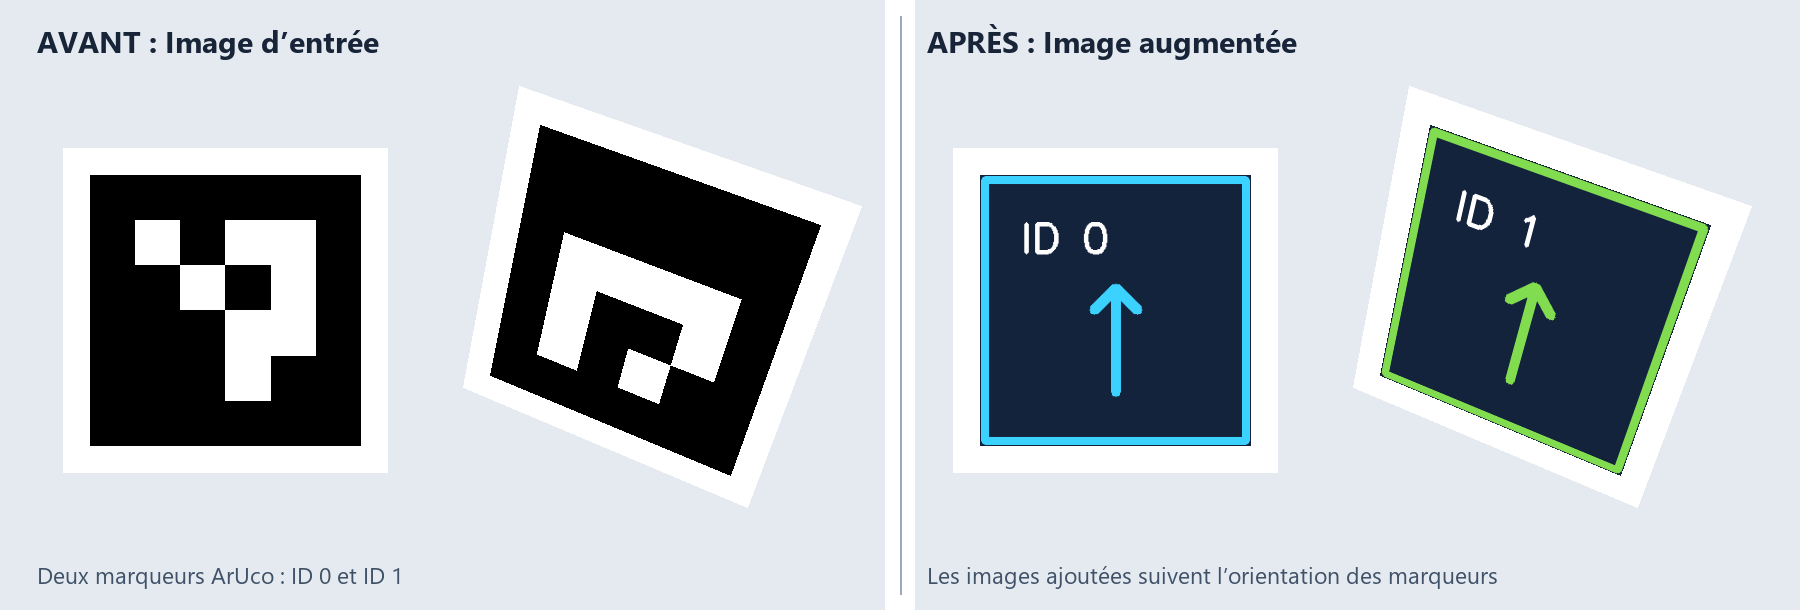

*Exemple sur une image synthétique, traité avec les fonctions du laboratoire.
Chaque image virtuelle recouvre son marqueur et en suit l’orientation et la perspective.
Vous personnaliserez ensuite l’apparence des images virtuelles.*

**Comment travailler :** lisez les explications, complétez le code marqué
`À COMPLÉTER`, puis exécutez vos cellules. Conservez les images produites et les
résultats des essais dans le notebook. Les essais sur téléphone se remettent sous
forme de mesures chiffrées et de valeurs booléennes.


## 1. Quel type de réalité augmentée allons-nous réaliser ?

La **réalité augmentée (RA)** associe une vue du monde réel à des éléments
numériques. Ici, une photo fournit la scène réelle et notre programme y ajoute
un dessin dont la position dépend d’un repère visible.

Nous réalisons une **augmentation 2D sur marqueurs** : un carré imprimé permet de
localiser une surface plane dans l’image. Une image virtuelle est transformée pour
correspondre à la position et à la perspective du marqueur dans la photo. Nous commençons par des photos pour examiner les étapes
du traitement. En section 8, le téléphone répétera ces étapes sur les images de la caméra.

L’image virtuelle ajoutée reste une image plane. Nous ne reconstruisons pas la pièce, ne
plaçons pas d’objet 3D dans l’espace et ne calculons pas ce qui devrait cacher
un objet virtuel.


### Les marqueurs ArUco

Un **marqueur ArUco** est un repère carré conçu pour être reconnu dans une image.
Il possède une bordure noire et une grille intérieure de cases noires ou blanches.
La bordure aide à repérer le carré. Le motif permet d’identifier le marqueur
et son orientation. À l’impression, conservez une bande de papier blanc autour du carré noir,
à l’extérieur du marqueur, pour que son contour se distingue du support sur lequel
vous le posez.

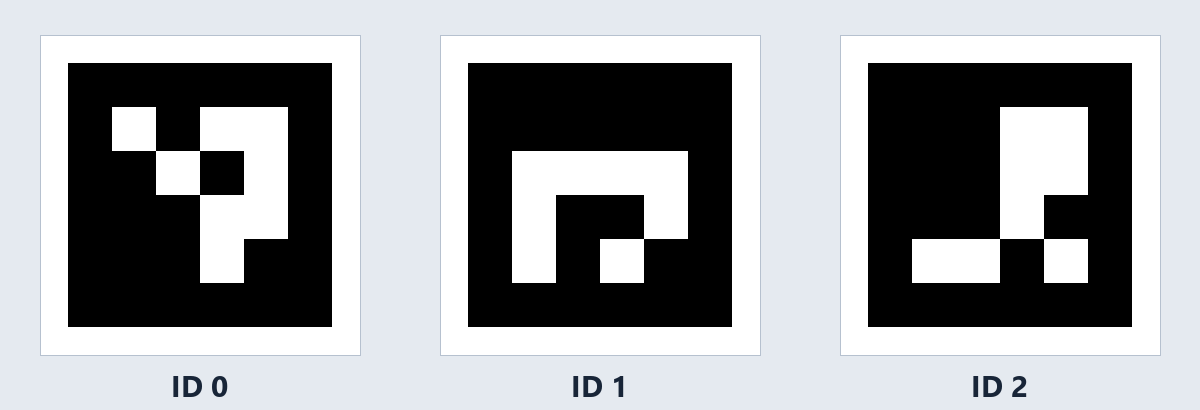


## 2. Avec quels outils ?

Une bibliothèque regroupe des fonctions réutilisables. Nous utiliserons deux
bibliothèques pour représenter et transformer les images, puis un outil d’affichage.

| Outil | Son rôle | Exemple dans le labo |
| --- | --- | --- |
| **NumPy**, importé sous le nom `np` | Manipuler des tableaux de nombres | Stocker les pixels, calculer la moyenne de coordonnées |
| **OpenCV**, importé sous le nom `cv2` | Effectuer des opérations de vision et de dessin | Détecter un ArUco, tracer une ligne, déformer une image |
| **Matplotlib**, importé sous le nom `plt` | Afficher les images et leurs coordonnées dans le notebook | `plt.imshow(...)` affiche les pixels ; `afficher_image(image)` prépare les couleurs pour cet affichage |

NumPy représente les données ; OpenCV exécute des algorithmes sur ces données.


Exécutez cette cellule pour préparer les bibliothèques utilisées dans les exemples.
Si un redémarrage est demandé, redémarrez la session, puis poursuivez avec
la cellule d’importation sans relancer l’installation.


In [2]:
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

try:
    version_opencv = version('opencv-contrib-python-headless')
    version_matplotlib = tuple(map(int, version('matplotlib').split('.')[:2]))
    outils_prets = (version_opencv == '4.12.0.88'
                   and (3, 8) <= version_matplotlib < (4, 0))
except (PackageNotFoundError, ValueError):
    outils_prets = False

if not outils_prets:
    subprocess.check_call([sys.executable, '-m', 'pip', 'uninstall', '-y',
                           'opencv-python', 'opencv-python-headless',
                           'opencv-contrib-python', 'opencv-contrib-python-headless'])
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'opencv-contrib-python-headless==4.12.0.88',
                           'matplotlib>=3.8,<4'])
    print('Installation terminée. Redémarrez la session, puis passez à la cellule suivante.')
else:
    print('Outils prêts.')


Installation terminée. Redémarrez la session, puis passez à la cellule suivante.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Le dictionnaire ArUco

Un **dictionnaire ArUco** est un ensemble de motifs de marqueurs. Dans OpenCV,
il est représenté par un objet `cv2.aruco.Dictionary`, distinct du type Python `dict`.

Nous utilisons `DICT_4X4_50`, qui contient **50 motifs déjà définis dans OpenCV**,
chacun composé d’une grille intérieure de **4 × 4 cases**. Leurs identifiants vont
de 0 à 49. Le labo utilise seulement les IDs 0 à 5. L’ID est un indice dans cet ensemble.

Le motif existe donc déjà. Pour l’afficher ou l’imprimer, on génère une image de
ce motif à la taille voulue. La cellule suivante récupère le dictionnaire, choisit
le motif d’identifiant 2, puis produit et affiche son image de 300 × 300 pixels.


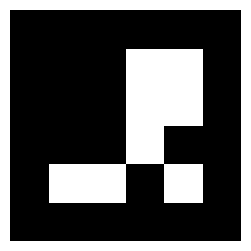

In [4]:
dictionnaire = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
identifiant = 2
marqueur = cv2.aruco.generateImageMarker(dictionnaire, identifiant, 300)

plt.figure(figsize=(3, 3))
plt.imshow(marqueur, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.axis('off')
plt.show()


`getPredefinedDictionary` renvoie l’objet contenant les 50 motifs prédéfinis.
L’identifiant `2` sélectionne le troisième motif, car les indices commencent à 0.
`generateImageMarker` dessine le motif choisi dans une image de **300 × 300 pixels**, avec la bordure
noire. Le nombre `300` fixe la taille de l’image, tandis que `4X4` décrit le nombre
de cases du motif intérieur.

Référence : [marqueurs et dictionnaires ArUco dans OpenCV](https://docs.opencv.org/4.13.0/d5/dae/tutorial_aruco_detection.html).


### Les coordonnées dans une image

Une image est une grille de pixels. **Dans ce laboratoire, nous utilisons la
convention de coordonnées de pixels d’OpenCV** : le pixel supérieur gauche a
pour coordonnées `(0, 0)`, `x` augmente vers la droite et `y` vers le bas.
Ce choix n’est pas universel : d’autres systèmes placent l’origine en bas à
gauche, avec `y` croissant vers le haut, comme dans un repère cartésien usuel.
Il faut donc vérifier la convention de l’outil utilisé.


### Une image est un tableau de pixels

Une image couleur de hauteur `h` et de largeur `w` est ici un tableau NumPy de
forme `(h, w, 3)`. Chaque pixel contient trois intensités entières de 0 à 255,
stockées dans le type `uint8`.

Dans nos images OpenCV, les canaux suivent l’ordre **BGR : bleu, vert, rouge**.
Ainsi, `(0, 0, 255)` produit du rouge et `(255, 0, 0)` du bleu.

Matplotlib attend les couleurs dans l’ordre **RGB**. La fonction fournie
`afficher_image(image)` convertit BGR en RGB avec `cv2.cvtColor`, puis affiche l’image
avec [`plt.imshow`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html).
`origin='upper'` place le pixel `(0, 0)` en haut à gauche de la figure.

Les coordonnées géométriques et les indices du tableau n’utilisent pas
le même ordre.

| Opération | Ordre attendu |
| --- | --- |
| Lire un pixel NumPy | `image[y, x]` — ligne, colonne |
| Fournir un point à OpenCV | `(x, y)` — colonne, ligne |
| Lire les dimensions | `image.shape` — hauteur, largeur, canaux |

Une tranche `image[y0:y1, x0:x1]` sélectionne une région. Les bornes de fin sont exclues. `image.copy()` crée une copie indépendante sur laquelle on peut dessiner sans modifier la capture originale.

Référence : [prise en main de NumPy](https://numpy.org/doc/stable/user/quickstart).


In [5]:
def afficher_image(image):
    # OpenCV utilise BGR ; Matplotlib attend RGB pour une image couleur.
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    figure, axes = plt.subplots(figsize=(6, 4), facecolor='#f1f3f5')
    axes.imshow(image_rgb, origin='upper', interpolation='nearest')
    for bordure in axes.spines.values():
        bordure.set_visible(True)
        bordure.set_color('#667085')
        bordure.set_linewidth(1.2)
    axes.set_xlabel('x (pixels)')
    axes.set_ylabel('y (pixels)')
    figure.tight_layout()
    plt.show()
    plt.close(figure)


L’exemple suivant divise l’image en quatre sections de couleurs différentes.
Chaque affectation utilise une tranche NumPy pour remplir un quart de l’image.
Les triplets de couleurs sont écrits dans l’ordre BGR.


Forme : (160, 240, 3)
Pixel au point (x=40, y=30) : [86 47 41]


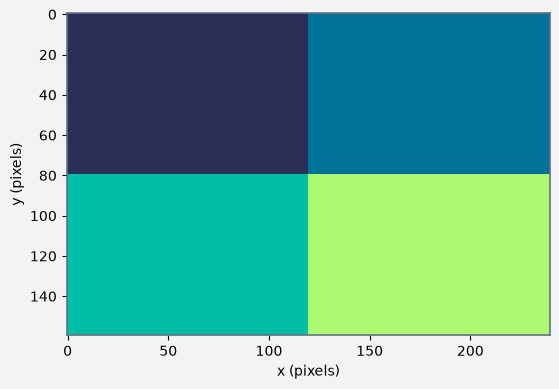

In [6]:
image_demo = np.zeros((160, 240, 3), dtype=np.uint8)
image_demo[:80, :120] = (86, 47, 41)       # Haut gauche : #292f56
image_demo[:80, 120:] = (152, 115, 0)      # Haut droite : #007398
image_demo[80:, :120] = (166, 191, 0)      # Bas gauche : #00bfa6
image_demo[80:, 120:] = (112, 250, 172)    # Bas droite : #acfa70
print('Forme :', image_demo.shape)
print('Pixel au point (x=40, y=30) :', image_demo[30, 40])
afficher_image(image_demo)


### Question 1

**À vous de programmer :** complétez la cellule suivante pour dessiner un carré
bleu de 40 × 40 pixels dont le coin supérieur gauche est `(x=150, y=90)`.
Conservez les couleurs en dehors de ce carré et ne modifiez pas `image_demo`.

**Résultat attendu**

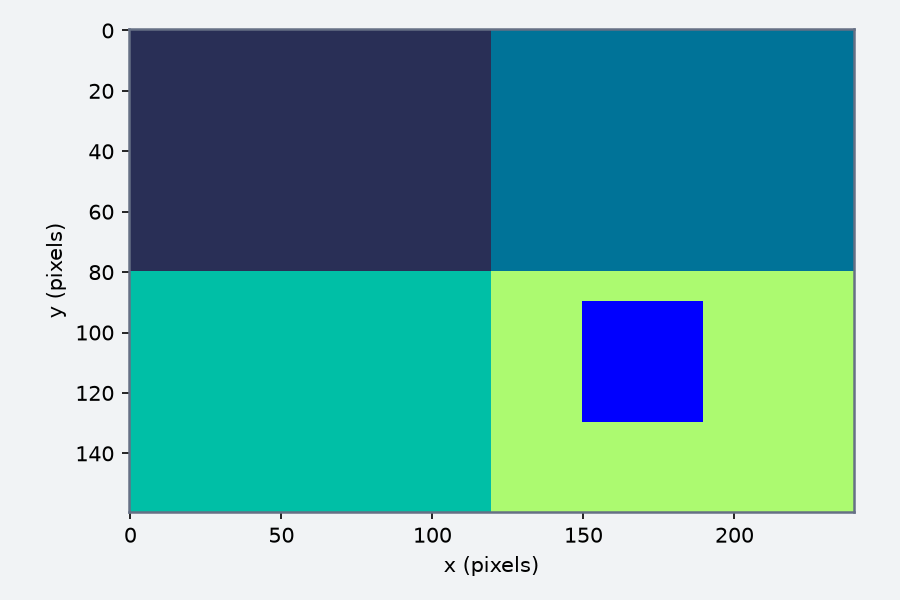

**Pour vérifier :** le point `(160, 100)` doit être bleu, le point `(40, 30)` doit
conserver la couleur bleu sombre de la section supérieure gauche.


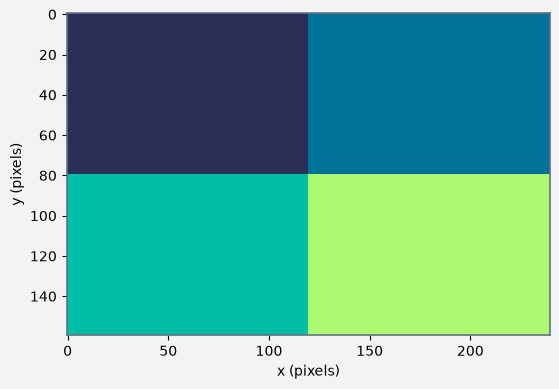

Pixel modifié : [112 250 172]
Même pixel dans l’original : [112 250 172]


In [7]:
image_modifiee = image_demo.copy()
# À COMPLÉTER : colorer la région demandée avec une tranche NumPy.
afficher_image(image_modifiee)
print('Pixel modifié :', image_modifiee[100, 160])
print('Même pixel dans l’original :', image_demo[100, 160])


## 3. Générer et détecter les marqueurs

`cv2.aruco.getPredefinedDictionary` charge le dictionnaire présenté en section 2.
`cv2.aruco.generateImageMarker` dessine le motif de l’ID choisi à la taille demandée.
Dans l’exemple, l’ID est `0` et l’image mesure `180 × 180` pixels.
La bordure noire a par défaut une case d’épaisseur. La grille intérieure de
4 × 4 cases et cette bordure forment donc un ensemble de 6 × 6 cases.

`cv2.copyMakeBorder` ajoute ensuite une marge blanche de 20 pixels autour du
marqueur. Le même dictionnaire et le même ID donnent toujours le même motif.


In [8]:
DICTIONNAIRE_ARUCO = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)

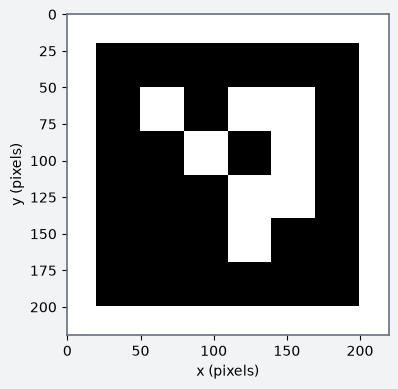

In [9]:
# Un marqueur ID 0, entouré de blanc pour faciliter sa détection.
motif = cv2.aruco.generateImageMarker(DICTIONNAIRE_ARUCO, 0, 180)
marqueur = cv2.copyMakeBorder(motif, 20, 20, 20, 20,
                            cv2.BORDER_CONSTANT, value=255)
image_test = cv2.cvtColor(marqueur, cv2.COLOR_GRAY2BGR)
afficher_image(image_test)


### Les résultats de la détection

Le détecteur ArUco fournit l’**identifiant** du marqueur et les **coordonnées de
ses quatre coins, dans un ordre lié à l’orientation du motif**. L’identifiant
permet de choisir quelle image virtuelle afficher ; les coins indiquent où la placer.

Le schéma reprend le marqueur d’ID 0 généré ci-dessus, avec sa marge blanche,
en le montrant tourné et sous une autre perspective.

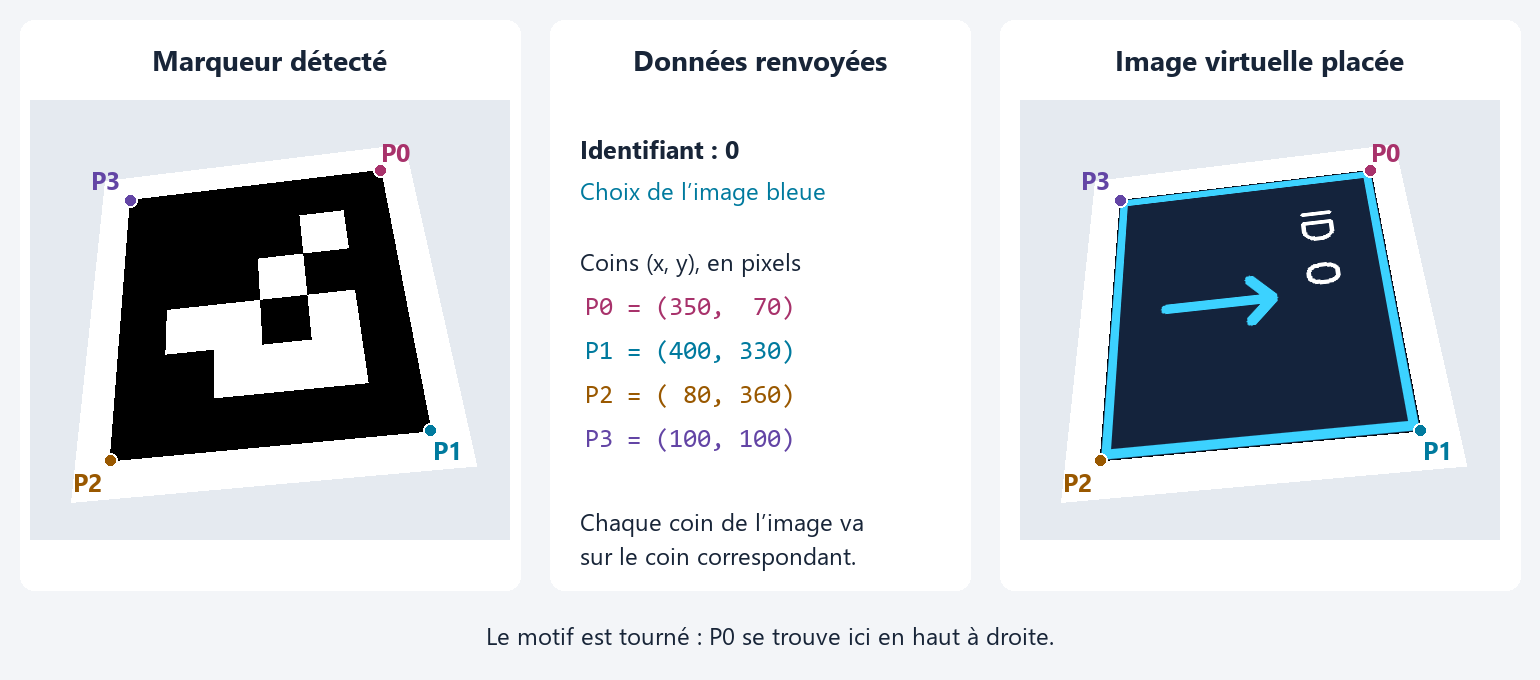

Les coins sont notés `P0`, `P1`, `P2` et `P3` dans l’ordre renvoyé par le
détecteur. Cet ordre suit l’orientation du motif. `P0` n’est donc pas forcément
le coin situé en haut à gauche de la photo.


### Convertir une photo en niveaux de gris

La caméra fournit une image couleur avec trois valeurs par pixel, les canaux
bleu, vert et rouge. Pour préparer la détection, nous en calculons une version
**en niveaux de gris**, avec une seule valeur d’intensité par pixel.

La photographie ci-dessous montre des marqueurs imprimés dans une scène réelle.
À droite, chaque pixel a été converti avec `cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)`.


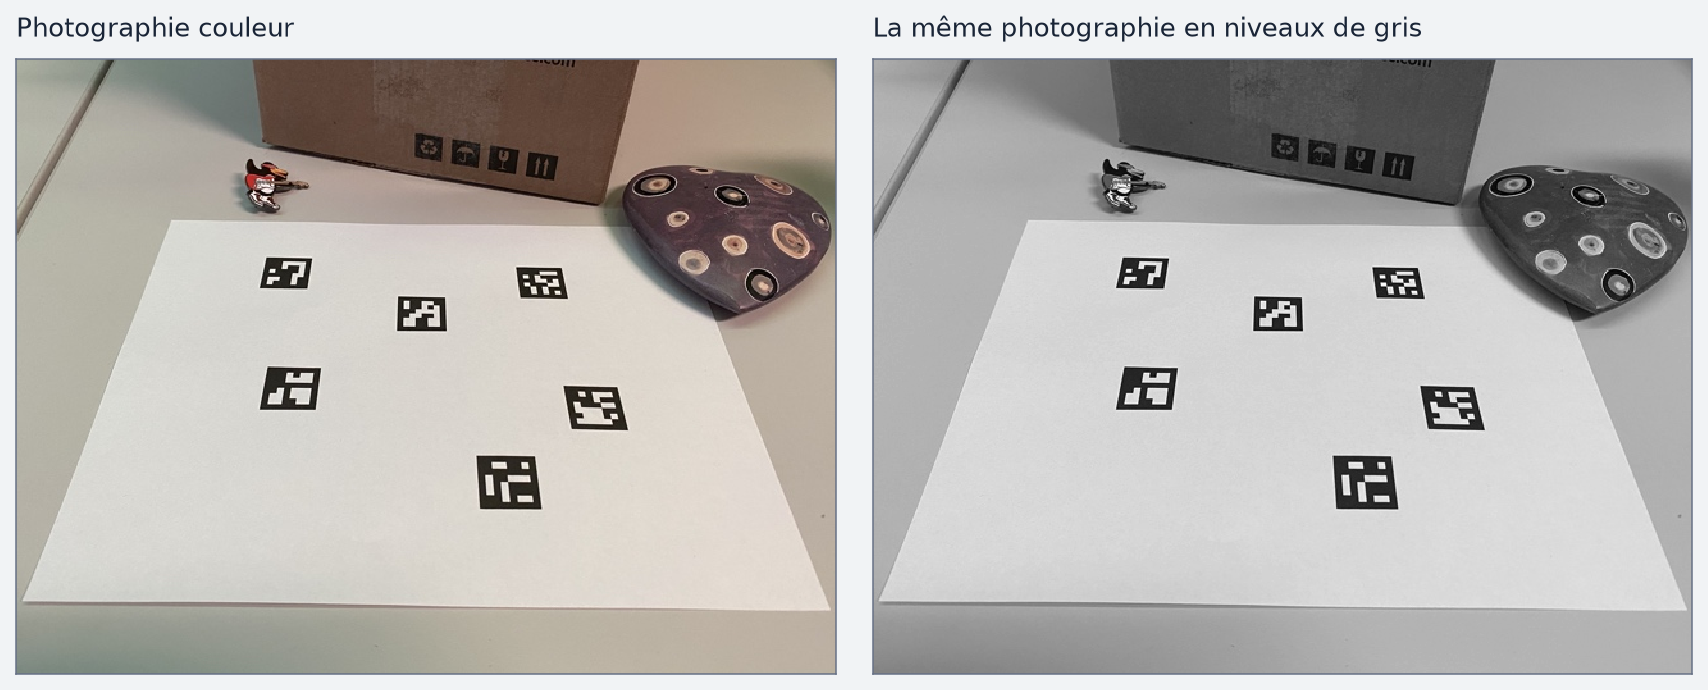

Le carton brun et le cœur violet perdent leur couleur. Les bordures et les cases
sombres des marqueurs restent distinctes des régions claires. C’est ce contraste
que le détecteur utilise pour repérer les contours et lire les motifs.
La conversion réduit donc le nombre de valeurs à traiter sans supprimer ici
l’information nécessaire à la reconnaissance des marqueurs.

*Photographie du [tutoriel OpenCV sur la détection ArUco](https://docs.opencv.org/4.13.0/d5/dae/tutorial_aruco_detection.html).
Les marqueurs de cette photo ont une grille de 6 × 6 cases. La conversion est
la même pour les marqueurs de 4 × 4 cases utilisés dans le laboratoire.*


### Calculer l’intensité d’un pixel

`cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)` transforme le tableau de forme
`(hauteur, largeur, 3)` en un tableau `(hauteur, largeur)`.
Pour nos images sur 8 bits, l’intensité obtenue va de 0 à 255.
OpenCV combine les canaux selon `gris ≈ 0.114 B + 0.587 G + 0.299 R`,
avec un arrondi entier. Un pixel rouge BGR `(0, 0, 255)` devient ainsi environ `76`.
Le noir reste `0` et le blanc reste `255`.

La feuille photographiée contient encore des nuances de gris dues à l’éclairage.
La conversion n’a donc pas produit une image contenant seulement du noir et du blanc.
Le **seuillage**, présenté ensuite, classe les intensités en zones sombres ou claires.
La photo couleur d’origine reste disponible pour y superposer les images virtuelles.

Référence : [conversion en niveaux de gris, documentation OpenCV](https://docs.opencv.org/4.13.0/de/d25/imgproc_color_conversions.html).


### Comment le détecteur reconnaît-il un marqueur ?

`ArucoDetector` associe un dictionnaire de motifs aux réglages de détection.
Nous utilisons `DICT_4X4_50` et les réglages par défaut de `DetectorParameters()`.
Avec ces réglages, `detecteur.detectMarkers(gris)` réalise les étapes suivantes.

1. Un **seuillage adaptatif** sépare les zones sombres et claires avec un seuil
   calculé localement pour tenir compte des variations d’éclairage.
2. Le détecteur cherche des contours pouvant former un quadrilatère convexe.
   Ces formes sont des candidats, pas encore des marqueurs reconnus.
3. À partir des quatre coins du candidat, le détecteur corrige la perspective
   pour obtenir une image carrée. Cette transformation est étudiée en section 5.
4. Il vérifie ensuite sa bordure noire et compare le motif de ses cases au
   dictionnaire pour déterminer son identifiant et son orientation. Cette
   comparaison tient compte des rotations et du nombre d’erreurs toléré.

Les coins renvoyés restent exprimés dans l’image d’entrée. Un quadrilatère dont
le motif ne correspond pas au dictionnaire est rejeté.

Référence : [détection des marqueurs, documentation OpenCV](https://docs.opencv.org/4.13.0/d5/dae/tutorial_aruco_detection.html#aruco_detection).


### Étape 1 — Séparer les zones sombres et claires

Reprenons un extrait de la photo réelle des six marqueurs. Pour rendre la
variation d’éclairage bien visible, nous assombrissons **une copie** de l’image
avec un dégradé qui va de 30 % de luminosité à gauche à 100 % à droite.
Cet éclairage est simulé, les motifs proviennent de la photographie.

Nous comparons **deux méthodes indépendantes**, appliquées à la même copie.
Chacune produit sa propre image en noir et blanc. Leurs résultats ne sont
ni combinés ni appliqués l’un après l’autre.

- **Seuil global de 127** : chaque pixel devient blanc si son intensité dépasse
  127, sinon il devient noir. Le seuil est identique partout.
- **Seuil adaptatif** : le seuil de chaque pixel est la moyenne des intensités
  de son voisinage de 31 × 31 pixels, moins 7. Il varie donc selon l’endroit.

**Si une méthode donne du blanc et l’autre du noir pour un pixel, ce pixel est
blanc dans l’une des deux images et noir dans l’autre.** Il n’y a pas de décision
commune à prendre entre ces résultats. Le seuil global de 127 sert ici de
comparaison pédagogique. Pour rechercher les contours des marqueurs, ArUco
utilise le seuillage adaptatif, avec les réglages par défaut du labo.

La taille du voisinage doit être impaire et supérieure à 1. Dans cet exemple,
`31` fixe cette taille et `7` est la constante soustraite à la moyenne.

#### Quel est le lien avec la convolution ?

Dans notre exemple, **le calcul de la moyenne locale équivaut à une convolution**
avec un noyau de **31 × 31**, dont les 961 coefficients valent tous **1/961**.
À chaque position, ce filtre calcule la moyenne des intensités du voisinage.
OpenCV peut optimiser ce calcul sans effectuer séparément les 961 multiplications.

Le traitement se déroule donc en trois opérations :

1. **Filtrer** l’image pour calculer la moyenne locale.
2. **Soustraire 7** à cette moyenne pour obtenir le seuil local.
3. **Comparer** l’intensité du pixel à ce seuil : au-dessus, il devient blanc ; sinon, noir.

**Le seuillage adaptatif n’est donc pas, à lui seul, une convolution.**
La convolution calcule ici les moyennes ; la comparaison qui produit l’image
binaire est une opération non linéaire.



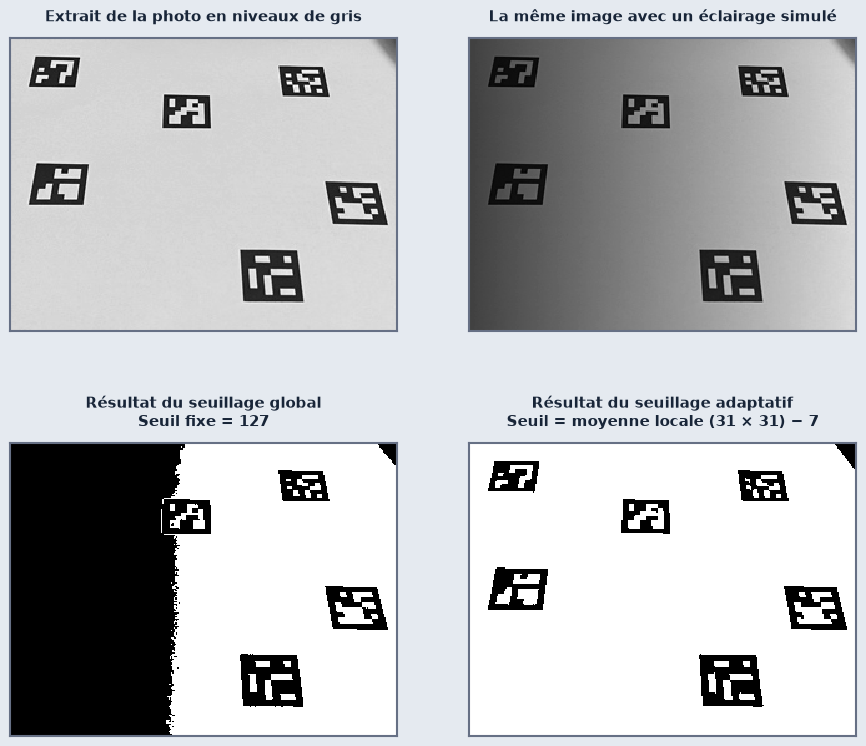

In [10]:
from urllib.request import urlopen

# Télécharger la photo depuis le dépôt officiel OpenCV sur GitHub.
with urlopen('https://raw.githubusercontent.com/opencv/opencv/4.12.0/doc/tutorials/objdetect/aruco_detection/images/singlemarkersoriginal.jpg', timeout=30) as reponse:
    donnees_photo = reponse.read()
# Présenter ces octets à OpenCV, puis décoder le JPEG en une image couleur BGR.
photo_seuillage = cv2.imdecode(np.frombuffer(donnees_photo, dtype=np.uint8), cv2.IMREAD_COLOR)

# Convertir en niveaux de gris et garder la région contenant les six marqueurs.
# La tranche sélectionne les lignes 140 à 374 et les colonnes 175 à 484.
extrait_gris = cv2.cvtColor(photo_seuillage, cv2.COLOR_BGR2GRAY)[140:375, 175:485]
# Créer un facteur par colonne, de 0.30 à gauche à 1.0 à droite.
eclairage_simule = np.linspace(0.30, 1.0, extrait_gris.shape[1])
# Multiplier les intensités par ces facteurs pour simuler une ombre à gauche.
# NumPy applique les mêmes facteurs à chaque ligne. Arrondir puis revenir en uint8.
gris_ombre = np.rint(extrait_gris * eclairage_simule).astype(np.uint8)

seuil_global = 127       # Une seule valeur de comparaison pour toute l’image.
taille_voisinage = 31    # Fenêtre de 31 × 31 pixels centrée sur chaque pixel.
constante_seuil = 7      # Valeur à soustraire à la moyenne du voisinage.

# Méthode globale : intensité > 127 → blanc (255), sinon → noir (0).
# threshold renvoie le seuil utilisé et l’image. On ignore le premier résultat avec _.
_, binaire_global = cv2.threshold(gris_ombre, seuil_global, 255, cv2.THRESH_BINARY)

# Méthode adaptative : recalculer le seuil local pour chaque pixel.
# ADAPTIVE_THRESH_MEAN_C utilise la moyenne du voisinage moins constante_seuil.
# THRESH_BINARY donne du blanc (255) au-dessus du seuil local, sinon du noir (0).
# Cette méthode reçoit la même image gris_ombre, pas le résultat binaire_global.
binaire_adaptatif = cv2.adaptiveThreshold(
    gris_ombre, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY, taille_voisinage, constante_seuil,
)

figure, axes = plt.subplots(2, 2, figsize=(9, 7.8), facecolor='#e5eaf0')
figure.subplots_adjust(left=0.025, right=0.975, bottom=0.025, top=0.92,
                        wspace=0.16, hspace=0.38)
vues_seuillage = [
    ('Extrait de la photo en niveaux de gris', extrait_gris),
    ('La même image avec un éclairage simulé', gris_ombre),
    (f'Résultat du seuillage global\nSeuil fixe = {seuil_global}', binaire_global),
    (f'Résultat du seuillage adaptatif\nSeuil = moyenne locale ({taille_voisinage} × {taille_voisinage}) − {constante_seuil}',
     binaire_adaptatif),
]
for axe, (titre, vue) in zip(axes.flat, vues_seuillage):
    axe.imshow(vue, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    axe.set_title(titre, fontsize=11, fontweight='bold', color='#182538', pad=12)
    axe.set_xticks([])
    axe.set_yticks([])
    for bordure in axe.spines.values():
        bordure.set_visible(True)
        bordure.set_color('#667085')
        bordure.set_linewidth(1.5)
plt.show()
plt.close(figure)


#### Suivre le calcul pour un pixel

Le cadre rose délimite le **voisinage du pixel étudié**. Le gros plan montre les
31 × 31 pixels, soit 961 valeurs, utilisées pour calculer son seuil.

1. Centrer la fenêtre de 31 × 31 sur le pixel.
2. Calculer la moyenne de toutes les intensités dans cette fenêtre, y compris
   celle du pixel central. Dans ce calcul OpenCV sur 8 bits, la moyenne est arrondie.
3. Soustraire 7 à cette moyenne pour obtenir le seuil local.
4. Comparer l’intensité du pixel central au seuil. Une valeur **strictement
   supérieure** donne du blanc (`255`). Sinon, elle donne du noir (`0`).

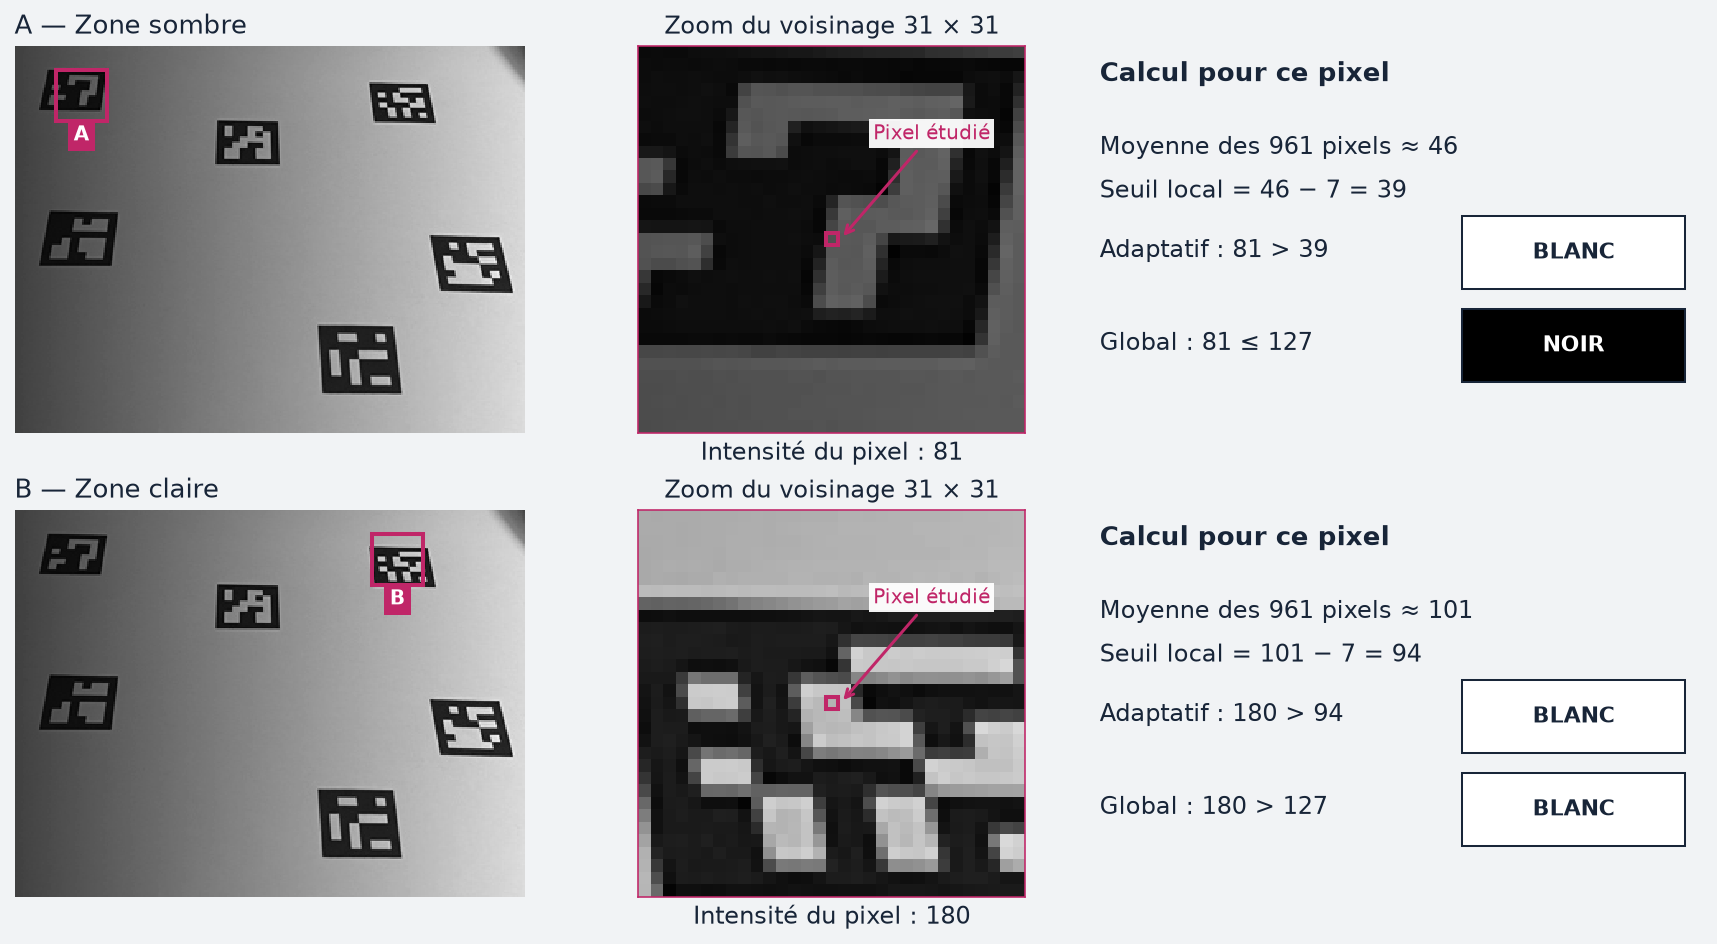

Le pixel A appartient à une case blanche assombrie par l’éclairage simulé.
Son intensité de **81** dépasse le seuil local de **39**, mais pas le seuil
global de **127**. Le seuillage adaptatif le classe donc blanc, tandis que le
seuillage global le classe noir. Pour le pixel B, plus éclairé, les deux
méthodes donnent du blanc. Les cases « BLANC » et « NOIR » du schéma indiquent
donc la valeur du pixel dans **chacune des deux images de sortie**.

Le calcul est répété à chaque pixel. La fenêtre **se déplace d’un pixel à la
fois**, avec un fort chevauchement entre les voisinages. L’image n’est pas
découpée en blocs indépendants de 31 × 31 pixels.


#### Voir le seuil à chaque endroit de l’image

Ces deux cartes représentent les **valeurs des seuils**, avec la même échelle
de couleurs. Elles ne représentent pas les pixels noirs ou blancs du résultat.
À gauche, la valeur est 127 partout. À droite, le seuil dépend du voisinage de
chaque pixel. Les points A et B correspondent aux deux gros plans précédents.

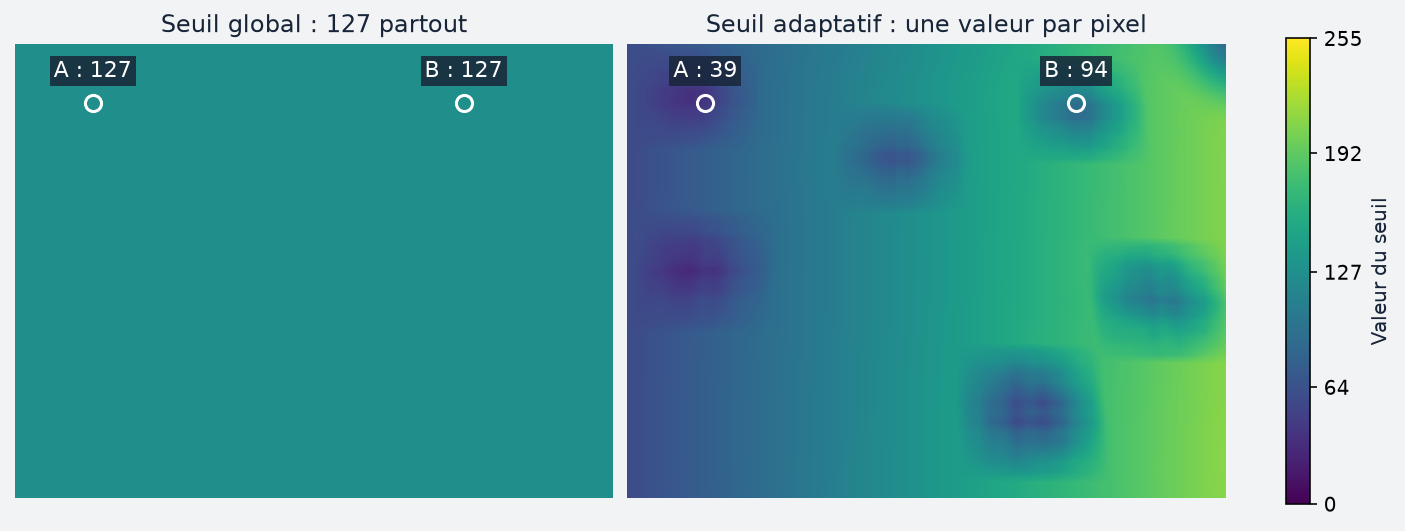

Les seuils suivent à la fois les variations d’éclairage et le contenu des
voisinages : les zones noires des marqueurs font elles aussi baisser la moyenne.


#### Modifier les paramètres

Vous pouvez changer `seuil_global`, `taille_voisinage` et `constante_seuil`, puis
réexécuter la cellule. Une fenêtre trop petite peut effacer l’intérieur de zones
noires uniformes, tandis qu’une fenêtre trop grande tient moins bien compte des
variations locales d’éclairage. Le seuillage adaptatif ne garantit pas une image
sans bruit ni une détection réussie dans toutes les conditions.

Cette comparaison montre une étape du traitement. Avec les réglages par défaut,
ArUco essaie plusieurs tailles de voisinage et utilise une version inversée du
seuillage pour rechercher les contours. Dans le labo, transmettez toujours
l’image en niveaux de gris à `detecteur.detectMarkers` : le détecteur réalise
lui-même ce seuillage.

Références : [seuillage dans OpenCV](https://docs.opencv.org/4.13.0/d7/d4d/tutorial_py_thresholding.html)
et [paramètres du seuillage ArUco](https://docs.opencv.org/4.13.0/d5/dae/tutorial_aruco_detection.html#aruco_detection).


### Étape 2 — Repérer les quadrilatères candidats

Le détecteur passe d’une frontière faite de nombreux pixels à une forme décrite par quelques sommets :

1. **Suivre les contours.** Dans l’image binaire, il suit les frontières entre les régions noires et blanches. Chaque contour est une suite de coordonnées de pixels.
2. **Simplifier chaque contour.** Il remplace les portions presque droites par des segments, en autorisant un petit écart avec le contour initial. Il ne force pas la forme à avoir quatre côtés : le nombre de sommets dépend du contour et de cette tolérance.
3. **Retenir les formes possibles.** Si l’approximation a **quatre sommets** et est **convexe** (sans creux), elle peut devenir un candidat. D’autres filtres vérifient notamment sa taille et l’espacement de ses coins. Un triangle ou une forme présentant un creux échoue à ce test.

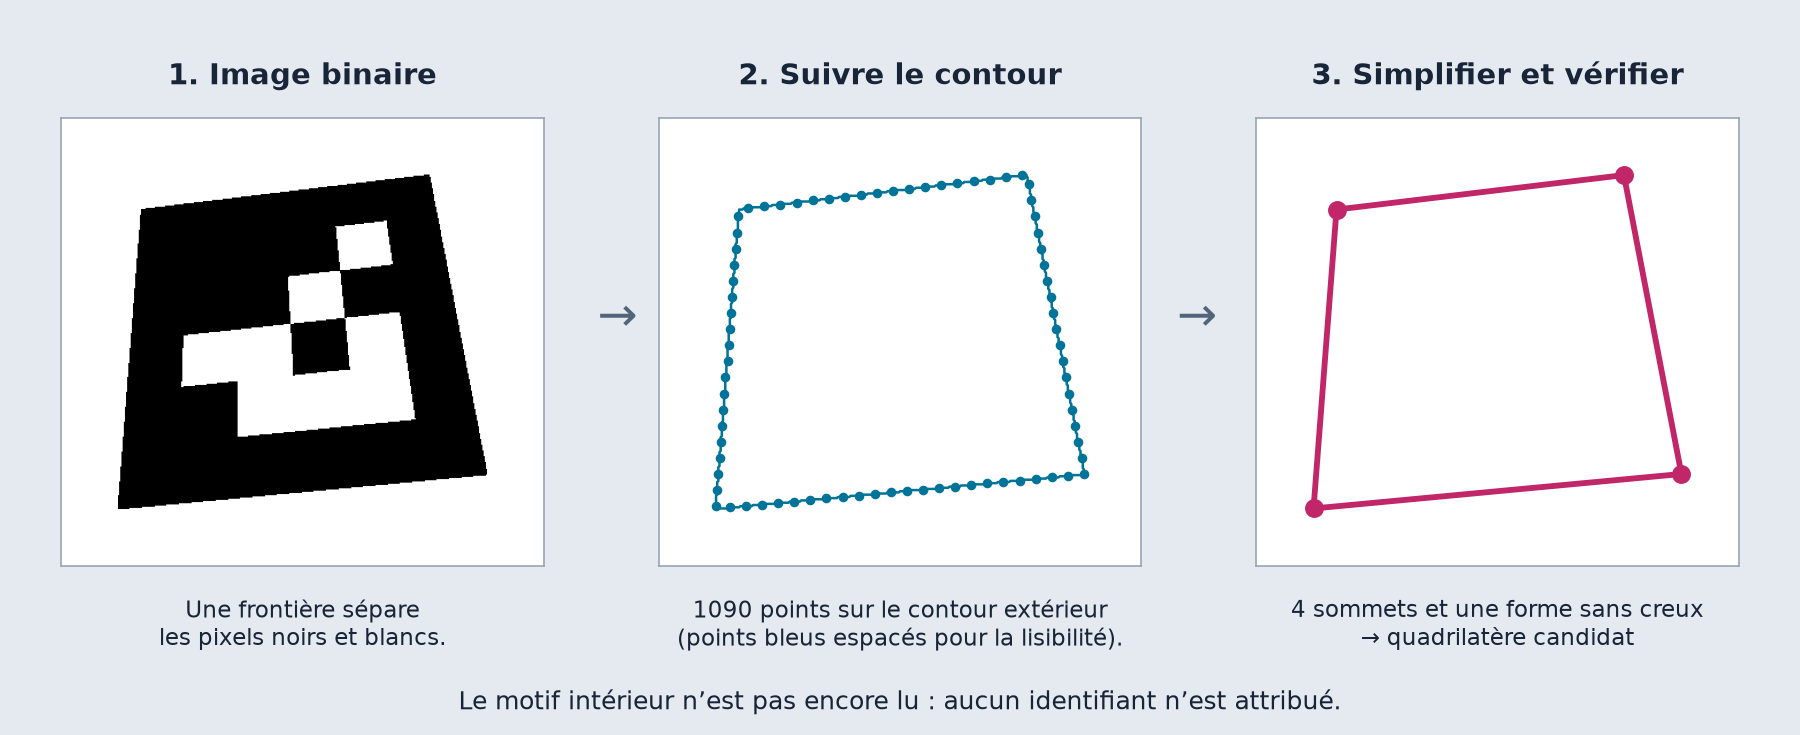

Le schéma isole un contour extérieur pour faciliter la lecture ; le détecteur en examine plusieurs. Un carré vu de biais peut rester un quadrilatère convexe : ses angles n’ont pas besoin de faire 90° dans la photo.

**Candidat ne signifie pas marqueur reconnu.** Le motif intérieur n’a pas encore été lu. Les quatre coins roses permettront d’extraire une vue carrée à l’étape 3, puis de chercher l’identifiant à l’étape 4.

Dans OpenCV, ces opérations correspondent à `findContours`, `approxPolyDP` et `isContourConvex` ([code du détecteur](https://github.com/opencv/opencv/blob/4.12.0/modules/objdetect/src/aruco/aruco_detector.cpp#L116-L168)).


### Étape 3 — Obtenir une vue carrée du candidat

Voici le même marqueur d’ID 0 que dans notre exemple. Les quatre coins du contour
rose sont envoyés aux quatre coins d’une nouvelle image carrée. Cette opération
compense la perspective pour faciliter la lecture des cases. La marge blanche,
à l’extérieur du contour, ne fait pas partie de l’image extraite.

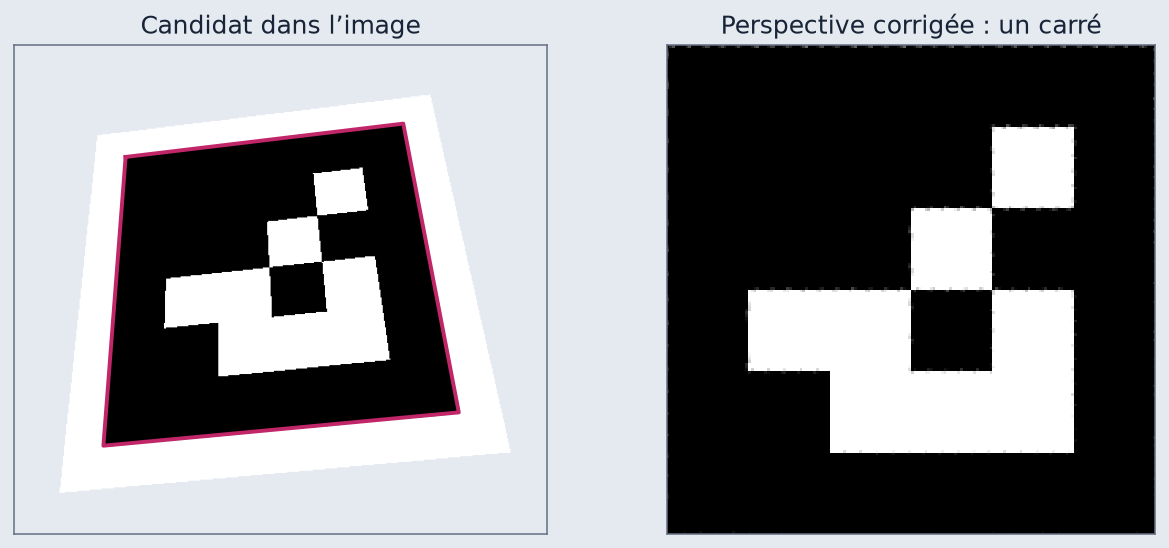

Le motif reste ici tourné dans le carré. Retrouver son orientation fait partie
de l’étape suivante. Le calcul de la transformation sera détaillé en section 5.


### Étape 4 — Lire les cases et retrouver l’identifiant

Avec notre dictionnaire `DICT_4X4_50`, le carré contient **6 × 6 cases** :
une bordure d’une case d’épaisseur autour du motif intérieur de **4 × 4 cases**.
Une case contient plusieurs pixels. Le détecteur classe ses pixels en noir ou
blanc et retient la couleur majoritaire pour lire cette case.

Dans le schéma, la bordure est bien noire. Le cadre orange délimite les 16 cases
du motif, notées `0` pour noir et `1` pour blanc. On compare ensuite ce motif au
dictionnaire en tenant compte des quatre rotations possibles.

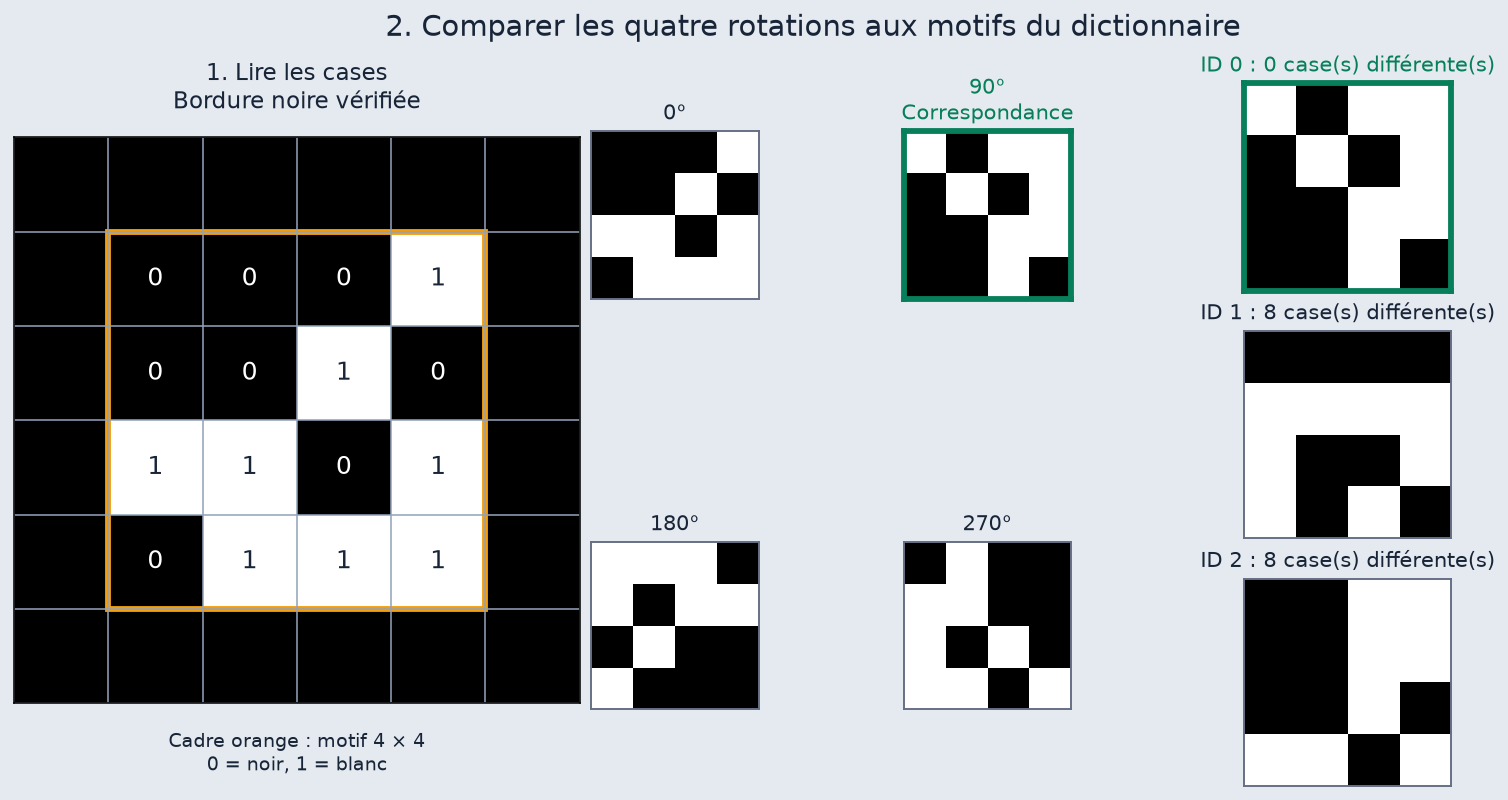

Ici, une rotation de **90° dans le sens antihoraire** fait coïncider le motif lu
avec celui de l’**ID 0**, sans aucune case différente. Cette correspondance
fournit l’identifiant et permet de retrouver l’orientation des quatre coins.
Seuls trois motifs sont affichés pour garder le schéma lisible. La recherche
porte sur les 50 motifs du dictionnaire, avec pour chacun les rotations possibles.
Les écarts affichés sont les plus petits obtenus parmi ces rotations.

#### Pourquoi seulement quatre rotations ?

**Pour comparer les cases, il suffit de tester 0°, 90°, 180° et 270°.**
À l’étape 3, les quatre coins ont déjà permis de corriger la perspective et
d’aligner les côtés avec ceux d’un carré. Même si le marqueur est incliné de
23° dans la photo, cette inclinaison est corrigée avant la lecture des cases.
Il reste à déterminer lequel des quatre coins correspond au début du motif.
Ces quatre choix correspondent aux quatre rotations par pas de 90°.

Pour chaque motif du dictionnaire, le détecteur compare les 16 cases dans ces
quatre orientations et compte les cases différentes. Ce nombre est appelé
**distance de Hamming**. OpenCV stocke déjà les quatre orientations des motifs
du dictionnaire : il compare leurs bits sans faire tourner toute la photo.
Tourner le motif lu, comme dans notre schéma, revient à faire cette comparaison.

Dans une photo imparfaite, certaines cases peuvent être mal lues. Une
correspondance peut être acceptée si le nombre d’erreurs reste dans la limite
autorisée par le dictionnaire et les réglages du détecteur. Sinon, le candidat
est rejeté.

Référence : [comparaison des quatre rotations dans OpenCV](https://github.com/opencv/opencv/blob/4.12.0/modules/objdetect/src/aruco/aruco_dictionary.cpp#L70-L103).


#### Calculer la distance de Hamming, case par case

Comparons un motif lu au motif de l’ID 0, **dans une orientation donnée**.
Pour chacune des 16 positions, on écrit `0` si les deux cases sont identiques
et `1` si elles sont différentes. On additionne ensuite ces différences.
Cette comparaison binaire s’appelle aussi **XOR** (OU exclusif).
La bordure noire et la marge blanche ne font pas partie de ce calcul.

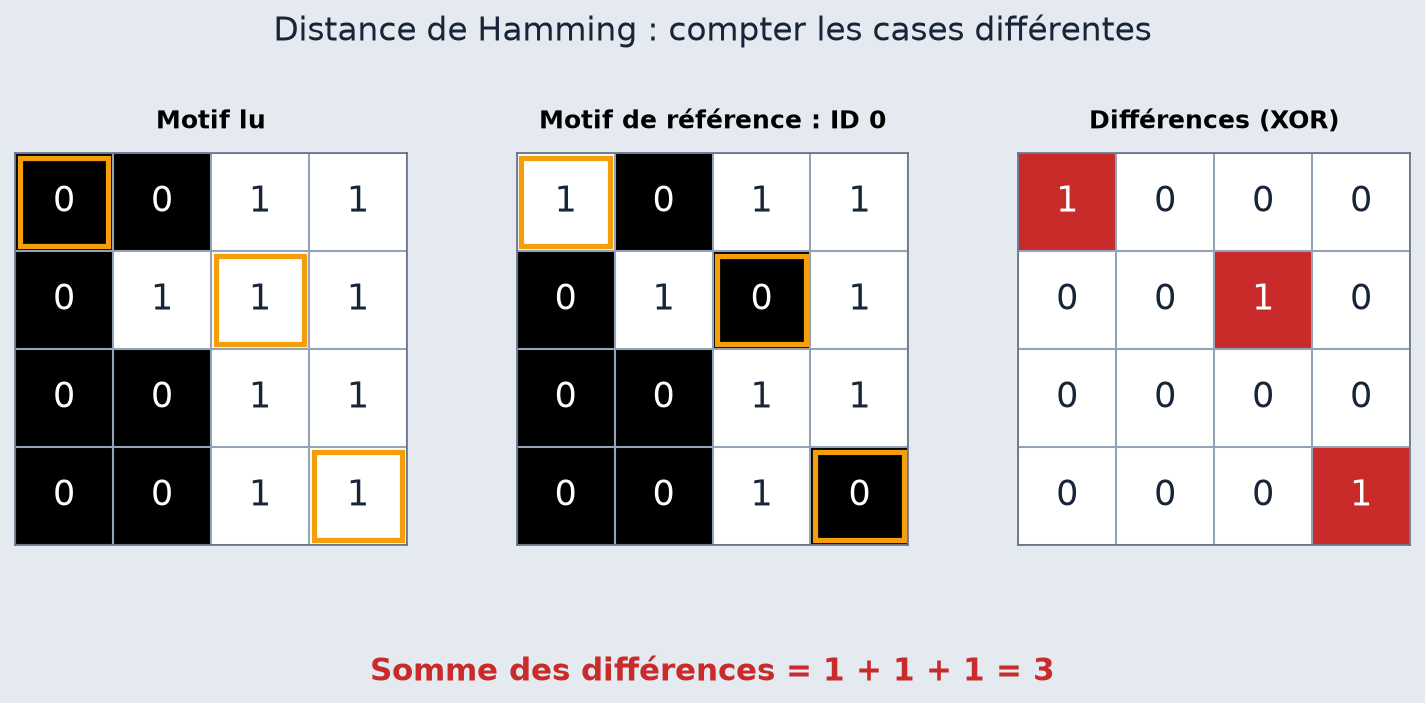

Les trois cases encadrées en orange sont celles qui diffèrent. Dans les deux
motifs, `0` signifie noir et `1` signifie blanc. Dans le tableau de droite,
`1` signifie **différence**, quelle que soit la couleur de départ.
La distance est **3**, car trois positions diffèrent sur les seize.


In [11]:
# Un pixel par case : enlever la bordure pour conserver le motif intérieur 4 × 4.
reference_hamming = cv2.aruco.generateImageMarker(DICTIONNAIRE_ARUCO, 0, 6)[1:5, 1:5] // 255
lecture_hamming = reference_hamming.copy()
for ligne, colonne in [(0, 0), (1, 2), (3, 3)]:
    lecture_hamming[ligne, colonne] = 1 - lecture_hamming[ligne, colonne]

# Comparer les cases aux mêmes positions, puis compter les différences.
differences_hamming = (lecture_hamming != reference_hamming).astype(np.uint8)
distance_hamming = int(differences_hamming.sum())
print('Différences (0 : identiques, 1 : différentes) :')
print(differences_hamming)
print('Distance de Hamming :', distance_hamming)


Différences (0 : identiques, 1 : différentes) :
[[1 0 0 0]
 [0 0 1 0]
 [0 0 0 0]
 [0 0 0 1]]
Distance de Hamming : 3


Cette valeur concerne **ce motif de référence et cette orientation**.
Pour identifier le candidat, il faut tenir compte des autres orientations
et des autres IDs. L’exemple de rejet ci-dessous reprend les mêmes trois
cases inversées : sa distance à l’ID 0 ci-dessus est 3, mais sa meilleure
distance parmi tous les IDs et toutes les rotations est 2.

#### Séquentiellement ou en parallèle ? CPU ou GPU ?

Dans **OpenCV 4.12 utilisé dans ce labo**, il faut distinguer deux niveaux :

| Travail | Exécution |
| --- | --- |
| Comparer un candidat aux motifs du dictionnaire | Sur le **CPU** : une boucle parcourt les IDs ; pour chaque ID, une autre boucle compare ses quatre rotations. La recherche s’arrête dès qu’un ID respecte la tolérance. |
| Traiter plusieurs candidats ou plusieurs tailles de voisinage du seuillage | OpenCV prévoit du **parallélisme sur CPU** : plusieurs tâches peuvent être réparties entre des fils d’exécution, selon sa compilation et les ressources disponibles. |
| Utiliser le GPU | L’appel `ArucoDetector.detectMarkers` avec nos images NumPy ne lance pas ces comparaisons sur le GPU. Disposer d’un GPU ne suffit pas à y déplacer automatiquement ce traitement. |

Ainsi, plusieurs candidats peuvent être analysés en parallèle, tandis que
la recherche parmi les IDs et leurs rotations reste séquentielle **pour un
candidat donné**. Le diagramme explique le calcul mathématique ; il n’impose
pas une boucle Python qui traiterait chaque case séparément. OpenCV compare
des bits regroupés en octets dans son code C++.

Sources : [boucles de comparaison dans OpenCV 4.12](https://github.com/opencv/opencv/blob/4.12.0/modules/objdetect/src/aruco/aruco_dictionary.cpp#L70-L103),
[traitement des candidats](https://github.com/opencv/opencv/blob/4.12.0/modules/objdetect/src/aruco/aruco_detector.cpp#L901-L947)
et [seuillage à plusieurs tailles](https://github.com/opencv/opencv/blob/4.12.0/modules/objdetect/src/aruco/aruco_detector.cpp#L255-L275).


#### Exemple : un carré repéré, mais un motif rejeté

Créons une copie du marqueur 0 en inversant **trois cases intérieures**.
Sa bordure reste noire et sa marge reste blanche. Le contour a donc encore
la forme attendue, mais son motif a changé.

La cellule affiche le contour renvoyé dans `candidats_rejetes` en rouge et
vérifie la distance du motif altéré aux 50 motifs, dans les quatre orientations.


Plus petit nombre de cases différentes : 2
Nombre maximal d’erreurs permis avec ces réglages : 0
Identifiants reconnus : None
Nombre de candidats rejetés : 1


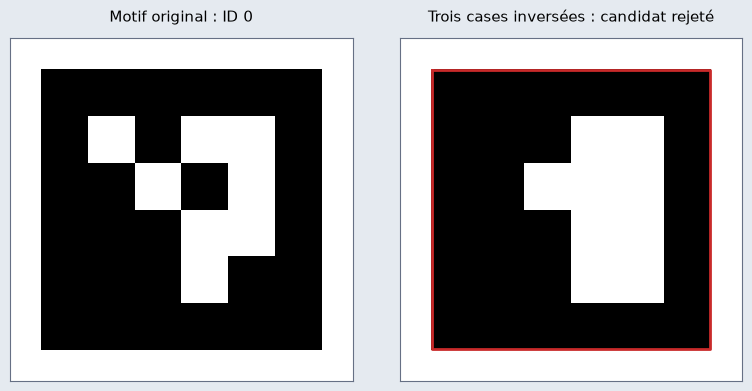

In [12]:
# Modifier trois cases de 30 × 30 pixels, sans toucher à la bordure noire.
motif_original = cv2.aruco.generateImageMarker(DICTIONNAIRE_ARUCO, 0, 180)
motif_altere = motif_original.copy()
for ligne, colonne in [(0, 0), (1, 2), (3, 3)]:
    zone = motif_altere[(ligne + 1)*30:(ligne + 2)*30,
                       (colonne + 1)*30:(colonne + 2)*30]
    zone[:] = 255 - zone  # Noir devient blanc, et blanc devient noir.
image_alteree = cv2.copyMakeBorder(motif_altere, 20, 20, 20, 20,
                                  cv2.BORDER_CONSTANT, value=255)

# Analyser cette image avec les réglages du labo.
parametres_exemple = cv2.aruco.DetectorParameters()
detecteur_exemple = cv2.aruco.ArucoDetector(DICTIONNAIRE_ARUCO, parametres_exemple)
_, ids_alteres, candidats_alteres = detecteur_exemple.detectMarkers(image_alteree)

# Ici, les cases sont uniformes : lire leur pixel central suffit.
cases_alterees = (motif_altere[45:150:30, 45:150:30] // 255).astype(np.uint8)
ecarts = [DICTIONNAIRE_ARUCO.getDistanceToId(cases_alterees, identifiant, True)
          for identifiant in range(50)]  # True : comparer les quatre rotations.
erreurs_permises = int(DICTIONNAIRE_ARUCO.maxCorrectionBits
                      * parametres_exemple.errorCorrectionRate)
print('Plus petit nombre de cases différentes :', min(ecarts))
print('Nombre maximal d’erreurs permis avec ces réglages :', erreurs_permises)
print('Identifiants reconnus :', ids_alteres)
print('Nombre de candidats rejetés :', len(candidats_alteres))

figure, axes = plt.subplots(1, 2, figsize=(8, 4), facecolor='#e5eaf0')
image_originale = cv2.copyMakeBorder(motif_original, 20, 20, 20, 20,
                                    cv2.BORDER_CONSTANT, value=255)
for axe, image, titre in zip(axes, [image_originale, image_alteree],
                            ['Motif original : ID 0', 'Trois cases inversées : candidat rejeté']):
    axe.imshow(image, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    axe.set_title(titre, fontsize=11, pad=12)
    axe.set_xticks([])
    axe.set_yticks([])
    for bordure in axe.spines.values():
        bordure.set_color('#667085')
for candidat in candidats_alteres:
    contour = candidat.reshape(4, 2)
    contour = np.vstack([contour, contour[0]])
    axes[1].plot(contour[:, 0], contour[:, 1], color='#c92a2a', linewidth=2)
figure.tight_layout(pad=1.5)
plt.show()
plt.close(figure)


**Résultat :** même dans sa meilleure orientation, le motif altéré diffère
d’au moins **deux cases** de tous les motifs du dictionnaire. Avec
`DICT_4X4_50` et les réglages par défaut utilisés ici, la limite calculée est
**zéro case différente**. Le candidat est donc rejeté : `ids_alteres` vaut
`None`, mais son quadrilatère apparaît dans `candidats_alteres`.
Repérer un carré ne suffit pas à reconnaître un marqueur.


### Lire les résultats dans Python

Le détecteur fournit **deux collections associées** pour les marqueurs reconnus :
leurs identifiants et leurs coordonnées. Il fournit aussi une collection séparée
pour les formes repérées mais rejetées.

| Résultat | Ce qu’il contient |
| --- | --- |
| `identifiants` | Un tableau contenant l’ID de chaque marqueur reconnu, dans le même ordre que `coins`. |
| `coins` | Une collection contenant, pour chaque marqueur reconnu, les coordonnées de ses quatre coins. |
| `candidats_rejetes` | Une collection de quadrilatères non reconnus : quatre coins par candidat, sans ID associé. |

**La position dans les résultats n’est pas l’ID.** Le premier marqueur de
la collection est à la position `0`, même si son ID est `2`, `5` ou `23`.
L’ordre des résultats n’est pas nécessairement celui des IDs.


#### Un exemple sur une vraie photographie

Reprenons la photographie téléchargée à l’étape du seuillage, **sans l’ombre simulée**.
Nous gardons la région contenant les six marqueurs. Les coordonnées seront donc
mesurées depuis le coin supérieur gauche de **cet extrait**.

**Cette photo utilise le dictionnaire `DICT_6X6_250`.** Nous créons donc un
`detecteur_photo` adapté à ses motifs de 6 × 6 cases. Le dictionnaire
`DICTIONNAIRE_ARUCO` du labo reste `DICT_4X4_50` pour les autres exemples et exercices.

À gauche, chaque marqueur reconnu porte sa position `i` dans les résultats et
son ID. À droite, un zoom montre les quatre coins du premier résultat (`i = 0`).
Les coordonnées affichées sous les images correspondent aux points P0 à P3
de ce zoom. L’ordre de détection peut varier selon la version d’OpenCV.


Identifiants renvoyés par OpenCV :
[[ 40]
 [ 98]
 [ 62]
 [ 23]
 [124]
 [203]]


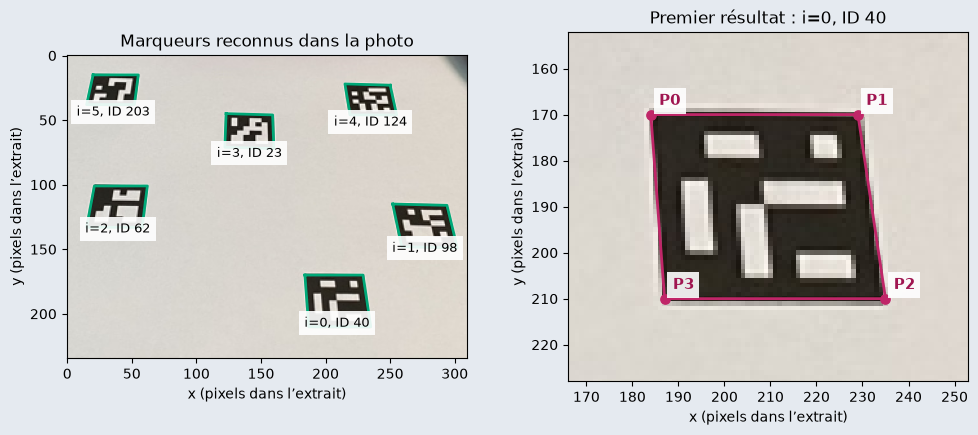

Identifiants après mise en forme : [ 40  98  62  23 124 203]
ID du premier marqueur : 40
coins[0], après reshape(4, 2) :
[[184. 170.]
 [229. 170.]
 [235. 210.]
 [187. 210.]]
P0 : x=184, y=170
P1 : x=229, y=170
P2 : x=235, y=210
P3 : x=187, y=210


In [13]:
# Réutiliser la photo couleur téléchargée à l’étape 1, sans ombre simulée.
photo_detection = photo_seuillage[140:375, 175:485].copy()
photo_grise = cv2.cvtColor(photo_detection, cv2.COLOR_BGR2GRAY)
# Cette photographie contient des marqueurs 6 × 6, différents de ceux du labo.
dictionnaire_photo = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
detecteur_photo = cv2.aruco.ArucoDetector(dictionnaire_photo, cv2.aruco.DetectorParameters())
coins, identifiants, candidats_rejetes = detecteur_photo.detectMarkers(photo_grise)

print('Identifiants renvoyés par OpenCV :')
print(identifiants)

if identifiants is None or np.asarray(identifiants).size == 0:
    afficher_image(photo_detection)
    print('Aucun marqueur reconnu.')
else:
    # Un seul indice par ID, quelle que soit la forme renvoyée par OpenCV.
    identifiants_lus = np.asarray(identifiants).reshape(-1)
    coins_premier = np.asarray(coins[0]).reshape(4, 2)

    figure, axes = plt.subplots(1, 2, figsize=(10, 4.8), facecolor='#e5eaf0')
    for axe in axes:
        axe.imshow(cv2.cvtColor(photo_detection, cv2.COLOR_BGR2RGB))
        axe.set_xlabel('x (pixels dans l’extrait)')
        axe.set_ylabel('y (pixels dans l’extrait)')

    # Chaque indice i associe un ID à ses quatre coins.
    for i, (points, identifiant) in enumerate(zip(coins, identifiants_lus)):
        points = np.asarray(points).reshape(4, 2)
        contour = np.vstack([points, points[0]])
        axes[0].plot(contour[:, 0], contour[:, 1], color='#00a878', linewidth=2)
        x, y = points.mean(axis=0)
        axes[0].text(x, y + 20, f'i={i}, ID {identifiant}', ha='center', fontsize=9,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.9))
    axes[0].set_title('Marqueurs reconnus dans la photo')

    # Le zoom conserve les coordonnées de l’extrait, sans les remettre à zéro.
    contour = np.vstack([coins_premier, coins_premier[0]])
    axes[1].plot(contour[:, 0], contour[:, 1], color='#c02668', linewidth=2)
    for j, (x, y) in enumerate(coins_premier):
        axes[1].scatter(x, y, s=45, color='#c02668')
        axes[1].annotate(f'P{j}', (x, y), xytext=(6, 7), textcoords='offset points',
                         fontsize=11, fontweight='bold', color='#a01550',
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.9))
    axes[1].set_xlim(coins_premier[:, 0].min() - 18, coins_premier[:, 0].max() + 18)
    axes[1].set_ylim(coins_premier[:, 1].max() + 18, coins_premier[:, 1].min() - 18)
    axes[1].set_title(f'Premier résultat : i=0, ID {identifiants_lus[0]}')
    figure.tight_layout(pad=1.5, w_pad=3)
    plt.show()
    plt.close(figure)

    print('Identifiants après mise en forme :', identifiants_lus)
    print('ID du premier marqueur :', identifiants_lus[0])
    print('coins[0], après reshape(4, 2) :')
    print(coins_premier)
    for j, (x, y) in enumerate(coins_premier):
        print(f'P{j} : x={x:g}, y={y:g}')


#### Lire les indices, un à la fois

`identifiants_lus = np.asarray(identifiants).reshape(-1)` donne un tableau à
une dimension, que la version d’OpenCV renvoie initialement une colonne ou
une liste de valeurs. **`identifiants_lus[0]` est l’ID du marqueur montré dans
le zoom**, pas nécessairement l’ID 0.

`coins[0]` contient les coins de ce même marqueur. La ligne
`coins_premier = np.asarray(coins[0]).reshape(4, 2)` les organise ainsi :

| Expression | Point dans le zoom | Contenu |
| --- | :---: | :---: |
| `coins_premier[0]` | P0 | `(x, y)` du premier coin |
| `coins_premier[1]` | P1 | `(x, y)` du deuxième coin |
| `coins_premier[2]` | P2 | `(x, y)` du troisième coin |
| `coins_premier[3]` | P3 | `(x, y)` du quatrième coin |

Les valeurs numériques exactes sont imprimées sous les images.
`coins_premier[j, 0]` donne **x** du coin `j` et `coins_premier[j, 1]` donne **y**.
Les axes du zoom gardent les coordonnées de l’extrait photographique.

Les coins délimitent la bordure noire du marqueur. L’ordre P0 à P3 suit
l’orientation du motif : P0 n’est pas forcément en haut à gauche dans la photo.

**`identifiants_lus[i]` et `coins[i]` décrivent toujours le même marqueur.**
Si `identifiants_lus[1]` vaut `5`, ses coins sont dans `coins[1]`, et non dans `coins[5]`.


#### Que contient `candidats_rejetes` ?

Chaque élément contient les quatre coins d’une forme examinée puis rejetée.
On utilise aussi `reshape(4, 2)` pour obtenir une ligne `(x, y)` par coin.
**Il n’y a pas d’identifiant correspondant dans `identifiants`.** Les positions
de cette collection sont indépendantes de celles des marqueurs reconnus.

**D’où vient `image_alteree` ?** Elle a été créée à l’étape 4, dans l’exemple
« Un carré repéré, mais un motif rejeté ». C’est une copie du marqueur ID 0
dans laquelle trois cases intérieures ont été inversées, sans modifier la
bordure noire ni la marge blanche. Exécutez cette cellule précédente pour la créer.

Nous réaffichons cette image ci-dessous. Le contour rouge est celui de
`candidats_rejetes[0]`, dont les coordonnées sont imprimées sous l’image.
Les étiquettes **C0 à C3** indiquent l’ordre des coins de ce candidat ; elles
ne représentent pas une orientation reconnue du motif, puisqu’il a été rejeté.
Le premier candidat n’est pas nécessairement le contour extérieur du marqueur.


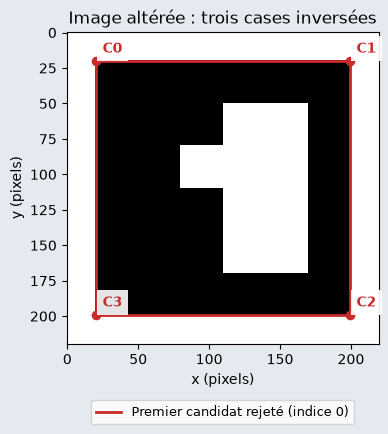

Nombre de marqueurs reconnus : 0
Identifiants : None
Nombre de candidats rejetés : 1
Quatre coins du premier candidat rejeté :
C0 : x=20, y=20
C1 : x=199, y=20
C2 : x=199, y=199
C3 : x=20, y=199


In [14]:
# image_alteree a été créée à l’étape 4, dans l’exemple
# « Un carré repéré, mais un motif rejeté » : trois cases de l’ID 0 sont inversées.
detecteur = cv2.aruco.ArucoDetector(DICTIONNAIRE_ARUCO, cv2.aruco.DetectorParameters())
coins_valides, ids_valides, candidats_rejetes = detecteur.detectMarkers(image_alteree)

figure, axe = plt.subplots(figsize=(4.5, 4.5), facecolor='#e5eaf0')
axe.imshow(image_alteree, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
axe.set_title('Image altérée : trois cases inversées')
axe.set_xlabel('x (pixels)')
axe.set_ylabel('y (pixels)')
if len(candidats_rejetes) > 0:
    # Montrer exactement le candidat dont on imprime les coordonnées ci-dessous.
    coins_rejetes = np.asarray(candidats_rejetes[0]).reshape(4, 2)
    contour = np.vstack([coins_rejetes, coins_rejetes[0]])
    axe.plot(contour[:, 0], contour[:, 1], color='#c92a2a', linewidth=2,
             label='Premier candidat rejeté (indice 0)')
    for j, (x, y) in enumerate(coins_rejetes):
        axe.scatter(x, y, color='#c92a2a', s=35)
        axe.annotate(f'C{j}', (x, y), xytext=(5, 6), textcoords='offset points',
                     color='#c92a2a', fontweight='bold',
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.9))
    axe.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), fontsize=9)
figure.tight_layout()
plt.show()
plt.close(figure)

print('Nombre de marqueurs reconnus :', len(coins_valides))
print('Identifiants :', ids_valides)
print('Nombre de candidats rejetés :', len(candidats_rejetes))
if len(candidats_rejetes) > 0:
    print('Quatre coins du premier candidat rejeté :')
    for j, (x, y) in enumerate(coins_rejetes):
        print(f'C{j} : x={x:g}, y={y:g}')


#### Regrouper l’ID et les coins pour la suite du labo

La fonction suivante **appelle OpenCV puis organise ses résultats**. Elle
regroupe l’ID et les coins d’un même marqueur dans un dictionnaire Python,
pour éviter de manipuler deux collections séparées dans la suite du programme.
Elle conserve seulement les IDs 0 à 5, par choix du labo.

- `identifiants.flatten()` transforme par exemple `[[2], [5]]` en `[2, 5]`.
- `zip` associe chaque tableau de coins à l’ID placé à la même position.
- `reshape(4, 2)` donne une ligne `(x, y)` par coin ; `astype(np.float32)`
  garantit le type numérique attendu pour les transformations géométriques.
- `_` reçoit les candidats rejetés, qui ne servent pas à placer les images virtuelles.

Si aucun marqueur n’est reconnu, OpenCV renvoie `None` pour les identifiants.
Notre fonction renvoie alors `[]`, une liste vide.


In [15]:
detecteur = cv2.aruco.ArucoDetector(DICTIONNAIRE_ARUCO, cv2.aruco.DetectorParameters())

def detecter_marqueurs(image, detecteur):
    gris = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    coins, identifiants, _ = detecteur.detectMarkers(gris)
    if identifiants is None:
        return []

    detections = []
    for points, identifiant in zip(coins, identifiants.flatten()):
        if 0 <= int(identifiant) <= 5:
            detections.append({
                'identifiant': int(identifiant),
                'coins': points.reshape(4, 2).astype(np.float32),
            })
    return detections


In [16]:
# Revenir au marqueur ID 0 du labo (4 × 4), dans image_test, déjà en BGR.
# La fonction du labo conserve seulement les IDs 0 à 5 : elle écarterait
# les IDs 23, 40, 62, 98, 124 et 203 présents dans la photographie.
detections = detecter_marqueurs(image_test, detecteur)
if detections:
    premier_marqueur = detections[0]
    print('ID :', premier_marqueur['identifiant'])
    print('Quatre coins :')
    print(premier_marqueur['coins'])
    print('Premier coin :', premier_marqueur['coins'][0])
else:
    print('Aucun marqueur du labo reconnu.')


ID : 0
Quatre coins :
[[ 20.  20.]
 [199.  20.]
 [199. 199.]
 [ 20. 199.]]
Premier coin : [20. 20.]


#### Et si l’image ne contient aucun marqueur ?

Sur une image entièrement blanche, il n’y a ni marqueur reconnu ni candidat
rejeté. Le résultat `None` indique l’absence d’IDs ; il ne désigne pas l’ID 0.


In [17]:
image_sans_marqueur = np.full_like(photo_detection, 255)
gris_sans_marqueur = cv2.cvtColor(image_sans_marqueur, cv2.COLOR_BGR2GRAY)
coins_absents, ids_absents, rejets_absents = detecteur.detectMarkers(gris_sans_marqueur)
print('Nombre de marqueurs reconnus :', len(coins_absents))
print('Identifiants :', ids_absents)
print('Nombre de candidats rejetés :', len(rejets_absents))
print('Résultat de notre fonction :', detecter_marqueurs(image_sans_marqueur, detecteur))


Nombre de marqueurs reconnus : 0
Identifiants : None
Nombre de candidats rejetés : 0
Résultat de notre fonction : []


### Pourquoi un marqueur peut ne pas être détecté

Dans ce laboratoire, chaque photo est analysée indépendamment. On recherche de
nouveau les marqueurs avant de dessiner les images virtuelles. Une absence de détection peut venir d’un
marqueur hors champ, mais aussi d’un marqueur présent et illisible, par exemple
à cause du flou. Elle ne prouve donc pas que le marqueur est hors du champ de la caméra.

Référence : [détection des marqueurs ArUco, documentation OpenCV](https://docs.opencv.org/4.13.0/d5/dae/tutorial_aruco_detection.html).


### Question 2

Programmez `collecter_detections` pour analyser une liste d’images avec le détecteur
fourni. Pour chaque image, renvoyez un dictionnaire contenant `identifiants`
(la liste des IDs détectés) et `coins` (la liste des tableaux de coordonnées
correspondants). Conservez l’ordre des quatre coins renvoyé par le détecteur.

**Image de départ : `image_test`, le marqueur ID 0 du dictionnaire `DICT_4X4_50`.**
Son motif mesure 180 × 180 pixels et sa marge blanche fait 20 pixels de chaque
côté : l’image complète mesure donc **220 × 220 pixels**, avec trois canaux BGR.
C’est le marqueur généré au début de la section. Pour éviter d’avoir à retrouver
cette cellule, **le bloc fourni au début de votre réponse recrée `image_test`** :
exécutez-le tel quel. La photographie à six marqueurs ne sert pas à cette question.

Construisez ensuite la liste `images_essai` dans cet ordre :

1. Une copie de `image_test`, sans rotation.
2. `image_test` tournée de 90° dans le sens horaire.
3. `image_test` tournée de 180°.
4. `image_test` tournée de 270° dans le sens horaire (ou 90° dans le sens antihoraire).
5. Une image entièrement blanche de mêmes dimensions que `image_test`.

Calculez **chaque rotation directement à partir de `image_test`**.
Utilisez `cv2.rotate` avec `cv2.ROTATE_90_CLOCKWISE`, `cv2.ROTATE_180` et
`cv2.ROTATE_90_COUNTERCLOCKWISE`. `image_test.copy()` fournit la première image
et `np.full_like(image_test, 255)` construit l’image blanche.

**Résultats attendus :** les listes d’identifiants sont `[0]`, `[0]`, `[0]`,
`[0]` et `[]`. Pour le marqueur original, les coins sont approximativement
`[(20, 20), (199, 20), (199, 199), (20, 199)]`. Après une rotation horaire de
90°, leur ordre devient `[(199, 20), (199, 199), (20, 199), (20, 20)]`.
Affichez les cinq images et les résultats calculés par votre fonction.

**Aperçu des résultats attendus**

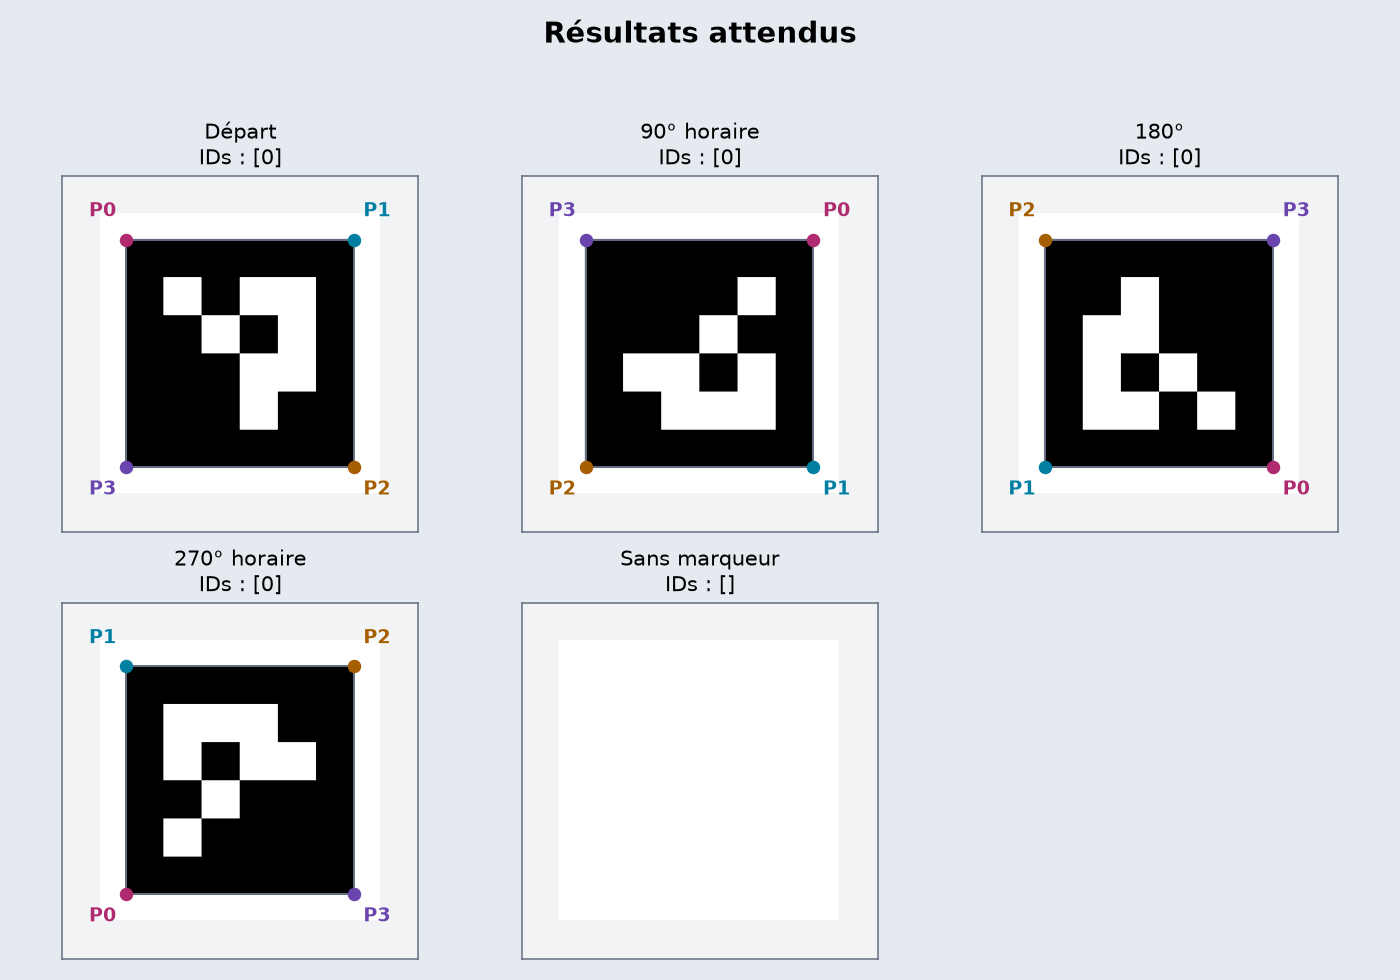

Les couleurs repèrent les mêmes coins P0 à P3 après chaque rotation. L’ID
reste 0. La dernière image ne porte aucun coin détecté.

Exécutez la fonction d’affichage fournie ci-dessous, puis complétez votre
cellule. Elle affichera **vos propres résultats** dans la même disposition,
avec les coordonnées numériques en dessous. L’affichage utilise les valeurs
renvoyées par `collecter_detections`, sans relancer le détecteur.


In [18]:
# Cette fonction d’affichage est fournie ; la détection reste à programmer.
def afficher_releves(images, releves, titre='Vos résultats'):
    if len(images) != 5:
        print('Construisez les cinq images dans images_essai pour les afficher.')
        return
    noms = ['Départ', '90° horaire', '180°', '270° horaire', 'Sans marqueur']
    couleurs = ['#b02a70', '#007fa3', '#a55e00', '#6945ad']
    figure, axes = plt.subplots(2, 3, figsize=(10, 7), facecolor='#e5eaf0')
    figure.suptitle(titre, fontsize=15, fontweight='bold')
    for i, (image, nom) in enumerate(zip(images, noms)):
        axe = axes.flat[i]
        axe.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        releve = releves[i] if i < len(releves) else None
        if releve is None:
            statut = 'Résultat manquant'
        else:
            statut = f"IDs : {releve['identifiants']}"
            for coins in releve['coins']:
                points = np.asarray(coins).reshape(4, 2)
                contour = np.vstack([points, points[0]])
                axe.plot(contour[:, 0], contour[:, 1], color='#667085', lw=1)
                for numero, (x, y) in enumerate(points):
                    couleur = couleurs[numero]
                    axe.scatter(x, y, s=35, color=couleur, zorder=3)
                    decalage = (-12 if x < image.shape[1]/2 else 12,
                                 12 if y < image.shape[0]/2 else -14)
                    axe.annotate(f'P{numero}', (x, y), xytext=decalage,
                                 textcoords='offset points', ha='center',
                                 color=couleur, weight='bold', fontsize=10)
        axe.set_title(f'{nom}\n{statut}', fontsize=11)
        axe.set_xlim(-30, image.shape[1] + 30)
        axe.set_ylim(image.shape[0] + 30, -30)
        axe.set_facecolor('#f1f3f5')
        axe.set_xticks([])
        axe.set_yticks([])
        for bordure in axe.spines.values():
            bordure.set_color('#667085')
    axes.flat[5].axis('off')
    figure.tight_layout(rect=(0, 0, 1, 0.94), h_pad=2)
    plt.show()
    plt.close(figure)
    for nom, releve in zip(noms, releves):
        print(nom, releve)

# Image également utilisée à la question 3.
image_tournee = cv2.rotate(image_test, cv2.ROTATE_90_CLOCKWISE)


In [19]:
# FOURNI : recréer l’image de départ de la question 2 (marqueur ID 0).
motif_q2 = cv2.aruco.generateImageMarker(DICTIONNAIRE_ARUCO, 0, 180)
marqueur_q2 = cv2.copyMakeBorder(motif_q2, 20, 20, 20, 20,
                                cv2.BORDER_CONSTANT, value=255)
image_test = cv2.cvtColor(marqueur_q2, cv2.COLOR_GRAY2BGR)

def collecter_detections(images, detecteur):
    releves = []
    # À COMPLÉTER : appeler detecter_marqueurs pour chaque image et collecter ses résultats.
    return releves

images_essai = []
# À COMPLÉTER : partir de image_test pour créer les cinq images dans l’ordre demandé.
releves_detections = collecter_detections(images_essai, detecteur)
afficher_releves(images_essai, releves_detections)


Construisez les cinq images dans images_essai pour les afficher.


### Question 3

Complétez `annoter_marqueurs` pour tracer le contour vert de chaque marqueur,
un point rouge au centre et le texte `ID n` près du centre.

Pour cette question, prenez comme centre la moyenne des quatre coins. C’est un
repère pratique dans l’image ; sous forte perspective, cette moyenne ne correspond
pas exactement à la projection du centre physique du carré.

Outils utiles : `coins.mean(axis=0)`, `np.rint`, `.astype(int)`,
`cv2.polylines`, `cv2.circle`, `cv2.putText`. Les fonctions de dessin attendent
des coordonnées entières. Elles modifient l’image passée en argument.

Exemple indépendant : `cv2.circle(image, (30, 40), 5, (0, 0, 255), -1)` dessine
un disque rouge de rayon 5 au point `(30, 40)`. `-1` demande un remplissage.
[Aide : fonctions de dessin](https://docs.opencv.org/4.13.0/dc/da5/tutorial_py_drawing_functions.html).

**Résultat attendu complet sur les cinq essais de la question 2**

La première rangée montre les images d’entrée ; la deuxième montre les résultats
attendus de `annoter_marqueurs`. Sur les quatre marqueurs, on doit voir le
**contour vert**, le **point rouge au centre** et le texte **`ID 0`** près du centre.
Le texte est dessiné horizontalement dans l’image, quelle que soit la rotation
du marqueur. L’image blanche reste blanche, sans aucune annotation.

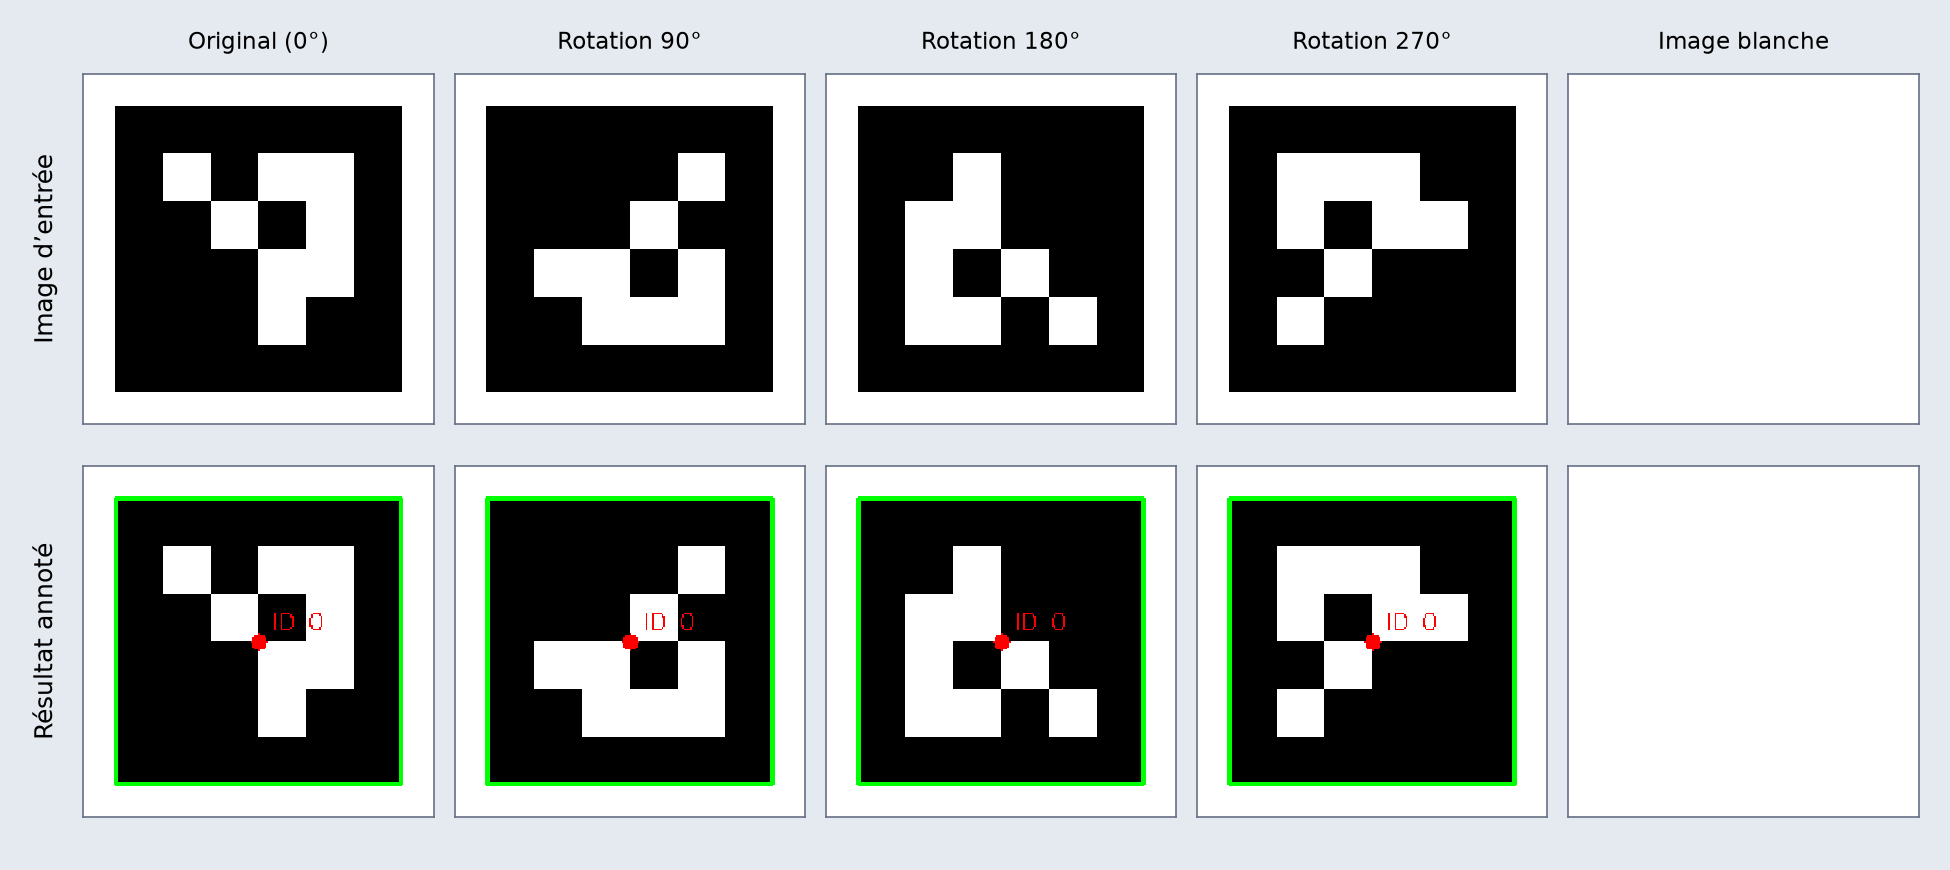

Les deux vérifications affichées sous vos résultats doivent donner **`True`** :
les cinq images d’entrée sont conservées intactes et un appel avec une liste
de détections vide renvoie une image identique à l’entrée.

Exécutez la fonction d’affichage fournie ci-dessous, puis complétez
`annoter_marqueurs`. Le bloc d’essai utilise **`images_essai` de la question 2**
et affiche vos cinq résultats dans la même disposition que cet aperçu.


In [20]:
# FOURNI : afficher les entrées et les résultats de votre fonction.
def afficher_annotations(images, resultats):
    titres = ['Original (0°)', 'Rotation 90°', 'Rotation 180°',
              'Rotation 270°', 'Image blanche']
    figure, axes = plt.subplots(2, 5, figsize=(13, 5.8), facecolor='#e5eaf0')
    for i, (image, resultat, titre) in enumerate(zip(images, resultats, titres)):
        for ligne, vue in enumerate([image, resultat]):
            axe = axes[ligne, i]
            axe.imshow(cv2.cvtColor(vue, cv2.COLOR_BGR2RGB), interpolation='nearest')
            axe.set_xticks([])
            axe.set_yticks([])
            for bordure in axe.spines.values():
                bordure.set_color('#667085')
        axes[0, i].set_title(titre, fontsize=11, pad=12)
    axes[0, 0].set_ylabel('Image d’entrée', fontsize=12, labelpad=12)
    axes[1, 0].set_ylabel('Résultat annoté', fontsize=12, labelpad=12)
    figure.tight_layout(pad=1.5, h_pad=2, w_pad=1)
    plt.show()
    plt.close(figure)


In [21]:
def annoter_marqueurs(image, detections):
    resultat = image.copy()
    for detection in detections:
        coins = detection['coins']
        identifiant = detection['identifiant']
        # À COMPLÉTER : calculer le centre ; dessiner le contour, le point et l’ID.
    return resultat

# Réutiliser les cinq images construites à la question 2.
if len(images_essai) != 5:
    print('Complétez images_essai à la question 2 pour afficher les cinq essais.')
else:
    copies_avant = [image.copy() for image in images_essai]
    resultats_annotes = [
        annoter_marqueurs(image, detecter_marqueurs(image, detecteur))
        for image in images_essai
    ]
    afficher_annotations(images_essai, resultats_annotes)
    print('Images d’entrée inchangées :',
          all(np.array_equal(image, copie) for image, copie in zip(images_essai, copies_avant)))
    print('Liste de détections vide : image inchangée :',
          np.array_equal(annoter_marqueurs(image_test, []), image_test))


Complétez images_essai à la question 2 pour afficher les cinq essais.


## 4. Créer le contenu virtuel

L’image virtuelle est elle aussi un tableau de pixels. Elle peut provenir d’un
fichier existant ou être dessinée par le programme. Nous la préparons de face,
dans son propre repère. Sa position dans la photo sera calculée ensuite.

L’exemple fourni construit une image virtuelle de 300 × 300 pixels avec un ID et une flèche.
La flèche est volontairement asymétrique : elle permet de voir si l’image virtuelle tourne
dans le bon sens. Les couleurs sont exprimées en BGR.


In [22]:
def creer_image_virtuelle(taille=300, identifiant=0):
    surface = np.full((taille, taille, 3), (60, 35, 20), dtype=np.uint8)
    palette = [(255, 210, 60), (80, 220, 130), (90, 130, 255),
               (220, 130, 220), (50, 220, 240), (220, 190, 150)]
    couleur = palette[identifiant % len(palette)]
    cv2.rectangle(surface, (5, 5), (taille - 6, taille - 6), couleur, 8)
    cv2.putText(surface, f'ID {identifiant}', (45, 85), cv2.FONT_HERSHEY_SIMPLEX,
                1.5, (255, 255, 255), 3)
    cv2.arrowedLine(surface, (150, 240), (150, 125), couleur, 10, tipLength=0.3)
    return surface


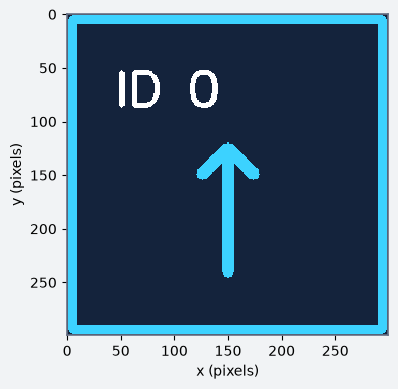

In [23]:
afficher_image(creer_image_virtuelle(identifiant=0))

### Charger une image depuis le Web

Une image PNG ou JPEG téléchargée peut servir directement de contenu virtuel.
La fonction fournie ci-dessous la décode au format BGR d’OpenCV et la place
dans un carré de 300 × 300 pixels, sans déformer ses proportions. Les zones
transparentes des PNG sont placées sur fond blanc.

L’adresse doit pointer vers le **fichier image**, et non vers une page Web.
Les téléchargements se font une seule fois, avant le traitement des captures.

Images d’exemple : [Twemoji, Twitter et contributeurs](https://github.com/twitter/twemoji),
sous licence [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
Elles sont redimensionnées et placées sur fond blanc dans ce laboratoire.


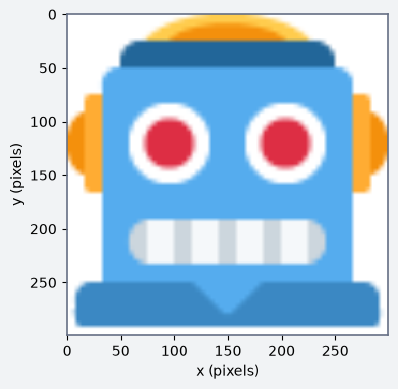

In [24]:
from urllib.request import urlopen

def charger_image_web(adresse, taille=300):
    # Télécharger les octets, puis décoder les pixels du PNG ou du JPEG.
    with urlopen(adresse, timeout=30) as reponse:
        donnees = np.frombuffer(reponse.read(), dtype=np.uint8)
    image = cv2.imdecode(donnees, cv2.IMREAD_UNCHANGED)
    if image is None:
        raise ValueError('L’adresse ne fournit pas une image lisible.')
    if image.ndim == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    elif image.shape[2] == 4:
        # Le quatrième canal règle la transparence ; le fond choisi est blanc.
        alpha = image[:, :, 3:4] / 255.0
        image = np.rint(image[:, :, :3] * alpha + 255 * (1 - alpha)).astype(np.uint8)

    # Garder les proportions et centrer l’image sur une surface blanche.
    hauteur, largeur = image.shape[:2]
    rapport = taille / max(hauteur, largeur)
    largeur, hauteur = max(1, round(largeur * rapport)), max(1, round(hauteur * rapport))
    image = cv2.resize(image, (largeur, hauteur))
    surface = np.full((taille, taille, 3), 255, dtype=np.uint8)
    x, y = (taille - largeur) // 2, (taille - hauteur) // 2
    surface[y:y + hauteur, x:x + largeur] = image
    return surface

base_images = 'https://raw.githubusercontent.com/twitter/twemoji/v14.0.2/assets/72x72/'
url_joueur = base_images + '1f916.png'  # Robot
url_objet = base_images + '1f48e.png'   # Diamant
image_joueur = charger_image_web(url_joueur)
image_defaut = np.full((300, 300, 3), 230, dtype=np.uint8)
afficher_image(image_joueur)


### Question 4

Associez une image existante à chaque rôle : **ID 0 → joueur**, **ID 1 → objet
à ramasser**. L’image du joueur est déjà chargée ci-dessus. Chargez celle de
l’objet avec `charger_image_web(url_objet)`, puis construisez le dictionnaire
Python `images_par_id` qui associe chaque ID à son tableau de pixels.

Complétez `personnaliser_image_virtuelle` pour renvoyer une **copie** de l’image
associée à l’ID. Pour les autres IDs, renvoyez une copie d’`image_defaut`.
`un_dictionnaire.get(cle, valeur_par_defaut)` permet cette sélection.
Dans la fonction, modifiez l’affectation de `image_selectionnee` pour effectuer
cette sélection. Conservez `return image_selectionnee.copy()` : cette ligne
renvoie une copie de l’image choisie.
Placez le téléchargement hors de la fonction pour ne pas le répéter à chaque capture.

Vous pouvez remplacer les deux adresses par celles d’autres images PNG ou JPEG
dont l’utilisation est permise. Choisissez des images distinctes avec un haut reconnaissable.

**Pour vérifier :** les deux images font 300 × 300 × 3, leur type reste `uint8`
et elles se distinguent visuellement. Affichez aussi chaque image tournée de
90° pour vérifier que son orientation reste reconnaissable.

**Exemple de résultat attendu**

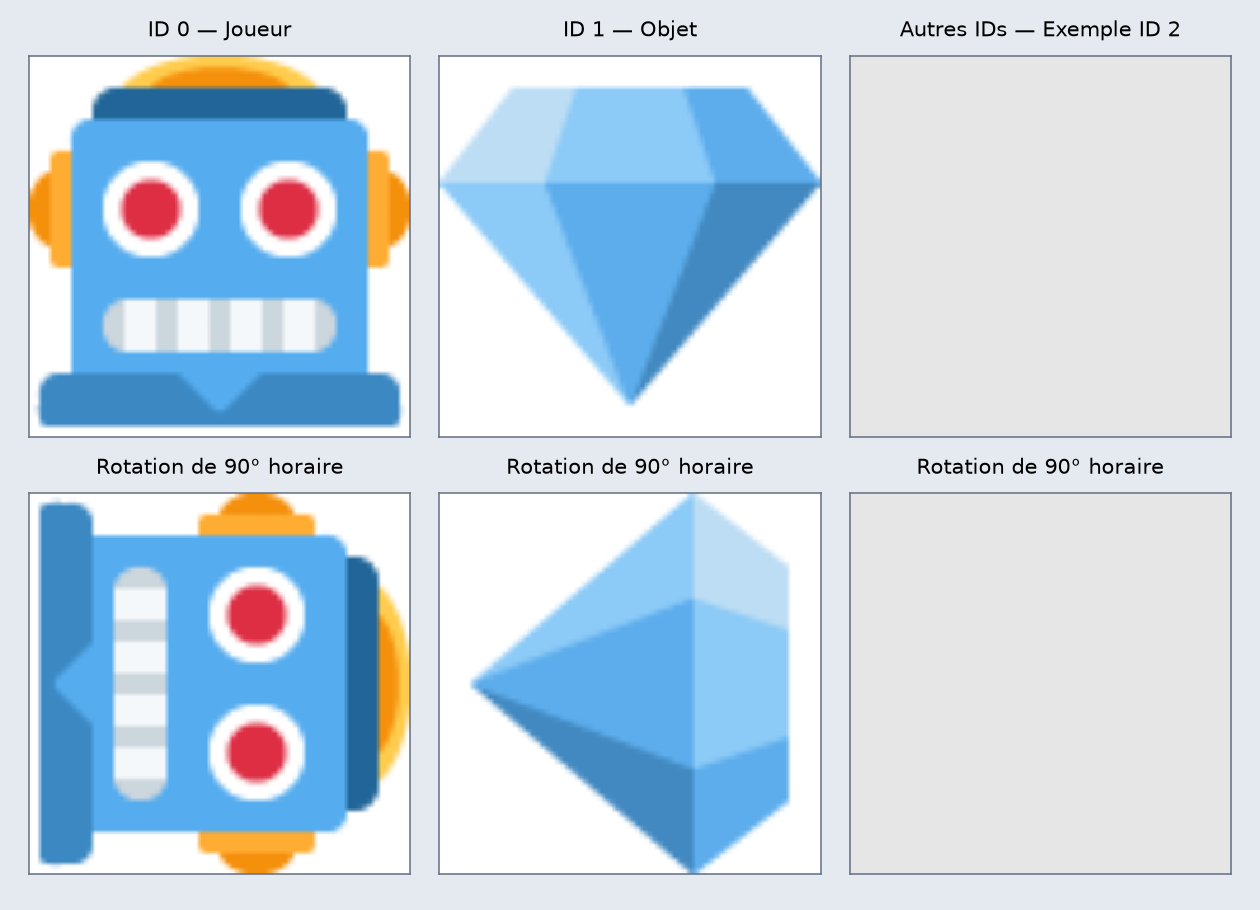

En haut : les images personnalisées. En bas : les mêmes images tournées de
90° dans le sens horaire. Le carré gris est l’apparence commune des autres IDs.
La cellule à compléter affiche d’abord ce carré pour tous les IDs ; une fois
terminée, elle doit afficher vos images aux places correspondantes.


ID : 0 — Original et rotation de 90°


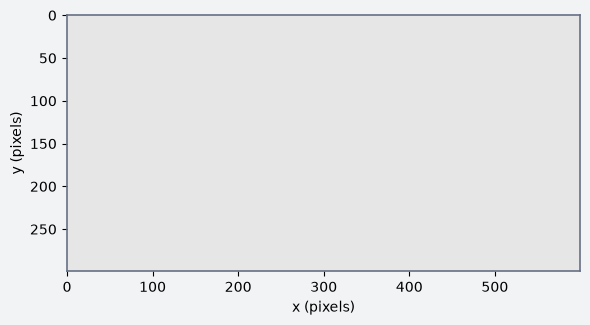

ID : 1 — Original et rotation de 90°


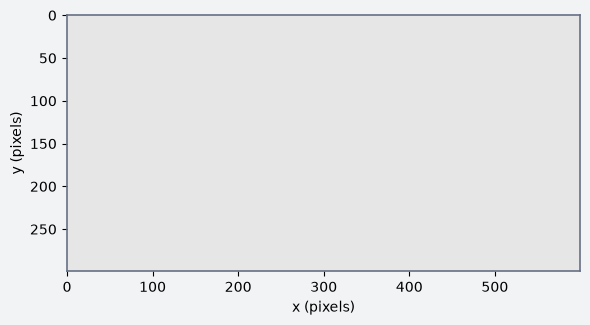

ID : 2 — Original et rotation de 90°


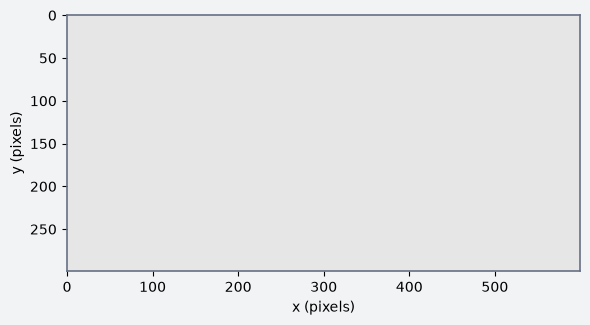

In [25]:
# À COMPLÉTER : charger l’image de l’objet, puis associer les IDs 0 et 1 aux images.
images_par_id = {}

def personnaliser_image_virtuelle(identifiant):
    # À MODIFIER : remplacer image_defaut ci-dessous par la sélection dans images_par_id.
    # Si l’ID est absent, utiliser image_defaut comme valeur par défaut.
    image_selectionnee = image_defaut
    return image_selectionnee.copy()

for identifiant in (0, 1, 2):
    image = personnaliser_image_virtuelle(identifiant)
    image_tournee_virtuelle = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    print('ID :', identifiant, '— Original et rotation de 90°')
    afficher_image(np.hstack([image, image_tournee_virtuelle]))


## 5. Adapter l’image virtuelle à la perspective


Par exemple, un coin du marqueur passe de `(120, 80)` à `(150, 90)` entre deux
photos. Il s’est déplacé dans l’image de `150 − 120 = 30` pixels vers la droite
et de `90 − 80 = 10` pixels vers le bas. Un point dessiné à `(120, 80)` dans les
deux photos reste fixe dans l’image : pour coïncider avec ce coin dans la seconde,
il faut le dessiner à `(150, 90)`.

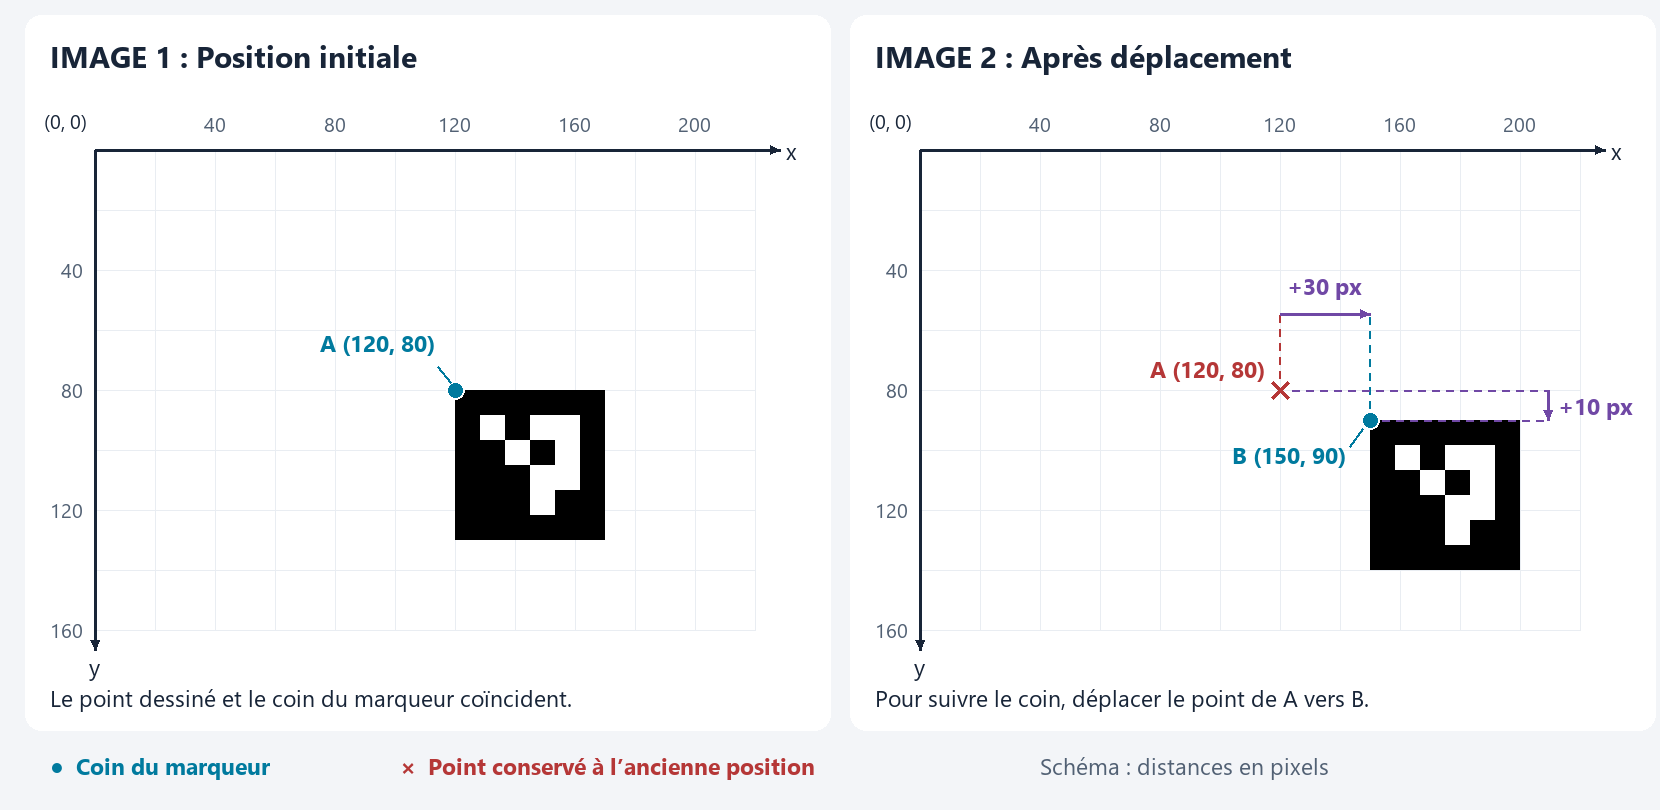


### Passer d’un point à une surface

Pour superposer l’image virtuelle au marqueur, il faut déterminer sa position,
sa taille, son orientation et sa déformation. Un carré vu de biais peut apparaître
comme un quadrilatère dont les côtés opposés ne sont plus parallèles. C’est un
effet de perspective.

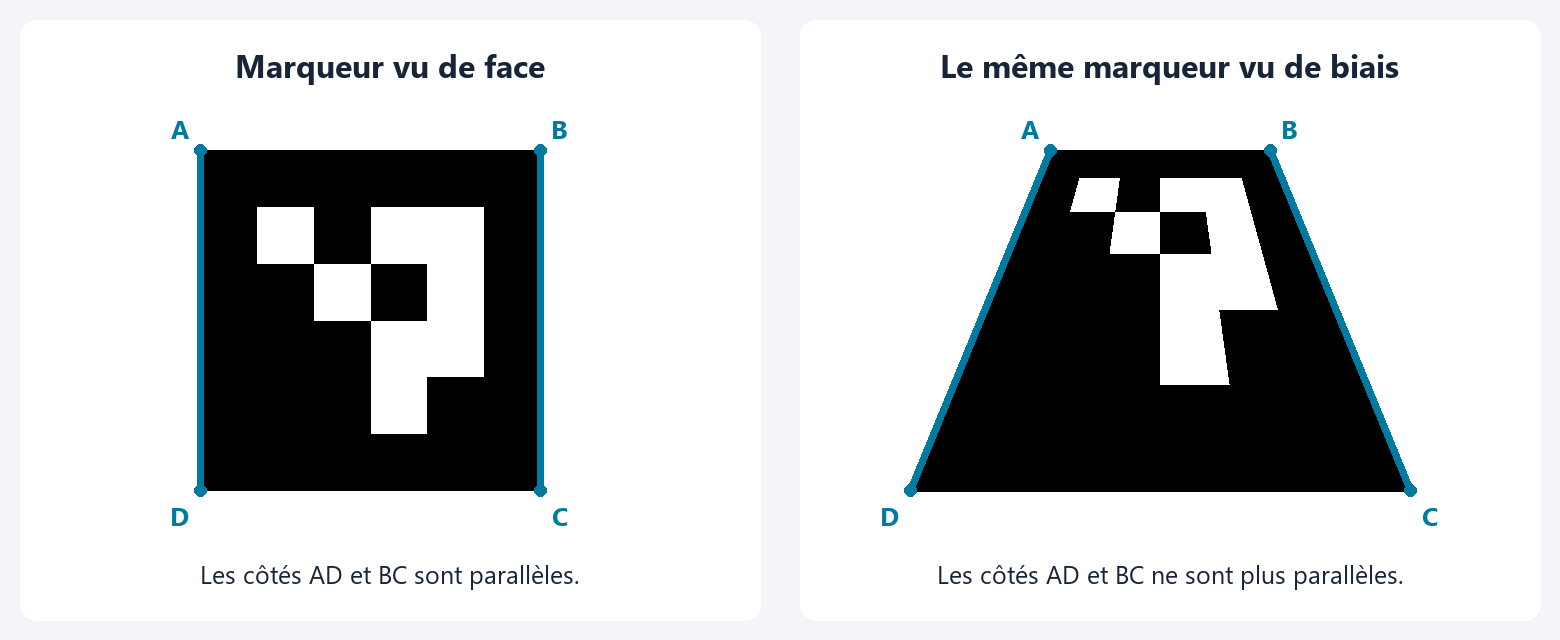

Le marqueur imprimé reste carré ; sa projection dans l’image change.
L’image virtuelle doit épouser le quadrilatère ABCD de chaque vue.


### Démonstration — Pourquoi une translation ne suffit pas

L’image virtuelle est d’abord alignée sur le marqueur. Entre deux captures,
son coin A passe de `(50, 50)` à `(130, 70)` et son coin B de `(150, 50)` à
`(210, 110)`. Essayons de déplacer toute l’image virtuelle comme le coin A.

La cellule fournie calcule cette translation et montre le marqueur avant et
après. Les vues sont générées à partir de ces coordonnées. Le contour rouge
représente les limites de l’image virtuelle ; son contenu est masqué pour
laisser le marqueur visible.

**A reste aligné, mais B se retrouve 20 pixels trop à droite et 40 pixels trop
haut.** Une translation seule ne suit donc pas le changement d’orientation
et de perspective du marqueur. L’homographie présentée ensuite permettra de
faire correspondre les quatre coins de l’image virtuelle à ceux du marqueur.


In [26]:
# FOURNI : montrer le marqueur et le contour de l’image virtuelle.
def afficher_alignement_ra(coins_avant, coins_apres, coins_translates):
    # Les coins inférieurs complètent les deux poses pour cette illustration.
    marqueur_avant = np.float32([coins_avant[0], coins_avant[1], [150, 150], [50, 150]])
    marqueur_apres = np.float32([coins_apres[0], coins_apres[1], [200, 210], [95, 155]])
    virtuel_apres = np.float32([coins_translates[0], coins_translates[1],
                                coins_translates[1] + [0, 100], coins_translates[0] + [0, 100]])
    dictionnaire_visuel = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
    motif = cv2.aruco.generateImageMarker(dictionnaire_visuel, 0, 180)
    papier = cv2.copyMakeBorder(motif, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=255)
    source = np.float32([[20, 20], [199, 20], [199, 199], [20, 199]])
    figure, axes = plt.subplots(1, 2, figsize=(10, 5.4), facecolor='#e5eaf0')
    for axe, coins_marqueur, coins_virtuels, titre in zip(
            axes, [marqueur_avant, marqueur_apres], [marqueur_avant, virtuel_apres],
            ['AVANT : image virtuelle alignée', 'APRÈS : translation suivant A']):
        # Dessiner le même marqueur dans chacune des deux poses.
        H_visuel = cv2.getPerspectiveTransform(source, coins_marqueur)
        vue = cv2.warpPerspective(papier, H_visuel, (300, 250),
                                  flags=cv2.INTER_NEAREST, borderValue=230)
        axe.imshow(vue, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        contour = np.vstack([coins_marqueur, coins_marqueur[0]])
        axe.plot(contour[:, 0], contour[:, 1], color='#087f5b', linewidth=3,
                 label='Contour du marqueur')
        contour = np.vstack([coins_virtuels, coins_virtuels[0]])
        axe.plot(contour[:, 0], contour[:, 1], '--', color='#c92a2a', linewidth=2,
                 label='Contour de l’image virtuelle')
        axe.set_title(titre, fontsize=12, pad=12)
        axe.set_xlabel('x (pixels)')
        axe.set_ylabel('y (pixels)')
        axe.set_xlim(20, 280)
        axe.set_ylim(235, 20)
    etiquette = dict(facecolor='white', edgecolor='none', alpha=0.95)
    for nom, point in zip(['A', 'B'], coins_avant):
        axes[0].annotate(nom, point, xytext=(0, 12), textcoords='offset points',
                         ha='center', fontweight='bold', bbox=etiquette)
    axes[1].annotate('A : aligné', coins_apres[0], xytext=(-8, 15),
                     textcoords='offset points', ha='right', fontsize=10, bbox=etiquette)
    axes[1].annotate('B détecté', coins_apres[1], xytext=(12, -5),
                     textcoords='offset points', ha='left', color='#087f5b', fontsize=9, bbox=etiquette)
    axes[1].annotate('B virtuel', coins_translates[1], xytext=(0, 15),
                     textcoords='offset points', ha='center', color='#c92a2a', fontsize=9, bbox=etiquette)
    axes[1].annotate('', xy=coins_translates[1], xytext=coins_apres[1],
                 arrowprops=dict(arrowstyle='->', color='#c92a2a', linestyle='--', lw=1.5))
    figure.legend(*axes[0].get_legend_handles_labels(), loc='lower center',
                  bbox_to_anchor=(0.5, 0.03), fontsize=10, ncol=2)
    figure.subplots_adjust(left=0.07, right=0.98, top=0.90, bottom=0.20, wspace=0.25)
    plt.show()
    plt.close(figure)


Déplacements détectés de A et B : [[80. 20.]
 [60. 60.]]
Positions des coins virtuels : [[130.  70.]
 [230.  70.]]
Erreur sur B (pixels) : [ 20. -40.]
Translation suffisante : False


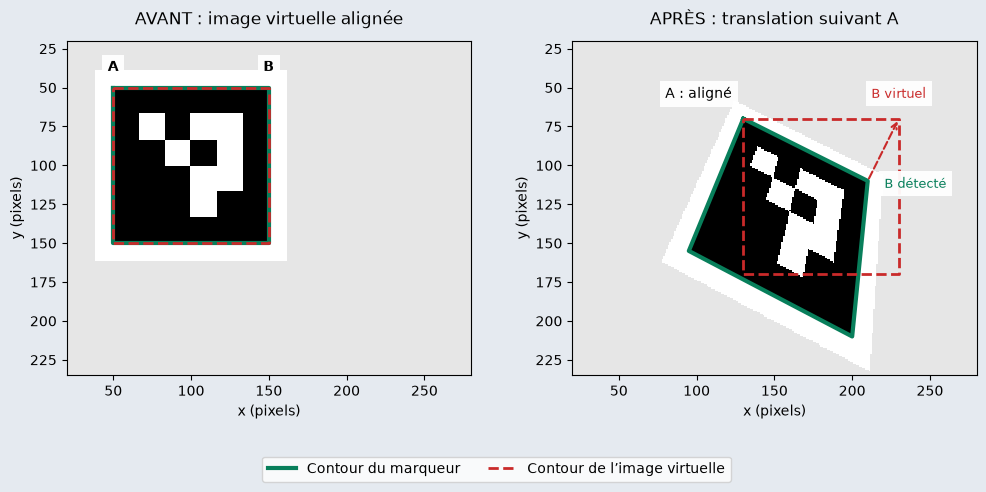

In [27]:
# Démonstration fournie : déplacer toute l’image virtuelle comme le coin A.
coins_avant = np.array([[50, 50], [150, 50]], dtype=float)
coins_apres = np.array([[130, 70], [210, 110]], dtype=float)

deplacements = coins_apres - coins_avant
coins_translates = coins_avant + deplacements[0]
erreur_b = coins_translates[1] - coins_apres[1]
translation_suffisante = np.allclose(coins_translates, coins_apres)

print('Déplacements détectés de A et B :', deplacements)
print('Positions des coins virtuels :', coins_translates)
print('Erreur sur B (pixels) :', erreur_b)
print('Translation suffisante :', translation_suffisante)
afficher_alignement_ra(coins_avant, coins_apres, coins_translates)


### L’homographie

Une **homographie** décrit une transformation projective entre
deux plans, ou entre deux vues d’un même plan.

Nous faisons correspondre quatre points de l’image virtuelle à quatre points de la photo.
Dans chacune des deux images, les quatre points doivent être distincts et
aucun groupe de trois points ne doit se trouver sur une même droite. Les quatre
coins d’un carré respectent cette condition. Trois points choisis sur un même
côté ne la respectent pas. Les coins de départ et d’arrivée doivent aussi être
associés dans le même ordre. `cv2.getPerspectiveTransform(source, destination)` calcule une matrice
`H` de forme 3 × 3. `cv2.warpPerspective` utilise ensuite cette matrice pour déformer
l’image. [Référence : transformations géométriques OpenCV](https://docs.opencv.org/4.13.0/da/d6e/tutorial_py_geometric_transformations.html).


### Exemple

L’image virtuelle est ramenée à **101 × 101 pixels**, dont les indices vont de
0 à 100. Ses quatre coins doivent rejoindre les positions suivantes dans la photo.
Toutes les coordonnées ci-dessous sont en pixels, avec `y` croissant vers le bas.

| Correspondance | Dans l’image virtuelle $(x,y)$ | Dans la photo $(x',y')$ |
| --- | --- | --- |
| A → A′ | $(0,0)$ | $(100,50)$ |
| B → B′ | $(100,0)$ | $(200,50)$ |
| C → C′ | $(100,100)$ | $(250,200)$ |
| D → D′ | $(0,100)$ | $(50,200)$ |

Le prime (′) désigne le point après transformation. Les deux tableaux de coordonnées
suivront les ordres **A, B, C, D** et **A′, B′, C′, D′**.
Nous suivrons aussi le centre $E=(50,50)$ pour vérifier la transformation.

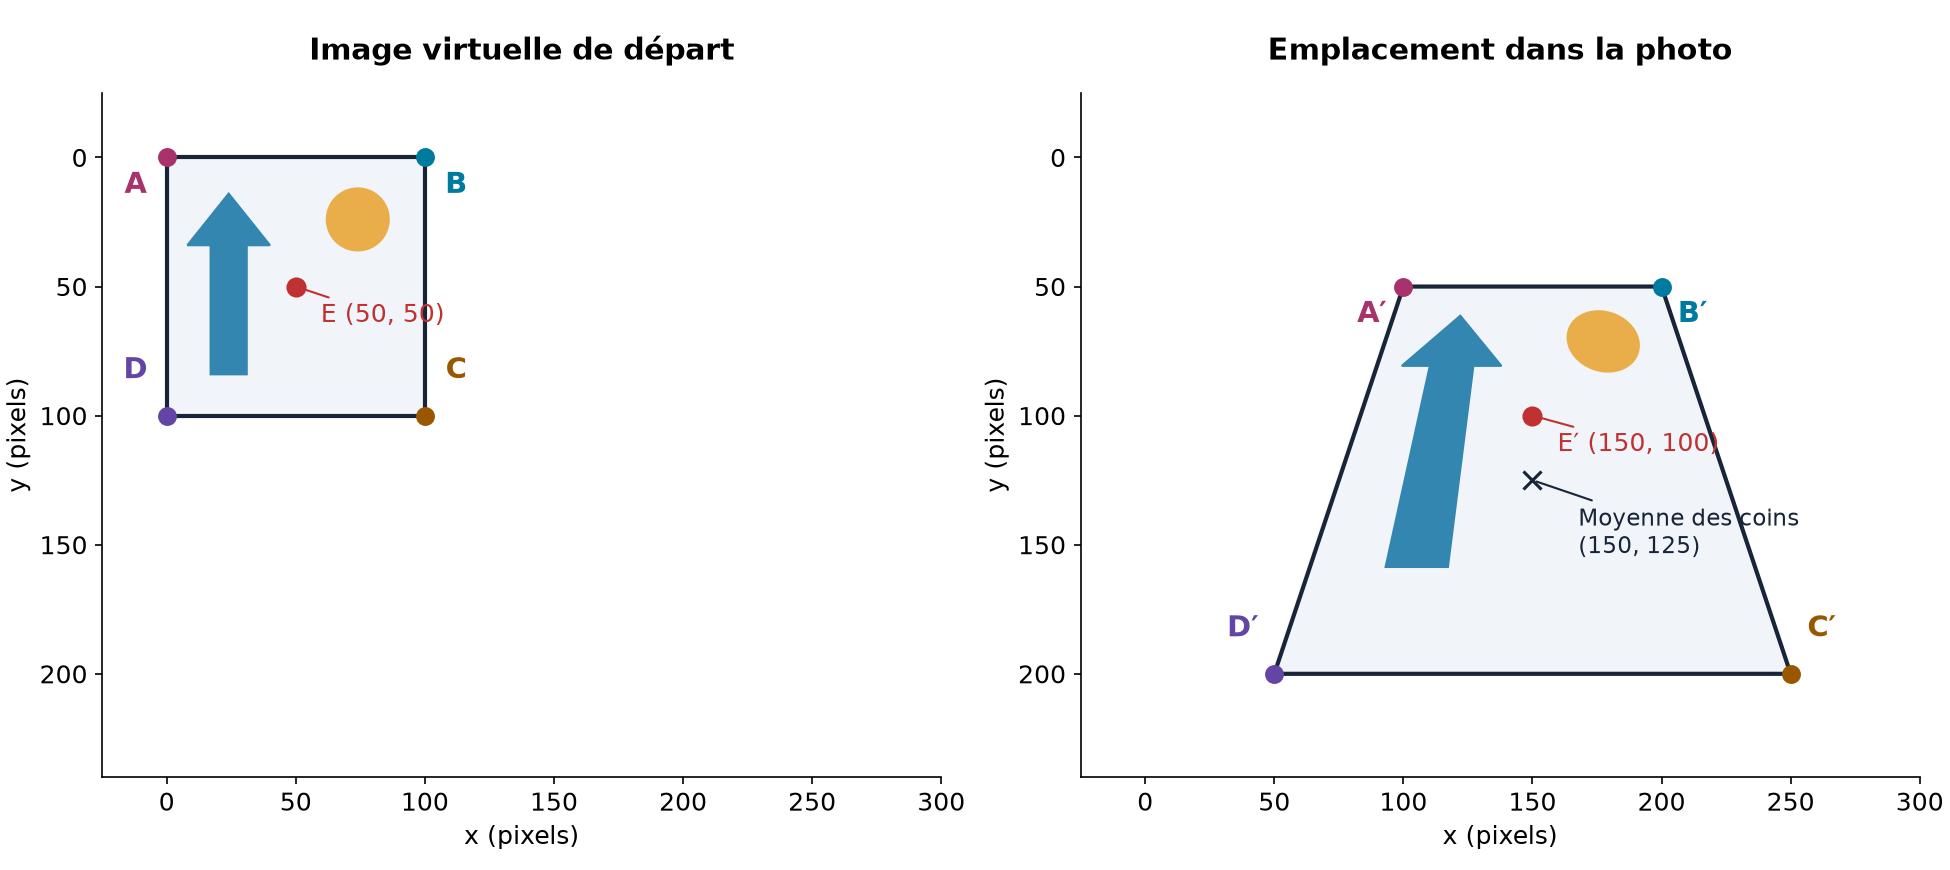


### Écrire la transformation

Avant de fixer le coefficient inférieur droit à 1, appelons-le $k$.

$$
H=\begin{bmatrix}a&b&c\\d&e&f\\g&h&k\end{bmatrix}.
$$

Pour le coin $A=(0,0)$, le produit matriciel sélectionne sa dernière colonne.

$$
H\begin{bmatrix}0\\0\\1\end{bmatrix}
=\begin{bmatrix}c\\f\\k\end{bmatrix}.
$$

Les coordonnées dans la photo s’obtiennent en divisant les deux premières
composantes par la troisième. Or, nous imposons $A'=(100,50)$, donc

$$
\frac{c}{k}=100,\qquad
\frac{f}{k}=50.
$$

Il faut donc $k\ne0$. S’il était nul, l’image de l’origine serait un point
à l’infini, et ne pourrait pas être le point $(100,50)$ demandé.

On peut alors diviser **tous les coefficients** par $k$ sans changer les
coordonnées obtenues après division. Le coefficient inférieur droit devient 1.
Pour la suite, on garde les lettres $a,b,c,d,e,f,g,h$ pour désigner les coefficients
après cette division.

On note $(u,v,w)$ le résultat intermédiaire du produit matriciel.
Les coordonnées finales dans la photo restent notées $(x',y')$.

$$
H=\begin{bmatrix}a&b&c\\d&e&f\\g&h&1\end{bmatrix},\qquad
\begin{bmatrix}u\\v\\w\end{bmatrix}
=H\begin{bmatrix}x\\y\\1\end{bmatrix}
=\begin{bmatrix}ax+by+c\\dx+ey+f\\gx+hy+1\end{bmatrix}.
$$

Le 1 ajouté à $(x,y)$ sert à effectuer ce calcul matriciel. Il ne représente
pas une troisième dimension de l’image. Le résultat $(u,v,w)$ donne des
**coordonnées homogènes**. Pour retrouver une position dans la photo, on divise
les deux premières composantes par la troisième, à condition que $w\ne0$.

$$
\begin{bmatrix}u\\v\\w\end{bmatrix}
=w\begin{bmatrix}x'\\y'\\1\end{bmatrix},\qquad
x'=\frac{u}{w},\qquad y'=\frac{v}{w}.
$$

En remplaçant $u$, $v$ et $w$ par les expressions calculées ci-dessus, on obtient

$$
x'=\frac{ax+by+c}{gx+hy+1},\qquad
y'=\frac{dx+ey+f}{gx+hy+1}.
$$

Si $g=h=0$, le dénominateur vaut toujours 1 et la transformation est affine.
Ici, il varie avec la position du point. C’est ce qui permet de transformer
le carré en trapèze sans conserver le parallélisme de tous ses côtés.


### Calculer les coefficients à partir des coins

Pour une correspondance, les coordonnées $(x,y)$ et $(x',y')$ sont connues.
Les inconnues sont les huit coefficients $a,b,c,d,e,f,g,h$.

Partons de l’expression de $x'$. On multiplie les deux membres par le
dénominateur $gx+hy+1$, supposé non nul, puis on développe le membre de gauche.

$$
\begin{aligned}
x' &= \frac{ax+by+c}{gx+hy+1}\\[4pt]
x'(gx+hy+1) &= ax+by+c\\
xx'g+yx'h+x' &= ax+by+c.
\end{aligned}
$$

On soustrait $xx'g+yx'h$ des deux membres et on place les termes contenant
les inconnues à gauche. Les produits étant commutatifs, $ax=xa$ et $by=yb$.

$$
xa+yb+c-xx'g-yx'h=x'.
$$

On effectue les mêmes opérations pour $y'$.

$$
\begin{aligned}
y' &= \frac{dx+ey+f}{gx+hy+1}\\[4pt]
y'(gx+hy+1) &= dx+ey+f\\
xy'g+yy'h+y' &= dx+ey+f\\
xd+ye+f-xy'g-yy'h &= y'.
\end{aligned}
$$

Ces deux équations sont **linéaires par rapport aux huit inconnues**.
Les produits $xx'$, $yx'$, $xy'$ et $yy'$ sont des nombres connus,
calculés à partir des coordonnées. Chaque correspondance fournit ainsi
deux lignes du système à résoudre.


### Construire les huit équations

Pour $A=(0,0)\mapsto(100,50)$, on trouve directement $c=100$ et $f=50$.
Pour $B=(100,0)\mapsto(200,50)$, les deux équations deviennent

$$
100a+c-20000g=200,\qquad 100d+f-5000g=50.
$$

En ajoutant C et D, le système complet est

$$
\begin{aligned}
c &=100 & f&=50 &&\text{(A)}\\
100a+c-20000g &=200 & 100d+f-5000g&=50 &&\text{(B)}\\
100a+100b+c-25000g-25000h &=250 & 100d+100e+f-20000g-20000h&=200 &&\text{(C)}\\
100b+c-5000h &=50 & 100e+f-20000h&=200 &&\text{(D)}.
\end{aligned}
$$


### Écrire le système sous forme matricielle

On regroupe les huit inconnues dans le vecteur
$\theta=(a,b,c,d,e,f,g,h)^T$. Le système s’écrit $M\theta=\mathbf{b}$.
Chaque paire de lignes correspond à un coin, dans l’ordre A, B, C, D.
La première ligne de chaque paire donne $x'$, la seconde donne $y'$.

$$
\underbrace{\begin{bmatrix}
0&0&1&0&0&0&0&0\\
0&0&0&0&0&1&0&0\\
100&0&1&0&0&0&-20000&0\\
0&0&0&100&0&1&-5000&0\\
100&100&1&0&0&0&-25000&-25000\\
0&0&0&100&100&1&-20000&-20000\\
0&100&1&0&0&0&0&-5000\\
0&0&0&0&100&1&0&-20000
\end{bmatrix}}_{M}
\underbrace{\begin{bmatrix}a\\b\\c\\d\\e\\f\\g\\h\end{bmatrix}}_{\theta}
=\underbrace{\begin{bmatrix}100\\50\\200\\50\\250\\200\\50\\200\end{bmatrix}}_{\mathbf{b}}.
$$

Par exemple, la troisième ligne redonne $100a+c-20000g=200$.
Le vecteur $\mathbf{b}$ contient les coordonnées de destination. Il ne faut pas
le confondre avec le coefficient scalaire $b$ de l’homographie.


### Résoudre par la matrice inverse

$M$ est la matrice $8\times8$ du système qui détermine les coefficients.
Elle est inversible lorsque les quatre points sont distincts, sans trois points
sur une même droite, dans **chacune des deux images**, et que la normalisation
du coefficient inférieur droit à 1 est possible. Nos correspondances satisfont
ces conditions.

Ce n’est pas garanti pour des correspondances quelconques. Par exemple, répéter
deux fois la même correspondance répète deux lignes de $M$. Les huit équations
ne sont alors plus indépendantes et $M$ n’est pas inversible.

À distinguer de $H$, la matrice $3\times3$ de la transformation. Une homographie
est, par définition, représentée par une matrice $H$ inversible.

Ici, on peut donc multiplier **à gauche** les deux membres par $M^{-1}$.

$$
M^{-1}M\theta=M^{-1}\mathbf{b},\qquad
I_8\theta=M^{-1}\mathbf{b},\qquad
\theta=M^{-1}\mathbf{b}
=\begin{bmatrix}1\\-0{,}75\\100\\0\\0{,}5\\50\\0\\-0{,}005\end{bmatrix}.
$$

$I_8$ est la matrice identité de taille $8\times8$. On replace ces huit
coefficients dans $H$ et on conserve le coefficient inférieur droit égal à 1.

$$
H=\begin{bmatrix}
1&-0{,}75&100\\
0&0{,}5&50\\
0&-0{,}005&1
\end{bmatrix}.
$$

La matrice $M^{-1}$ sert à trouver les coefficients de $H$. Elle est différente
de $H^{-1}$, qui ferait la transformation géométrique inverse, de la photo vers
l’image virtuelle.

La cellule suivante traduit $M^{-1}\mathbf{b}$ par
`np.linalg.inv(systeme) @ second_membre`. L’opérateur `@` effectue le produit
matriciel. On compare ensuite avec `np.linalg.solve`, qui résout directement
le système sans construire son inverse, puis avec OpenCV.


In [28]:
coins_source = np.float32([[0, 0], [100, 0], [100, 100], [0, 100]])
destination = np.float32([[100, 50], [200, 50], [250, 200], [50, 200]])

# Les colonnes correspondent aux inconnues a, b, c, d, e, f, g, h.
lignes = []
valeurs = []
for (x, y), (xp, yp) in zip(coins_source, destination):
    lignes.append([x, y, 1, 0, 0, 0, -x*xp, -y*xp])
    lignes.append([0, 0, 0, x, y, 1, -x*yp, -y*yp])
    valeurs.extend([xp, yp])

systeme = np.array(lignes, dtype=float)
second_membre = np.array(valeurs, dtype=float)
inverse_systeme = np.linalg.inv(systeme)
coefficients_par_inverse = inverse_systeme @ second_membre
coefficients = np.linalg.solve(systeme, second_membre)
H_calculee = np.append(coefficients, 1).reshape(3, 3)
H = cv2.getPerspectiveTransform(coins_source, destination)

print('Coefficients obtenus par la matrice inverse :', np.round(coefficients_par_inverse, 6))
print('Même solution par résolution directe :', np.allclose(coefficients_par_inverse, coefficients))
print('Matrice calculée avec NumPy :', np.round(H_calculee, 6), sep='\n')
print('Même matrice avec OpenCV :', np.allclose(H_calculee, H))
coins_projetes = cv2.perspectiveTransform(coins_source[None], H)[0]
print('Coins projetés :', coins_projetes, sep='\n')
print('Erreur maximale sur les coins :', np.max(np.abs(coins_projetes - destination)))


Coefficients obtenus par la matrice inverse : [ 1.0e+00 -7.5e-01  1.0e+02  0.0e+00  5.0e-01  5.0e+01  0.0e+00 -5.0e-03]
Même solution par résolution directe : True
Matrice calculée avec NumPy :
[[ 1.0e+00 -7.5e-01  1.0e+02]
 [ 0.0e+00  5.0e-01  5.0e+01]
 [ 0.0e+00 -5.0e-03  1.0e+00]]
Même matrice avec OpenCV : True
Coins projetés :
[[100.  50.]
 [200.  50.]
 [250. 200.]
 [ 50. 200.]]
Erreur maximale sur les coins : 0.0


### Transformer un point intérieur

Pour le centre $E=(50,50)$, le produit matriciel donne

$$
\begin{aligned}
u &= 1\times50-0{,}75\times50+100=112{,}5,\\
v &= 0\times50+0{,}5\times50+50=75,\\
w &= 0\times50-0{,}005\times50+1=0{,}75.
\end{aligned}
$$

On doit encore diviser par $w$ pour obtenir les coordonnées dans la photo.

$$
x'=112{,}5/0{,}75=150,\qquad y'=75/0{,}75=100.
$$

Le centre devient donc **$E'=(150,100)$**. Sans cette division, on le placerait
incorrectement en $(112{,}5,75)$.

On peut aussi vérifier le coin C. Pour $(100,100)$, on obtient
$(u,v,w)=(125,100,0{,}5)$, puis $(x',y')=(250,200)$, comme dans le tableau.

Multiplier tous les coefficients de $H$ par 2 donne $(225,150,1{,}5)$ pour E.
Après division, on retrouve $(150,100)$. Cela explique pourquoi une même
homographie peut être représentée par plusieurs matrices proportionnelles.


### Placer une cible au centre du marqueur

On veut superposer une cible au centre d’un marqueur carré. Vu de face, son centre
est $E=(50,50)$, à l’intersection des diagonales. Reprenons les quatre coins de la
photo de biais utilisés dans notre calcul de $H$.

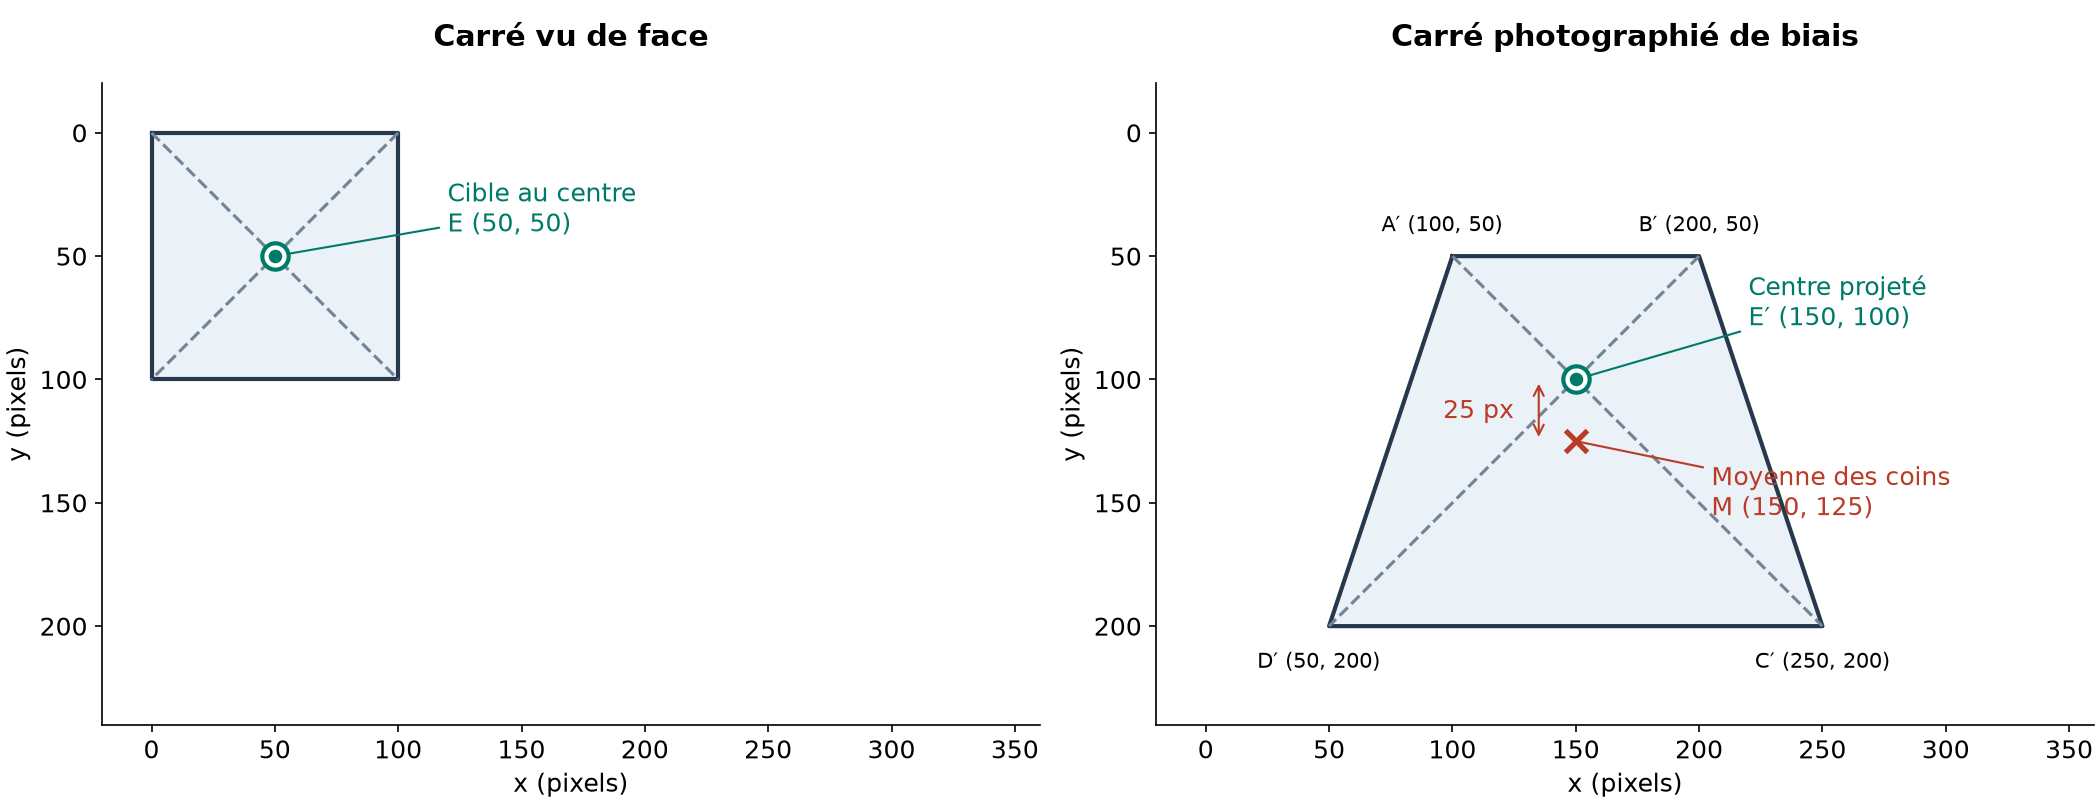

**En faisant la moyenne des coins de la photo**, on obtient

$$
M=\left(\frac{100+200+250+50}{4},\frac{50+50+200+200}{4}\right)=(150,125).
$$

**En appliquant l’homographie au centre du carré**, le calcul précédent donne

$$
E'=\left(\frac{112{,}5}{0{,}75},\frac{75}{0{,}75}\right)=(150,100).
$$

Les diagonales restent des droites après transformation. Leur intersection
correspond donc au centre du carré photographié, même si elle n’est plus au milieu
de la hauteur du trapèze. La cible doit être placée en $E'$. La placer en $M$
produirait un décalage de **25 pixels vers le bas**.

La moyenne utilisée pour positionner une annotation dans la question 3 était un
repère approximatif. Pour placer un dessin sur un point précis du marqueur, on
transforme les coordonnées de ce point avec $H$.


### Appliquer la matrice à l’image

La même transformation s’applique à tous les points de l’image virtuelle.
`cv2.warpPerspective` produit l’image déformée en échantillonnant l’image source.
Le code reprend exactement les correspondances et la matrice de cet exemple.

Nous réutilisons l’image du joueur (ID 0) renvoyée par votre fonction de la
question 4. Elle est redimensionnée à **101 × 101 pixels** pour garder les
coordonnées de cet exemple : les coins vont de 0 à 100 et le centre est `(50, 50)`.
Complétez la question 4 avant d’exécuter cette cellule.

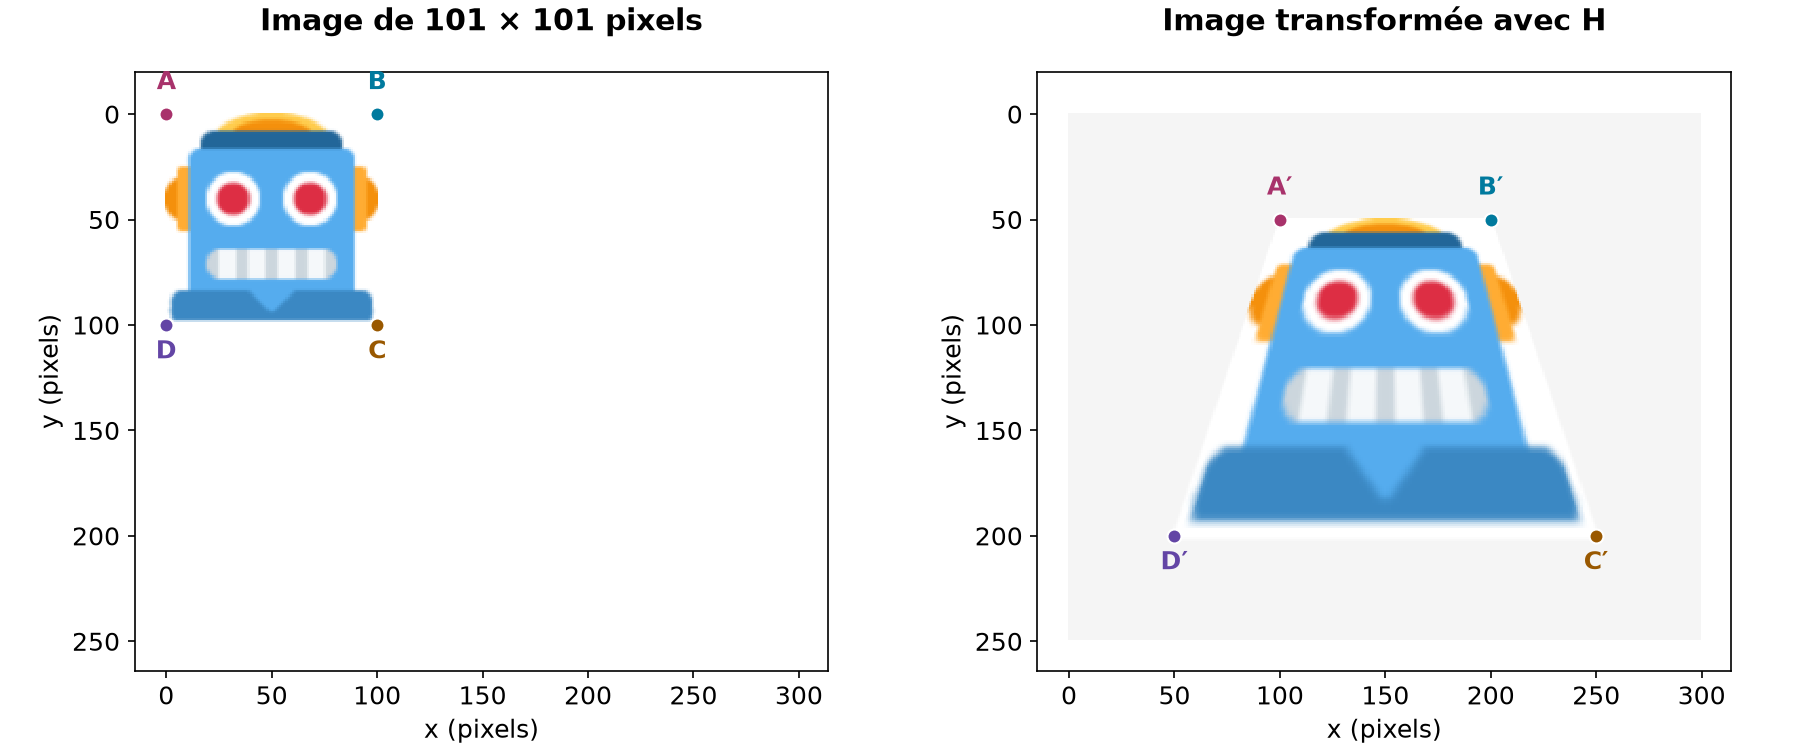

Le schéma utilise le robot proposé ; votre résultat utilisera l’image que vous
avez associée à l’ID 0.

Références : [homographie dans OpenCV](https://docs.opencv.org/4.13.0/d9/dab/tutorial_homography.html),
[transformations d’images](https://docs.opencv.org/4.13.0/da/d6e/tutorial_py_geometric_transformations.html).


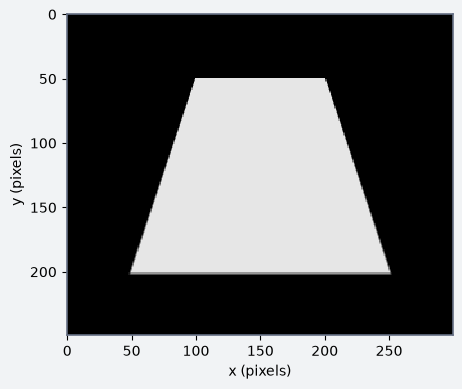

Coordonnées homogènes (u, v, w) : (np.float64(112.5), np.float64(75.0), np.float64(0.75))
Position de la cible avec H : [150. 100.]
Position obtenue par la moyenne des coins : [150. 125.]
Décalage de la moyenne par rapport à la cible (dx, dy) : [ 0. 25.]


In [29]:
# Reprendre l’image du joueur choisie à la question 4.
image_virtuelle_demo = cv2.resize(personnaliser_image_virtuelle(0), (101, 101),
                                 interpolation=cv2.INTER_AREA)
image_virtuelle_deformee = cv2.warpPerspective(image_virtuelle_demo, H, (300, 250))
afficher_image(image_virtuelle_deformee)

point = np.array([50.0, 50.0, 1.0])
u, v, w = H @ point
print('Coordonnées homogènes (u, v, w) :', (u, v, w))
centre_projete = np.array([u / w, v / w])
moyenne_coins = destination.mean(axis=0)
print('Position de la cible avec H :', centre_projete)
print('Position obtenue par la moyenne des coins :', moyenne_coins)
print('Décalage de la moyenne par rapport à la cible (dx, dy) :',
      moyenne_coins - centre_projete)


### Question 5

Réutilisez `image_virtuelle_demo`, qui contient votre image du joueur de la
question 4 redimensionnée à 101 × 101 pixels dans la cellule précédente.

À partir de copies de `destination`, construisez quatre tableaux de coordonnées
distincts :

1. `destination_decalee` : tous les coins sont déplacés de 40 pixels vers la droite.
2. `destination_rectangle` : les coins sont `(50, 50)`, `(250, 50)`,
   `(250, 200)` et `(50, 200)`.
3. `destination_trapeze` : les coins sont `(100, 50)`, `(200, 50)`,
   `(250, 200)` et `(50, 200)`.
4. `destination_permutee` : décalez cycliquement les coins du trapèze avec
   `np.roll(destination_trapeze, 1, axis=0)`.

Pour chaque tableau, calculez l’homographie et affichez l’image virtuelle déformée.
Conservez les quatre sorties avec les mêmes dimensions d’image.
Calculez aussi, pour le trapèze, la projection du point `(50, 50)`, la moyenne
des quatre coins et leur différence. Affichez ces valeurs numériques.

**Résultats attendus :** le premier rendu est décalé de 40 pixels, le deuxième
est rectangulaire, les deux derniers occupent le même trapèze avec des
orientations différentes. Pour le trapèze, le centre projeté est `(150, 100)`
et la moyenne des coins est `(150, 125)`.

<!-- visuel-attendu-fin -->

**Exemple visuel du résultat attendu**

Les quatre images ci-dessous ont le même cadre de **460 × 430 pixels**. L’exemple utilise le robot de la question 4 ; votre image doit subir les mêmes transformations.

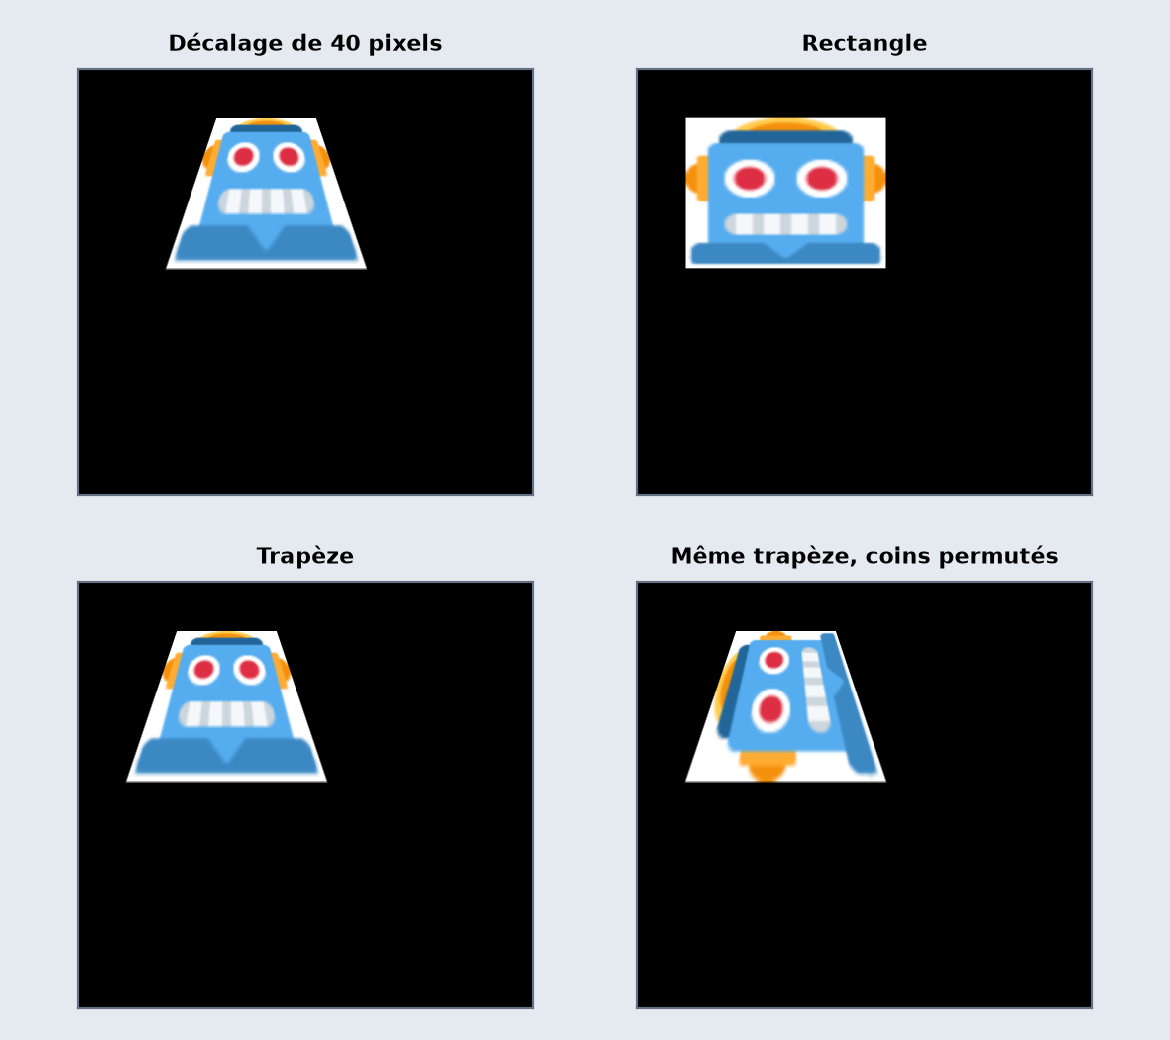


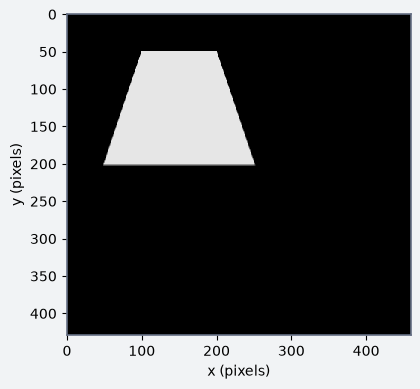

In [30]:
destination_essai = destination.copy()
# À COMPLÉTER : modifier ces coordonnées pour réaliser les essais demandés.
H_essai = cv2.getPerspectiveTransform(coins_source, destination_essai)
afficher_image(cv2.warpPerspective(image_virtuelle_demo, H_essai, (460, 430)))


### De l’homographie au maillage texturé

L’homographie nous a permis de placer une image sur un quadrilatère dans une
photo. Un moteur 3D comme Unity représente une surface par un **maillage**
(*mesh*) et peut utiliser cette image comme **texture**.

Un rectangle peut être construit avec quatre sommets et deux triangles.
Les sommets définissent les positions, tandis que les triangles indiquent quels
sommets relier. Les **coordonnées UV** associent à chaque sommet une position
dans la texture. Pour couvrir le rectangle avec l’image entière, on associe ses
coins aux quatre coins de la texture.

| Sommet | Position sur la surface `(x, y)` | Coordonnées `(u_texture, v_texture)` |
| --- | --- | --- |
| S0 | `(-1, -0.7)` | `(0, 0)` |
| S1 | `(1, -0.7)` | `(1, 0)` |
| S2 | `(1, 0.7)` | `(1, 1)` |
| S3 | `(-1, 0.7)` | `(0, 1)` |

Les triangles sont `(S0, S1, S2)` et `(S0, S2, S3)`. Ils partagent la diagonale
S0–S2. Dans Unity, ces sommets peuvent avoir une troisième coordonnée `z=0`
pour former une surface plane dans une scène 3D.

Nous reprenons l’image à quatre couleurs. Ici, les UV vont de 0 à 1, avec
`v_texture=0` au bas de la texture et `v_texture=1` en haut. Pour lire le tableau
NumPy, dont les lignes augmentent vers le bas, la correspondance est

$$
x_{\mathrm{pixel}}=u_{\mathrm{texture}}(\mathrm{largeur}-1),\qquad
y_{\mathrm{pixel}}=(1-v_{\mathrm{texture}})(\mathrm{hauteur}-1).
$$

Ces coordonnées de texture ont un autre rôle que les coordonnées homogènes
`(u, v, w)` utilisées plus haut. Les suffixes `_texture` permettent de les
distinguer dans cet exemple.


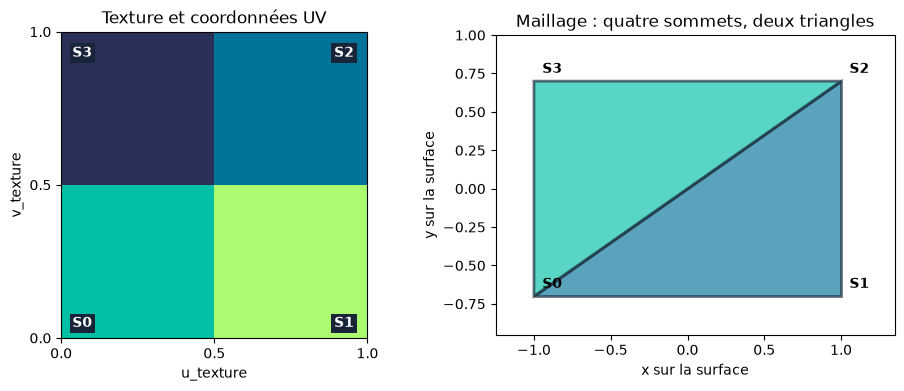

In [31]:
texture_maillage = image_demo.copy()
sommets_maillage = np.array([[-1, -0.7], [1, -0.7], [1, 0.7], [-1, 0.7]])
triangles_maillage = np.array([[0, 1, 2], [0, 2, 3]])
coordonnees_uv = np.array([[0, 0], [1, 0], [1, 1], [0, 1]], dtype=float)

figure, axes = plt.subplots(1, 2, figsize=(9, 3.8), layout='constrained')
axes[0].imshow(cv2.cvtColor(texture_maillage, cv2.COLOR_BGR2RGB),
               extent=(0, 1, 0, 1), origin='upper', interpolation='nearest')
axes[0].set_title('Texture et coordonnées UV')
axes[0].set_xlabel('u_texture')
axes[0].set_ylabel('v_texture')
axes[0].set_xticks([0, 0.5, 1])
axes[0].set_yticks([0, 0.5, 1])
for numero, (u_texture, v_texture) in enumerate(coordonnees_uv):
    axes[0].annotate(f'S{numero}', (u_texture, v_texture),
                     xytext=(8 if u_texture == 0 else -24,
                             8 if v_texture == 0 else -18),
                     textcoords='offset points', color='white', weight='bold',
                     bbox=dict(facecolor='#182538', edgecolor='none', pad=2))
for triangle, couleur in zip(triangles_maillage, ['#007398', '#00bfa6']):
    points_triangle = sommets_maillage[triangle]
    axes[1].fill(points_triangle[:, 0], points_triangle[:, 1],
                 facecolor=couleur, edgecolor='#182538', linewidth=2, alpha=0.65)
for numero, (x_sommet, y_sommet) in enumerate(sommets_maillage):
    axes[1].annotate(f'S{numero}', (x_sommet, y_sommet),
                     xytext=(6, 6), textcoords='offset points', weight='bold')
axes[1].set(xlim=(-1.25, 1.35), ylim=(-0.95, 1),
            xlabel='x sur la surface', ylabel='y sur la surface',
            title='Maillage : quatre sommets, deux triangles', aspect='equal')
plt.show()
plt.close(figure)


#### Afficher la texture sur les triangles

À l’intérieur d’un triangle, les coordonnées UV sont interpolées à partir de
celles de ses trois sommets. Elles indiquent quelle couleur lire dans la texture.
La fonction fournie ci-dessous réalise cette opération avec NumPy, Matplotlib
et `cv2.remap`, qui lit une image aux coordonnées demandées.

Cette démonstration montre la surface de face, avec une projection orthographique
et une interpolation affine dans chaque triangle. Elle isole le rôle des UV.
Pour un rendu 3D en perspective, le moteur doit aussi corriger l’interpolation
en fonction de la profondeur des sommets.


In [32]:
import matplotlib.tri as triangulation


def rendre_maillage(texture, sommets, triangles, uv):
    # Le cadre reste identique pour comparer les changements de géométrie.
    grille_x, grille_y = np.meshgrid(np.linspace(-1.4, 1.4, 420),
                                     np.linspace(1, -1, 300))
    maillage = triangulation.Triangulation(sommets[:, 0], sommets[:, 1], triangles)
    u_texture = triangulation.LinearTriInterpolator(maillage, uv[:, 0])(grille_x, grille_y)
    v_texture = triangulation.LinearTriInterpolator(maillage, uv[:, 1])(grille_x, grille_y)
    zone = ~np.ma.getmaskarray(u_texture)
    hauteur_texture, largeur_texture = texture.shape[:2]
    carte_x = (u_texture.filled(0) * (largeur_texture - 1)).astype(np.float32)
    carte_y = ((1 - v_texture.filled(0)) * (hauteur_texture - 1)).astype(np.float32)
    image_texturee = cv2.remap(texture, carte_x, carte_y, cv2.INTER_NEAREST,
                               borderMode=cv2.BORDER_REPLICATE)
    rendu = np.full((300, 420, 3), (240, 234, 229), dtype=np.uint8)
    rendu[zone] = image_texturee[zone]
    return rendu


#### Modifier les UV ou déplacer un sommet

La cellule suivante produit quatre rendus avec le même cadre.

1. **Image entière** : les UV couvrent la texture de 0 à 1.
2. **Texture retournée** : remplacer `u_texture` par `1 - u_texture` échange
   la gauche et la droite de l’image, sans déplacer les sommets.
3. **Moitié gauche étirée** : multiplier `u_texture` par `0.5` sélectionne la
   moitié gauche de la texture et l’étire sur toute la surface. Seules les
   couleurs bleu sombre et turquoise restent visibles.
4. **Sommet déplacé** : déplacer S2 modifie le contour de la surface, tandis
   que les UV associés aux sommets restent les mêmes. La diagonale montre
   les deux triangles utilisés pour le rendu.

Modifiez les valeurs des copies `uv_retournes`, `uv_recadres` ou
`sommets_deformes`, puis réexécutez la cellule pour observer leur effet.


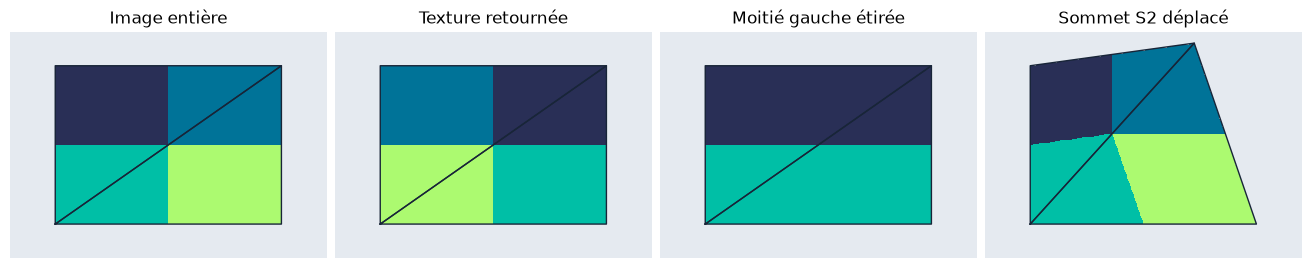

In [33]:
uv_retournes = coordonnees_uv.copy()
uv_retournes[:, 0] = 1 - uv_retournes[:, 0]
uv_recadres = coordonnees_uv.copy()
uv_recadres[:, 0] *= 0.5
sommets_deformes = sommets_maillage.copy()
sommets_deformes[2] = (0.45, 0.9)

variantes_maillage = [
    ('Image entière', sommets_maillage, coordonnees_uv),
    ('Texture retournée', sommets_maillage, uv_retournes),
    ('Moitié gauche étirée', sommets_maillage, uv_recadres),
    ('Sommet S2 déplacé', sommets_deformes, coordonnees_uv),
]
figure, axes = plt.subplots(1, 4, figsize=(13, 3.4), layout='constrained')
for axe, (titre, sommets, uv) in zip(axes, variantes_maillage):
    rendu_maillage = rendre_maillage(texture_maillage, sommets, triangles_maillage, uv)
    axe.imshow(cv2.cvtColor(rendu_maillage, cv2.COLOR_BGR2RGB),
               extent=(-1.4, 1.4, -1, 1), origin='upper', interpolation='nearest')
    for triangle in triangles_maillage:
        contour = sommets[np.append(triangle, triangle[0])]
        axe.plot(contour[:, 0], contour[:, 1], color='#182538', linewidth=1)
    axe.set(title=titre, xlim=(-1.4, 1.4), ylim=(-1, 1), aspect='equal')
    axe.set_axis_off()
plt.show()
plt.close(figure)


#### Le lien avec l’homographie et Unity AR

Une surface plane texturée, projetée par une caméra en perspective, peut produire
la même transformation géométrique que notre homographie. Les calculs sont
organisés différemment. OpenCV utilise ici directement une matrice entre les
coordonnées de deux images. Un moteur 3D projette la géométrie puis interpole
les UV avec correction de perspective. Découper simplement un quadrilatère 2D
en deux triangles et interpoler les UV de façon affine, comme dans la démonstration,
ne reproduit pas en général une homographie.

Dans Unity, un `Mesh` peut contenir les positions des sommets, les indices des
triangles et les coordonnées UV. Un matériau détermine comment utiliser la
texture pour afficher la surface. Les UV contrôlent donc l’apparence du contenu.
AR Foundation fournit, par l’intermédiaire d’ARCore ou d’ARKit notamment, le suivi
du téléphone et des repères réels tels que des plans ou des images. Ces données
permettent de positionner le contenu virtuel par rapport au monde réel, puis Unity
en effectue le rendu sur la vue de la caméra.

Le maillage de notre objet virtuel est distinct de la reconstruction d’un maillage
de l’environnement réel. Cette dernière est une fonctionnalité AR supplémentaire,
disponible selon l’appareil, et n’est pas nécessaire pour afficher notre rectangle.

Références : [créer un rectangle texturé dans Unity](https://docs.unity3d.com/Manual/Example-CreatingaBillboardPlane.html)
et [fonctionnalités d’AR Foundation](https://docs.unity3d.com/Packages/com.unity.xr.arfoundation@6.0/manual/index.html).


## 6. Superposer sans effacer la photo

L’image virtuelle déformée occupe un quadrilatère dans une image de la taille de la photo.
Les pixels à l’extérieur valent généralement zéro. Recopier toute cette image
recouvrirait donc aussi le fond de la photo.

Un **masque** indique les pixels à modifier : il vaut 255 à l’intérieur de l’image virtuelle et 0 à l’extérieur. On applique au masque la même transformation qu’à l’image virtuelle.
Avec `masque > 0`, NumPy sélectionne uniquement la zone à remplacer.

Le masque doit dépendre de la géométrie, pas de la couleur du dessin : du noir
peut faire partie de l’image virtuelle et doit rester visible.

La fonction `superposer_image` fournie réalise une superposition opaque.
`augmenter_image` applique cette opération à chaque marqueur détecté. Suivez dans le
code les rôles de `source`, `transformation`, `image_deformee`, `masque` et `resultat`.


In [34]:
def superposer_image(image, surface, coins):
    hauteur, largeur = surface.shape[:2]
    source = np.float32([[0, 0], [largeur - 1, 0], [largeur - 1, hauteur - 1], [0, hauteur - 1]])
    transformation = cv2.getPerspectiveTransform(source, np.float32(coins))
    dimensions_sortie = (image.shape[1], image.shape[0])
    image_deformee = cv2.warpPerspective(surface, transformation, dimensions_sortie)
    masque = cv2.warpPerspective(np.full((hauteur, largeur), 255, np.uint8), transformation,
                               dimensions_sortie, flags=cv2.INTER_NEAREST)
    resultat = image.copy()
    resultat[masque > 0] = image_deformee[masque > 0]
    return resultat

def augmenter_image(image, detecteur):
    detections = detecter_marqueurs(image, detecteur)
    resultat = image.copy()
    for detection in detections:
        surface = creer_image_virtuelle(identifiant=detection['identifiant'])
        resultat = superposer_image(resultat, surface, detection['coins'])
    return resultat, detections


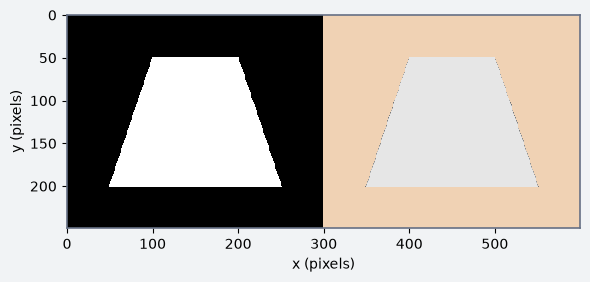

In [35]:
# Un exemple de masque, indépendant de la capture.
fond = np.full((250, 300, 3), (180, 210, 240), dtype=np.uint8)
masque = cv2.warpPerspective(np.full(image_virtuelle_demo.shape[:2], 255, np.uint8), H,
                             (300, 250), flags=cv2.INTER_NEAREST)
afficher_image(np.hstack([cv2.cvtColor(masque, cv2.COLOR_GRAY2BGR),
                   superposer_image(fond, image_virtuelle_demo, destination)]))


### Question 6

Complétez `melanger` pour mélanger le fond et l’image virtuelle **uniquement dans le masque** :

`pixel_final = alpha * pixel_virtuel + (1 - alpha) * pixel_fond`

`alpha=0` conserve le fond ; `alpha=1` affiche l’image virtuelle opaque. Essayez aussi
`alpha=0.5`. Utilisez le tableau booléen `zone` et convertissez les valeurs
calculées en `np.uint8` avant de les affecter au résultat.

**Critères de réussite :** à l’extérieur du masque, tous les pixels restent
identiques au fond ; les cas `alpha=0` et `alpha=1` donnent les résultats prévus ;
un pixel noir situé dans l’image virtuelle est bien mélangé.

Affichez côte à côte les trois résultats pour `alpha=0`, `0.5` et `1`.
Ajoutez un essai avec une image virtuelle entièrement noire et un masque non vide.
Pour `alpha=1`, les pixels à l’intérieur de ce masque doivent devenir noirs
et ceux de l’extérieur doivent rester identiques au fond.

<!-- visuel-attendu-fin -->

**Exemple visuel du résultat attendu**

Le fond reste identique hors du trapèze. Le dernier panneau vérifie que les pixels noirs de l’image virtuelle recouvrent aussi le fond lorsque `alpha=1`.

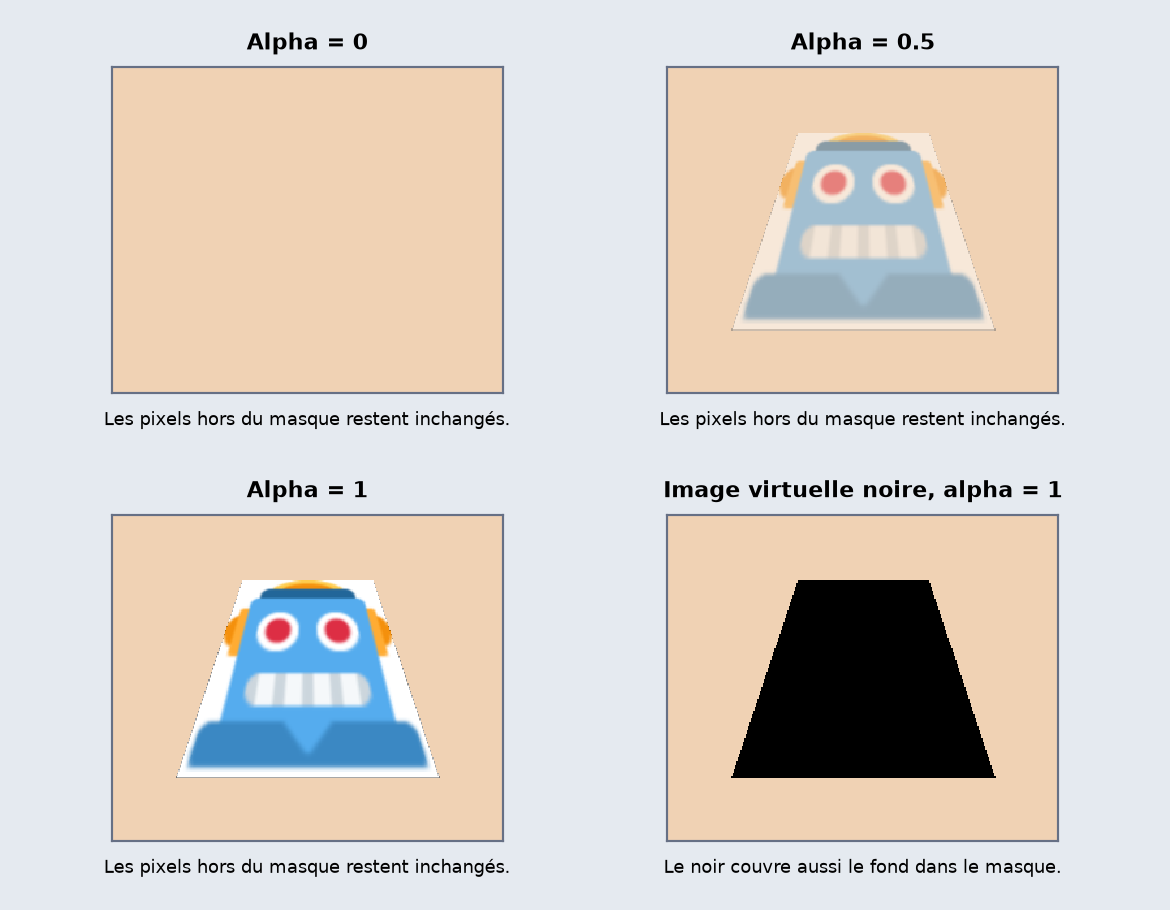


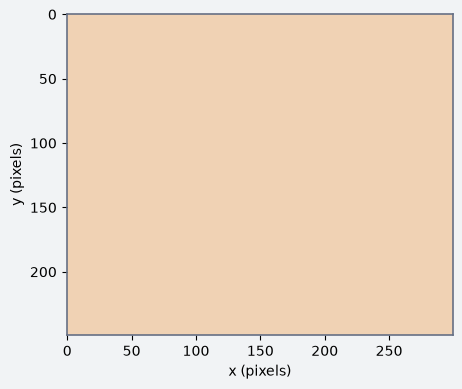

In [36]:
def melanger(fond, image_virtuelle_deformee, masque, alpha):
    if not 0 <= alpha <= 1:
        raise ValueError('alpha doit être compris entre 0 et 1.')
    resultat = fond.copy()
    zone = masque > 0
    # À COMPLÉTER : calculer et affecter le mélange dans resultat[zone].
    return resultat

afficher_image(melanger(fond, image_virtuelle_deformee, masque, 0.5))
# Tant que le À COMPLÉTER n’est pas complété, seul le fond apparaît.


## 7. Passer aux photos : tester votre traitement

Jusqu’ici, vous avez manipulé des images construites pour comprendre chaque étape.
Vous allez maintenant appliquer le traitement à une photo de marqueurs physiques.

Une **page web de capture** accompagne ce notebook. Elle permet de prendre une
photo avec la caméra ou d’en importer une, puis d’afficher le résultat du traitement
Python.

### Connecter la page à votre notebook

1. Exécutez les cellules précédentes qui définissent `detecteur` et `augmenter_image`.
2. Exécutez ci-dessous la cellule qui charge `connexion_ra`, puis celle qui appelle
   `connexion_ra.connecter(...)`. **Cette deuxième cellule démarre la connexion.**
3. Ouvrez la page avec le lien ou le bouton affiché par cette cellule.
4. Cliquez sur **Traiter l’exemple**. Six marqueurs doivent être détectés et remplacés
   par les images virtuelles du rendu fourni.
5. Revenez au notebook et exécutez la cellule de lecture du résultat : elle affiche
   les dimensions de l’image, les IDs détectés et l’image augmentée.

La cellule de connexion affiche un lien vers le site publié sur Netlify, déjà relié
à votre notebook. Cliquez sur « Ouvrir le site connecté au notebook » dans la sortie
de la cellule. Utilisez toujours ce lien pour établir la connexion.
Le notebook Colab doit rester ouvert et son noyau actif pendant les essais.

Le trajet d’une photo est : **page de capture → `traiter(image)` dans le notebook
→ résultat sur la page et dans le notebook**. `connexion_ra.derniere_image` conserve
la photo reçue, `dernieres_detections` ses marqueurs et `dernier_resultat` l’image augmentée.
La page `telephone.html`, utilisée plus loin pour le traitement en direct sur téléphone,
fonctionne séparément et ne transmet pas ses captures au notebook.

Une fois l’exemple traité, téléchargez la planche de marqueurs, imprimez-la ou affichez-la
sur un autre écran, puis photographiez-la en gardant les marges blanches visibles.
Importez cette photo sur la page et cliquez sur **Traiter la capture**. Vous pouvez aussi
utiliser la caméra de l’appareil sur lequel la page connectée est ouverte.

**Capture** et **Résultat augmenté** permettent de comparer la même prise de vue.
Gardez le notebook ouvert. Après une modification de fonction, réexécutez sa
cellule et la cellule de connexion, puis ouvrez le lien et traitez une nouvelle image.

`traiter(image)` est le point d’entrée : elle reçoit une image et doit renvoyer
`(image_resultat, detections)`. Pour commencer, elle utilise le rendu fourni.


Le module fourni `connexion_ra` reçoit la photo envoyée par la page de capture,
la convertit en tableau NumPy et appelle `traiter(image)`. Il renvoie ensuite
l’image traitée et les marqueurs détectés à cette page pour les afficher.

Exécutez la cellule suivante pour charger ce module et le script qui échange
les images avec la page de capture.


In [37]:
import importlib
import importlib.util
from pathlib import Path
from urllib.request import urlopen

if (importlib.util.find_spec('connexion_ra') is None
        or importlib.util.find_spec('export_mobile') is None
        or importlib.util.find_spec('export_reponses') is None):
    adresse = 'https://laboratoire-sciences-code.netlify.app/apps/realite-augmentee/ressources/'
    ressources = {}
    for nom in ('connexion_ra.py', 'connexion_navigateur.js', 'export_mobile.py', 'export_reponses.py'):
        with urlopen(adresse + nom, timeout=30) as reponse:
            ressources[nom] = reponse.read()
    for nom, contenu in ressources.items():
        Path(nom).write_bytes(contenu)
    importlib.invalidate_caches()

import connexion_ra
importlib.reload(connexion_ra)
print('Module de connexion chargé.')


Module de connexion chargé.


In [38]:
def traiter(image):
    # Modifiez cette fonction pour changer le traitement de vos images.
    return augmenter_image(image, detecteur)

connexion_ra.connecter(url_site='https://laboratoire-sciences-code.netlify.app/apps/realite-augmentee/', traitement=traiter);


Après avoir cliqué sur **Traiter l’exemple** ou **Traiter la capture** sur la page connectée,
exécutez la cellule ci-dessous. Importer une photo sans cliquer sur le bouton de traitement
ne l’envoie pas encore au notebook. Comparez ses dimensions et ses IDs aux résultats du site.
Les coordonnées concernent l’image traitée, dont la taille peut être réduite
par rapport à la photo originale du téléphone.


In [39]:
image = connexion_ra.derniere_image
if image is None:
    print('Ouvrez le lien de la cellule de connexion, puis cliquez sur Traiter l’exemple ou Traiter la capture. Réexécutez ensuite cette cellule.')
else:
    print('Dimensions (hauteur, largeur, canaux) :', image.shape)
    print('Identifiants :', [d['identifiant'] for d in connexion_ra.dernieres_detections])
    afficher_image(connexion_ra.dernier_resultat)


Ouvrez le lien de la cellule de connexion, puis cliquez sur Traiter l’exemple ou Traiter la capture. Réexécutez ensuite cette cellule.


### Question 7

Complétez `augmenter_ma_scene` ci-dessous, puis remplacez l’appel à `augmenter_image`
dans `traiter` par `augmenter_ma_scene(image, detecteur)`.

Votre programme doit :

1. Détecter les marqueurs sur la capture originale, avant tout dessin.
2. Pour les IDs 0 et 1, créer l’image virtuelle correspondante avec `personnaliser_image_virtuelle` et la
   superposer aux quatre coins avec `superposer_image`.
3. Pour les autres IDs, afficher seulement les annotations de la question 3.
4. Retourner l’image inchangée lorsqu’aucun marqueur n’est détecté.
5. Conserver la capture originale intacte.

**Extension facultative :** remplacez la superposition opaque par votre mélange
transparent. Vous devrez construire l’image virtuelle déformée et son masque à la taille
de la capture avant d’appeler `melanger`.

**Pour vérifier :** sur l’exemple, seuls les marqueurs 0 et 1 portent vos images virtuelles ;
les quatre autres sont annotés. Sur vos photos, les images virtuelles suivent l’orientation
et la perspective. Prenez aussi une photo sans marqueur.

<!-- visuel-attendu-fin -->

**Exemple visuel du résultat attendu**

Sur cette **scène synthétique**, le robot couvre l’ID 0 et le diamant couvre l’ID 1. Les IDs 2 à 5 gardent leurs motifs avec le contour vert, le centre rouge et leur identifiant. L’entrée sans marqueur reste inchangée.

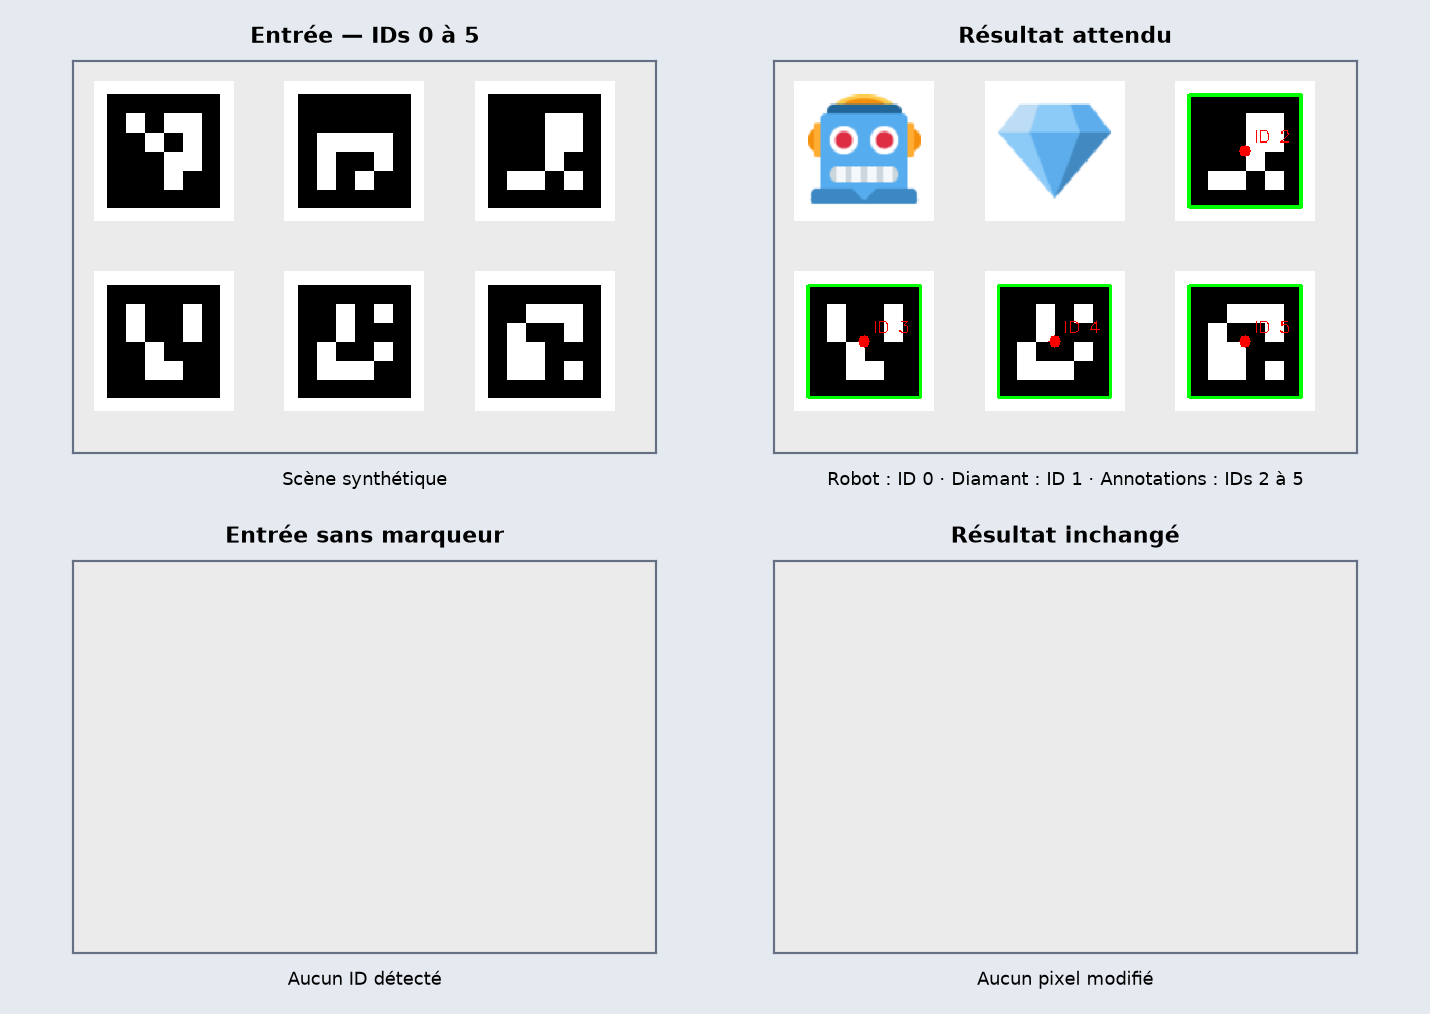


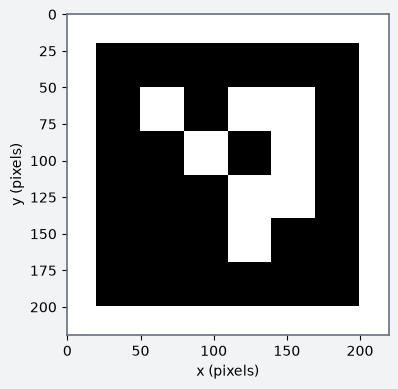

In [40]:
def augmenter_ma_scene(image, detecteur):
    detections = detecter_marqueurs(image, detecteur)
    resultat = image.copy()
    # À COMPLÉTER : parcourir les détections et choisir le rendu selon l’ID.
    return resultat, detections

# Essai rapide avant de relier cette fonction à traiter :
afficher_image(augmenter_ma_scene(image_test, detecteur)[0])


### Question 8

Constituez une série de six photos : marqueur de face, tourné de 90°, incliné,
plus éloigné, partiellement caché et absent. Prenez au moins une photo vous-même.
Importez les fichiers dans le dossier du notebook et renseignez leurs chemins
dans la cellule suivante.

Complétez la boucle pour charger chaque photo avec `cv2.imread`, appeler
`augmenter_ma_scene(image, detecteur)` et conserver les résultats dans
`resultats_photos`. Pour chaque photo, enregistrez son nom, les identifiants
détectés, leurs coins et le nombre de pixels modifiés par l’augmentation.
Un pixel est modifié si au moins un de ses trois canaux a changé.

Affichez la photo et son résultat côte à côte avec `np.hstack`.
Affichez ensuite les résultats numériques collectés. Si `cv2.imread` renvoie
`None`, signalez le fichier introuvable au lieu de le transmettre au traitement.

**Pour vérifier :** une photo sans marqueur donne une liste vide et zéro pixel
modifié. Pour une détection réussie, l’image virtuelle suit les coins détectés.
La photo partiellement cachée peut produire une liste vide.

<!-- visuel-attendu-fin -->

**Exemple visuel du résultat attendu**

**Exemple sur des images synthétiques, à comparer à vos propres photos.** Dans chaque panneau, l’entrée est à gauche et le résultat à droite. Les IDs et les nombres de pixels affichés ont été calculés sur ces images ; vos valeurs dépendront de vos photos et de votre image virtuelle. Ici, l’occultation empêche la détection ; une occultation plus légère peut encore permettre une détection.

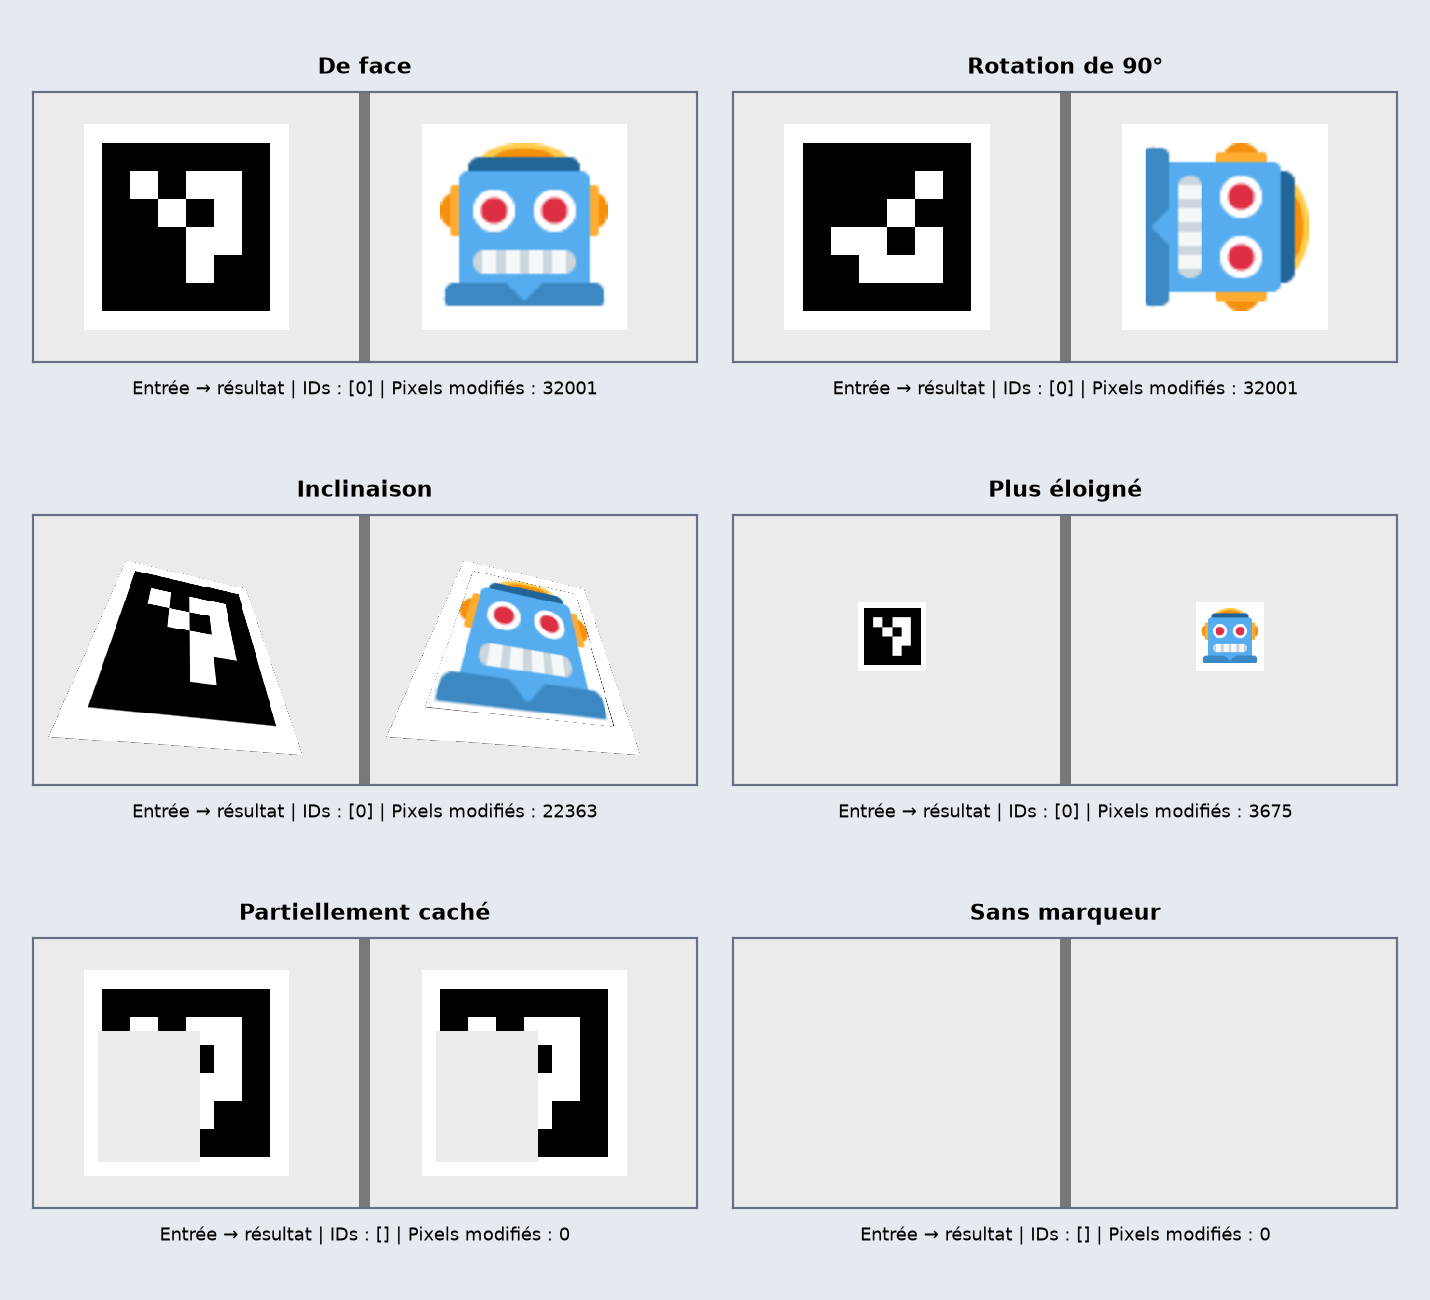


In [41]:
fichiers_essais = {
    'face': None,
    'rotation': None,
    'inclinaison': None,
    'eloignement': None,
    'occultation': None,
    'sans_marqueur': None,
}
# À COMPLÉTER : remplacer None par les chemins de vos photos.
resultats_photos = []
for nom, chemin in fichiers_essais.items():
    if chemin is None:
        continue
    # À COMPLÉTER : charger, traiter, collecter les mesures et afficher les images.
print(resultats_photos)


[]


## 8. Faire fonctionner la réalité augmentée sur votre téléphone

Une vidéo est une succession d’images. Pour chaque nouvelle image de la caméra,
le téléphone détecte les marqueurs, calcule les homographies et superpose les
images virtuelles. Le résultat se renouvelle sans appuyer sur un bouton de capture.

Vous allez transférer les images produites par `personnaliser_image_virtuelle`
sur votre téléphone. Un traitement fourni utilise OpenCV.js, la version d’OpenCV
pour le navigateur, avec le même dictionnaire ArUco et une superposition opaque.
L’export contient vos images. Il ne convertit pas vos fonctions Python en JavaScript
et ne reprend pas automatiquement vos annotations ou votre mélange transparent.


### Exporter vos images virtuelles

Exécutez la cellule ci-dessous après avoir personnalisé les apparences des
marqueurs. Téléchargez `images-virtuelles.json`, puis transférez ce fichier sur
votre téléphone. Après une modification des images, refaites l’export.


In [42]:
import export_mobile

images_a_exporter = {
    identifiant: personnaliser_image_virtuelle(identifiant)
    for identifiant in range(6)
}
export_mobile.telecharger_images(images_a_exporter);


c:\Users\kyler\OneDrive\Documents\ChatGPT\New project\images-virtuelles.json

### Démarrer sur le téléphone

1. Ouvrez le [site du laboratoire](https://laboratoire-sciences-code.netlify.app/apps/realite-augmentee/telephone.html)
   dans le navigateur du téléphone. Autorisez l’accès à la caméra lorsque le navigateur le demande.
2. Pour utiliser votre travail, appuyez sur **Importer JSON**
   et sélectionnez `images-virtuelles.json`. Ce fichier contient vos images et leur
   association aux IDs. Vérifiez que son nom s’affiche. Pour un premier essai,
   les six images d’exemple sont déjà chargées ; aucun import n’est nécessaire.
3. Appuyez sur **Démarrer la caméra** et autorisez son utilisation. Présentez un
   marqueur imprimé ou affiché sur un autre écran, avec sa marge blanche visible.
4. Déplacez le marqueur et vérifiez que votre image suit sa perspective.
   La reconnaissance et le dessin sont calculés sur le téléphone, sans envoyer
   les images de la caméra au notebook.

**Arrêter** libère la caméra. Si vous changez d’application, le traitement s’arrête.
Revenez à la page et appuyez de nouveau sur **Démarrer la caméra**.


### Mesurer la fluidité

La **cadence** indique le nombre d’images traitées et affichées par seconde.
À 10 images par seconde, un nouveau résultat apparaît en moyenne toutes les
100 ms. À 20 images par seconde, cet intervalle est de 50 ms.

Le **calcul par image** mesure la durée de détection, de superposition et de rendu.
La cadence dépend aussi de la caméra et de la disponibilité du navigateur.
Le temps de calcul seul ne suffit donc pas à la prédire exactement.

Le réglage de résolution limite le plus grand côté de l’image traitée.
Passer de 640 à 960 pixels multiplie le nombre de pixels par environ
`(960 / 640)² = 2,25`, si la caméra fournit cette définition.
Vous allez mesurer l’effet sur la cadence et sur la détection d’un petit marqueur.


### Question 9

**À remettre : la cellule ci-dessous remplie avec vos observations sur téléphone.**
Vous n’avez pas de fonction à programmer ni de texte à rédiger.

1. Sur le téléphone, importez votre fichier avec **Importer JSON**, puis démarrez
   la caméra. Présentez les marqueurs 0 et 1 : dans `dessins_personnalises_visibles`,
   remplacez chaque `None` par `True` si la bonne image personnalisée apparaît,
   ou par `False` sinon.
2. Choisissez **640 pixels** sur le site. Faites les trois essais du tableau,
   puis remplissez le bloc `mesures_640` dans le notebook.
3. Choisissez **960 pixels** et recommencez dans les mêmes conditions
   (même marqueur, éclairage et distance de départ). Remplissez `mesures_960`.
4. Exécutez la cellule pour afficher vos deux séries de réponses.

| Essai sur le téléphone | Valeurs à saisir dans le bloc de la résolution testée |
| :--- | :--- |
| Pendant 15 secondes, déplacez et inclinez le marqueur en le gardant entièrement visible. | Dans « Images affichées par seconde », notez la plus petite et la plus grande valeur observées : `cadence_min_ips` et `cadence_max_ips`. Dans « Calcul par image », notez la plus grande valeur observée : `calcul_max_ms`. Comptez les pertes de l’image virtuelle : `disparitions_sur_15_s`. |
| Sortez le marqueur du champ, puis ramenez-le. | `disparait_hors_champ` vaut `True` si l’image virtuelle disparaît. `reapparait_au_retour` vaut `True` si elle revient. Sinon, mettez `False` pour le comportement qui échoue. |
| Placez le marqueur environ deux fois plus loin qu’au départ et observez-le pendant 15 secondes. | Comptez les pertes de l’image virtuelle : `disparitions_distance_double_sur_15_s`. |

Une disparition correspond à un passage de l’image virtuelle visible à absente
alors que le marqueur reste dans le champ. Ne comptez pas chaque frame absente.
Vous pouvez enregistrer l’écran du téléphone pour relire les valeurs après l’essai.
Les minimums et maximums demandés sont ceux **observés à l’écran**.

**Comment remplir la cellule**

Remplacez uniquement les `None`. Écrivez les nombres sans unité et utilisez un point
pour les décimales (`32.5`). Écrivez `True` ou `False` sans guillemets.
Pour un comptage, `0` signifie « aucune disparition » ; `None` signifie « pas encore mesuré ».
Gardez les noms des champs et les lignes qui regroupent les deux blocs.

**Exemple fictif de saisie pour 640 pixels, uniquement pour montrer le format**

Si vous observez une cadence entre 18 et 24 images/s, un calcul maximal de 32.5 ms,
une perte à la distance de départ et trois pertes plus loin, avec une disparition
hors champ et un retour corrects, le bloc rempli serait :

```python
mesures_640 = {
    'resolution': 640,
    'cadence_min_ips': 18,
    'cadence_max_ips': 24,
    'calcul_max_ms': 32.5,
    'disparitions_sur_15_s': 1,
    'disparait_hors_champ': True,
    'reapparait_au_retour': True,
    'disparitions_distance_double_sur_15_s': 3,
}
```

Ces valeurs ne sont pas un résultat attendu : saisissez vos propres mesures
dans chacun des deux blocs ci-dessous.

<!-- visuel-attendu-fin -->

**Exemple visuel du résultat attendu**

**Illustration sur des scènes synthétiques, pas une capture du téléphone.** L’image virtuelle doit suivre le marqueur reconnu, disparaître lorsqu’il sort du champ et réapparaître à son retour. Le dernier panneau montre un petit marqueur encore reconnu ; lors de vos essais, l’éloignement peut entraîner des pertes de détection. Les cadences, durées et nombres de disparitions doivent être mesurés sur votre téléphone pour les résolutions 640 et 960 : il n’existe pas de valeurs numériques attendues universelles.

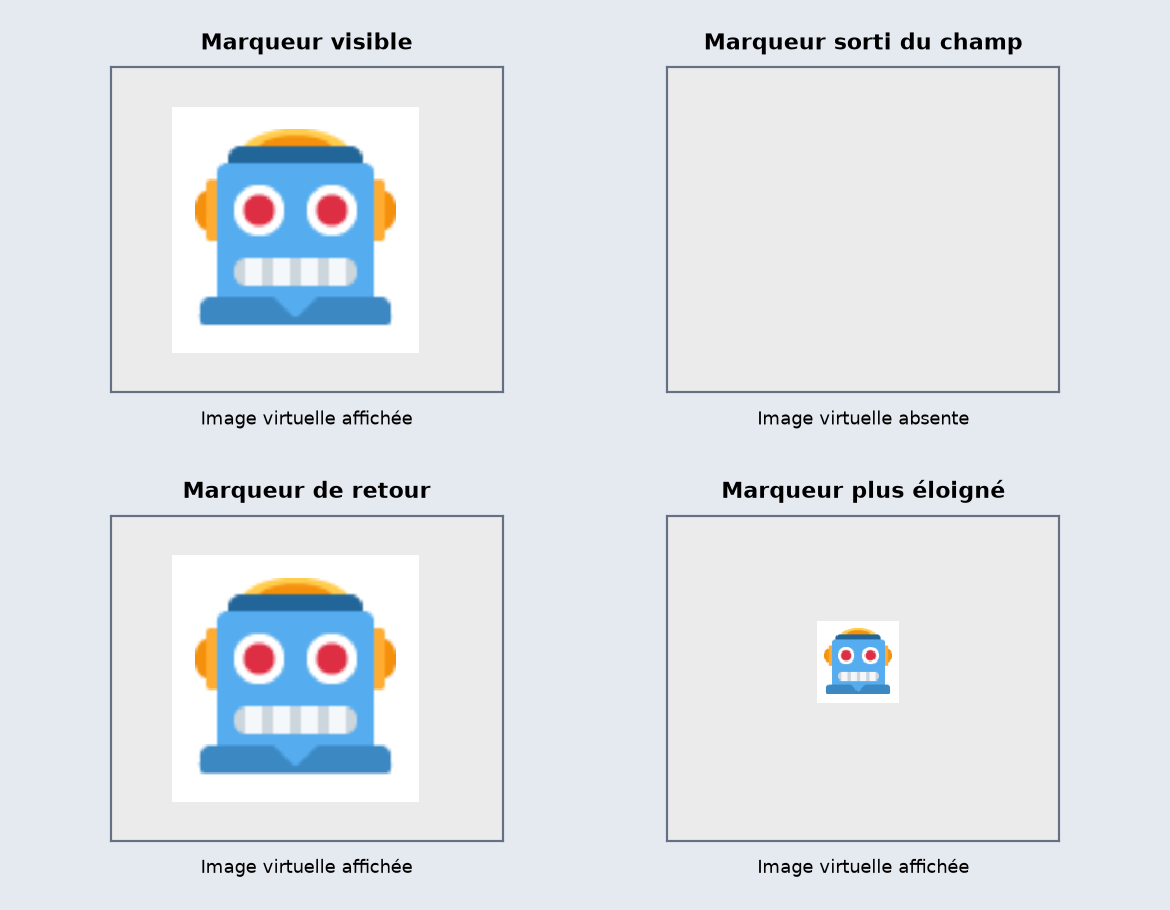


In [43]:
# La bonne image personnalisée apparaît-elle pour chaque marqueur ?
dessins_personnalises_visibles = {
    0: None,  # True si l’image prévue pour l’ID 0 apparaît, sinon False.
    1: None,  # True si l’image prévue pour l’ID 1 apparaît, sinon False.
}

# Essais avec le réglage 640 pixels sur le téléphone.
mesures_640 = {
    'resolution': 640,
    'cadence_min_ips': None,  # Plus petite cadence affichée, en images/s.
    'cadence_max_ips': None,  # Plus grande cadence affichée, en images/s.
    'calcul_max_ms': None,  # Plus grand temps de calcul affiché, en ms.
    'disparitions_sur_15_s': None,  # Nombre entier ; 0 si aucune perte.
    'disparait_hors_champ': None,  # True si elle disparaît, sinon False.
    'reapparait_au_retour': None,  # True si elle revient, sinon False.
    'disparitions_distance_double_sur_15_s': None,  # Nombre de pertes plus loin.
}

# Refaire les mêmes essais avec le réglage 960 pixels.
mesures_960 = {
    'resolution': 960,
    'cadence_min_ips': None,  # Plus petite cadence affichée, en images/s.
    'cadence_max_ips': None,  # Plus grande cadence affichée, en images/s.
    'calcul_max_ms': None,  # Plus grand temps de calcul affiché, en ms.
    'disparitions_sur_15_s': None,  # Nombre entier ; 0 si aucune perte.
    'disparait_hors_champ': None,  # True si elle disparaît, sinon False.
    'reapparait_au_retour': None,  # True si elle revient, sinon False.
    'disparitions_distance_double_sur_15_s': None,  # Nombre de pertes plus loin.
}

# À COMPLÉTER : saisir les mesures et les booléens après vos essais sur téléphone.
# Ces lignes regroupent et affichent les réponses : les conserver telles quelles.
mesures_telephone = [mesures_640, mesures_960]
print(dessins_personnalises_visibles)
for mesure_telephone in mesures_telephone:
    print(mesure_telephone)


{0: None, 1: None}
{'resolution': 640, 'cadence_min_ips': None, 'cadence_max_ips': None, 'calcul_max_ms': None, 'disparitions_sur_15_s': None, 'disparait_hors_champ': None, 'reapparait_au_retour': None, 'disparitions_distance_double_sur_15_s': None}
{'resolution': 960, 'cadence_min_ips': None, 'cadence_max_ips': None, 'calcul_max_ms': None, 'disparitions_sur_15_s': None, 'disparait_hors_champ': None, 'reapparait_au_retour': None, 'disparitions_distance_double_sur_15_s': None}


## 9. Une interaction entre deux marqueurs

Nous allons faire changer l’apparence d’une image virtuelle selon la distance
entre les marqueurs 0 et 1 dans la photo.

La fonction fournie ci-dessous calcule les centres par moyenne des coins puis
leur distance euclidienne : `np.linalg.norm(centre_b - centre_a)`.
Elle divise cette distance par la longueur moyenne des quatre côtés du marqueur 0.
Le rapport s’exprime donc en **côtés apparents de marqueur**.

Exemple : une distance de 200 pixels pour un côté de 100 pixels donne le rapport 2.
Si toutes les longueurs dans l’image sont divisées par deux, ce rapport reste 2.
La mesure est ainsi indépendante d’un changement uniforme d’échelle de l’image.

Ce n’est pas une distance physique en centimètres. La perspective et des profondeurs
différentes peuvent modifier le rapport. Pour expérimenter, placez deux marqueurs
de même taille dans le même plan, vus approximativement de face.

La fonction renvoie `None` si un ID manque ou apparaît plusieurs fois : dans
ce cas, la mesure n’est pas définie sans une règle de sélection supplémentaire.


In [44]:
def mesurer_proximite(detections, id_a=0, id_b=1):
    if id_a == id_b:
        raise ValueError('Choisissez deux identifiants différents.')
    groupes = [[d for d in detections if d['identifiant'] == identifiant]
               for identifiant in (id_a, id_b)]
    if any(len(groupe) != 1 for groupe in groupes):
        return None
    coins = [np.asarray(groupe[0]['coins'], dtype=float) for groupe in groupes]
    if any(c.shape != (4, 2) or not np.isfinite(c).all() for c in coins):
        return None
    centre_a, centre_b = [c.mean(axis=0) for c in coins]
    cotes = np.linalg.norm(np.roll(coins[0], -1, axis=0) - coins[0], axis=1)
    if np.any(cotes <= 1e-6):
        return None
    distance_px = float(np.linalg.norm(centre_b - centre_a))
    return {'distance_px': distance_px,
            'distance_relative': distance_px / float(cotes.mean()),
            'centre_a': centre_a, 'centre_b': centre_b}

mesure = mesurer_proximite(connexion_ra.dernieres_detections)
if mesure is None:
    print('Traitez une image contenant exactement un marqueur ID 0 et un marqueur ID 1.')
else:
    print(f"Distance : {mesure['distance_px']:.1f} px ; {mesure['distance_relative']:.2f} côtés de marqueur.")


Traitez une image contenant exactement un marqueur ID 0 et un marqueur ID 1.


### Question 10

1. Complétez `sont_proches` pour renvoyer `True` si une mesure existe et si
   `distance_relative` est inférieure ou égale à `seuil`, sinon `False`.
2. Utilisez ce résultat dans `augmenter_ma_scene` pour changer la couleur de
   l’image virtuelle associée à l’ID 0 lorsque les marqueurs 0 et 1 sont proches.
3. Sans déplacer les deux marqueurs, prenez deux photos à des distances
   différentes. Calculez pour chacune la distance en pixels et le rapport
   normalisé avec `mesurer_proximite`. Affichez les valeurs obtenues.
4. Dans la dernière cellule de cette question, programmez des essais pour une
   liste vide, un seul marqueur, deux copies de l’ID 0, puis une paire d’IDs 0
   et 1. Conservez les résultats booléens dans `resultats_proximite`.

**Résultats attendus :** les trois premiers cas renvoient `False`. Pour la paire
0 et 1, vérifiez les deux côtés du seuil et le cas d’égalité.

<!-- visuel-attendu-fin -->

**Exemple visuel du résultat attendu**

Exemple avec un **seuil de 2** et des marqueurs synthétiques vus de face. Une bordure rouge apparaît autour du joueur lorsque `sont_proches` renvoie `True`. Vous pouvez choisir un autre changement de couleur clairement visible. Sans une paire unique d’IDs 0 et 1, aucune bordure rouge n’est ajoutée. Les mesures sur vos deux photos restent à produire dans votre réponse.

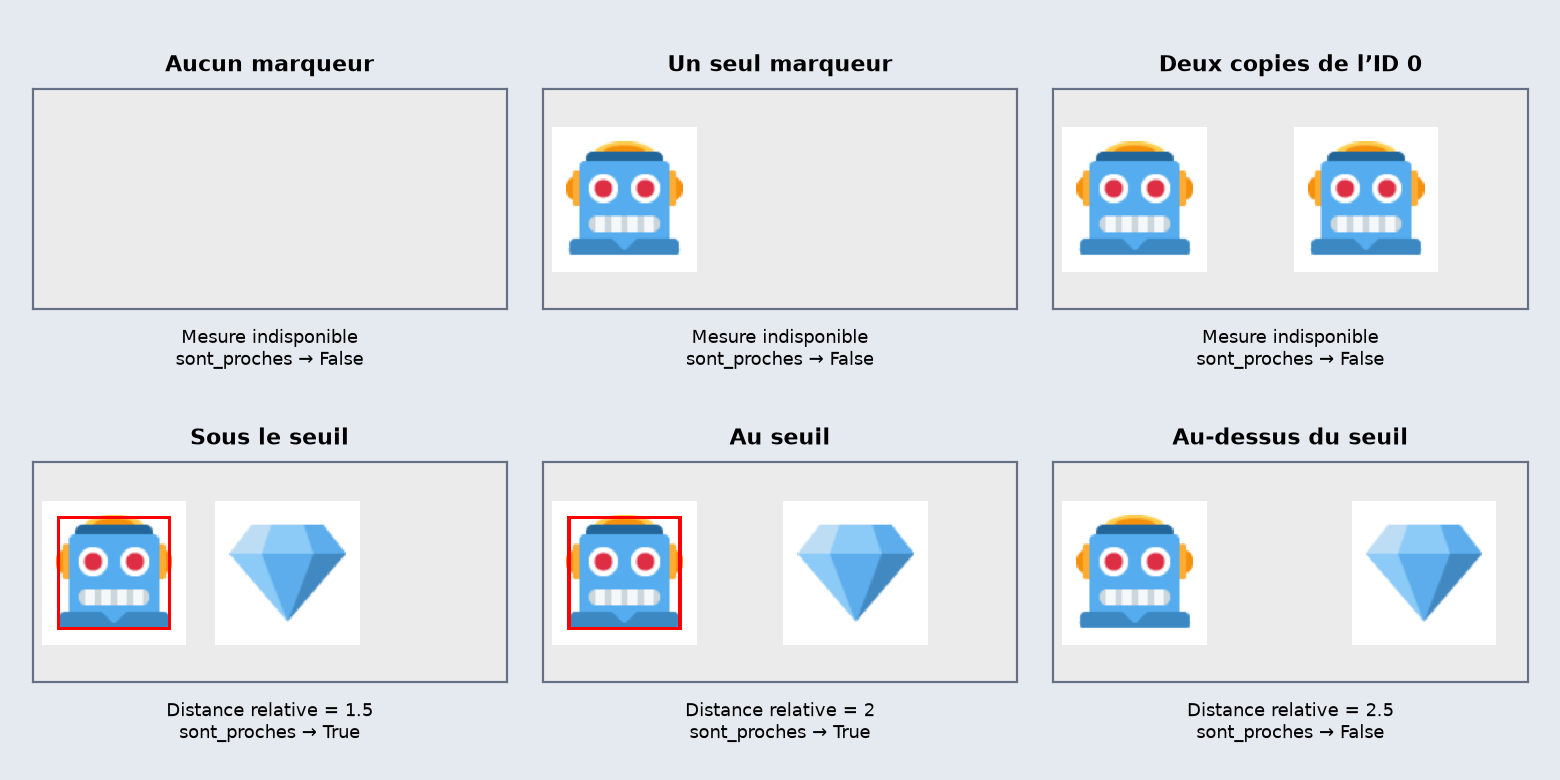


In [45]:
def sont_proches(detections, seuil=2.0):
    mesure = mesurer_proximite(detections)
    # À COMPLÉTER : traiter le cas None, puis comparer la distance relative au seuil.
    return False


In [46]:
resultats_proximite = {}
# À COMPLÉTER : construire les cas demandés et conserver les booléens calculés.
mesures_distance = []
# À COMPLÉTER : charger les deux photos et collecter distance_px et distance_relative.
print(resultats_proximite)
print(mesures_distance)


{}
[]


## Vérifier le travail avant la remise

Exécutez vos cellules complétées et conservez leurs sorties dans le notebook.
Vérifiez que les images produites, les résultats numériques des essais photo
et les mesures du téléphone sont présents. Le traitement doit distinguer les
IDs 0 et 1, suivre la perspective et gérer une photo sans marqueur.


## Remettre votre travail

Enregistrez le notebook après avoir exécuté vos cellules complétées. Dans la
dernière cellule, remplacez `À COMPLÉTER` par votre identifiant étudiant, puis
exécutez-la. Téléchargez le fichier `reponses-<identifiant>.json` et remettez-le.

Ce fichier contient votre code et les sorties enregistrées de vos cellules,
notamment les images produites, les résultats numériques et les mesures saisies
pour le téléphone. Réexécutez les cellules modifiées avant d’enregistrer pour
que leurs sorties correspondent à votre travail. L’export ne vérifie pas si
le travail est correct ou terminé.

`telecharger_reponses` est une fonction fournie avec le labo dans
`export_reponses.py`. La cellule ci-dessous télécharge ce module depuis notre
site s’il n’est pas encore présent. Dans Colab, elle lit le notebook ouvert ;
dans Jupyter, elle lit le fichier enregistré indiqué par `chemin_notebook`.


In [47]:
from pathlib import Path
import importlib
import importlib.util
from urllib.request import urlopen

# Ce module est fourni par le laboratoire sur notre site.
if importlib.util.find_spec('export_reponses') is None:
    adresse = 'https://laboratoire-sciences-code.netlify.app/apps/realite-augmentee/ressources/export_reponses.py'
    with urlopen(adresse, timeout=30) as reponse:
        Path('export_reponses.py').write_bytes(reponse.read())
    importlib.invalidate_caches()
from export_reponses import telecharger_reponses, CELLULES_PAR_QUESTION

# Correspondance des dix questions de cette version du TP.
# Fonctionne aussi si une ancienne copie du module est déjà chargée.
CELLULES_PAR_QUESTION.clear()
CELLULES_PAR_QUESTION.update({'question_01': ('student-pixels',), 'question_02': ('answers-aruco',), 'question_03': ('student-annotation',), 'question_04': ('student-surface',), 'question_05': ('student-homography',), 'question_06': ('student-blend',), 'question_07': ('student-integration', 'connect'), 'question_08': ('answers-synthesis',), 'question_09': ('answers-mobile',), 'question_10': ('student-proximity', 'answers-proximity', 'student-integration')})


# Dans Colab, lire le notebook ouvert. Dans Jupyter, lire le fichier enregistré.
try:
    from google.colab import _message
except ImportError:
    chemin_notebook = 'AR_Phone_Camera_Lab.ipynb'  # Adapter si le fichier est renommé.
else:
    chemin_notebook = None

identifiant_etudiant = 'À COMPLÉTER'
telecharger_reponses(identifiant_etudiant, chemin=chemin_notebook);


ValueError: Renseignez votre identifiant étudiant dans la cellule de remise.